# Expiring Options to Build: Replication Notebook

Replication package for Wan Hee Park, Sang-Gun Lee and Hojun Kang, *Expiring Options to Build: Permit Lifetimes and Development Finance in Korea* (working paper, 2026). Version v1.

The package has two files: this notebook, which contains all the code, and `replication_data.csv.gz`, which contains all the data. The notebook reproduces every table and figure of the paper and of its Online Appendix. It is stored with its outputs, so the results can be read without running it. Run it from the folder that holds both files; tables are written to `output/tables/` as LaTeX `tabular` blocks and figures to `output/figures/` as PDF and PNG, numbered as in the paper (Table S1, Figure S1, ... are in the Online Appendix).

| Section | Paper exhibits |
|---|---|
| 1. Setup | |
| 2. Analysis sample | |
| 3. Conceptual figures and the model | Figures 1–3 |
| 4. Descriptive statistics | Table 1, Table S2 |
| 5. Statutory deadlines and the two reforms | Figures 4–5, Tables 2–4, Tables S1, S3–S5 |
| 6. The 2022 contraction of development finance | Tables 5–6, Figures 6–7, Figure S1, Tables S6–S10 |
| 7. Boom and regional conditions | Tables S14–S15 |
| 8. Price indices | Appendix C (Table C.1, Figure C.1), price columns of Table 7 |
| 9. Property uses | Tables 7–8, Figure S2, Tables S16–S18 |
| 10. Outcomes of the permits | Tables 9–10, Figures 8–9, Tables S19–S21 |
| 11. Large versus small warehouses | Tables S11–S13 |

### Data

`replication_data.csv.gz` is one compressed CSV in long format. The column `table` names the data set of each row, the other columns are the union of the columns of all data sets, and the table `_columns` lists the columns of each data set. The function `table()` in Section 1 returns one data set.

| `table` | Contents | Source |
|---|---|---|
| `register` | 780,366 new-construction permits and declarations from 2010 with a building of a studied use: permit, start, use-approval and postponement dates (YYYYMMDD), province, district and legal-dong codes, parcel rank (`parcel_id`, preserves the order of parcels), zoning (English), site and floor area, use, sub-use, and `corp_name` (1 if the building name carries a corporate designation). Building names, lot numbers and register keys are removed. | Ministry of Land, Infrastructure and Transport, Building Permit Register, July 2026 release (https://www.hub.go.kr) |
| `zoning_crosswalk` | Korean and English names of the zoning designations | |
| `hedonic_warehouse`, `hedonic_office`, `hedonic_retail` | Estimation samples of the price indices (Appendix C): log price per m², contract year and quarter, hedonic characteristics, zoning group, district code | MOLIT Real Transaction Price Disclosure System (https://rt.molit.go.kr) |
| `reb_price` | Apartment and officetel sales price indices, monthly | Korea Real Estate Board, R-ONE |
| `rates`, `cp_cd` | Base rate, Treasury and corporate bond yields; 91-day CP and CD yields | Bank of Korea, ECOS (tables 722Y001, 721Y001) |
| `regional_*` | Province-level loans (ECOS 141Y010, 141Y004, 132Y001), unsold housing units (MOLIT, KOSIS) and office vacancy (Korea Real Estate Board), with Korean labels as published | as named |
| `geo_sigungu`, `geo_sido` | Simplified district and province boundaries, WKT in EPSG:4326 | National Geographic Information Institute, V-World |
| `honestdid_reference` | Rambachan–Roth bounds as reported in the paper (used only if `honestdid` is unavailable) | |

The register records Gwangju and Jeonnam under the merged code 12.

### Running

Python 3.11 with numpy 2.4.6, pandas 2.3.3, pyarrow 25.0.1, scipy 1.17.1, statsmodels 0.14.6, pyfixest 0.60.0, formulaic 1.2.2, wildboottest 0.3.2, matplotlib 3.11.1, geopandas 1.1.4, shapely 2.1.2, pyogrio 0.13.0 and ipykernel. A full run takes about 15 minutes on a laptop, most of it in the wild cluster bootstraps (Webb weights, 1,999 draws), the 330 relabellings of the permutation tests and the model simulation. All random draws are seeded.

The Rambachan–Roth bounds (Table S10, Panel B) need `honestdid` 0.1.1, which fails with numpy 2. Install it in a separate environment (numpy 1.26.4, scipy 1.13.1, pandas 2.2.3, cvxpy 1.5.3, torch, honestdid 0.1.1) and set the environment variable `HONESTDID_PYTHON` to that interpreter. Without it the notebook reads the bounds reported in the paper from the data file and says so.

### Licence

Code: MIT licence. Data extracts prepared by the authors: CC BY 4.0, subject also to the terms of the original publishers. Copyright (c) 2026 Wan Hee Park, Sang-Gun Lee and Hojun Kang.

## 1. Setup

In [1]:
import itertools, json, os, subprocess, sys, tempfile, textwrap, warnings
from pathlib import Path
import numpy as np, pandas as pd, pyfixest as pf, statsmodels.api as sm
import scipy.stats as sst
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
from IPython.display import display
import logging; logging.getLogger("fontTools").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 200); pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd(); OUT = ROOT / "output"
TAB, FIG, INT = OUT / "tables", OUT / "figures", OUT / "intermediate"
for d in (TAB, FIG, INT): d.mkdir(parents=True, exist_ok=True)

# All data are in one file. Its first column names the table; `table()` returns one table parsed as its original file was.
import io
_RAW = pd.read_csv(ROOT / "replication_data.csv.gz", dtype=str, keep_default_na=False)
_COLS = _RAW[_RAW.table == "_columns"].set_index("name")["columns"].str.split("|").to_dict()
def table(name, **read_opts):
    t = _RAW.loc[_RAW.table == name, _COLS[name]]
    return pd.read_csv(io.StringIO(t.to_csv(index=False)), **read_opts)
def geo_table(name):
    import geopandas as gpd
    t = table(name, dtype=str); return gpd.GeoDataFrame(t.drop(columns="wkt"), geometry=gpd.GeoSeries.from_wkt(t.wkt), crs=4326)

END = pd.Timestamp("2026-04-30"); ENDM = END.to_period("M")          # last month of the register extract used
REFORM = pd.Timestamp("2017-07-18")                                     # permits: 1+1 years -> 2+1 years (Act 14535)
DREFORM = pd.Timestamp("2016-07-20")                                    # declarations: 1 year -> 1+1 years (Act 13785)
MO = 30.4375                                                            # days per month
print("pyfixest", pf.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

pyfixest 0.60.0 | pandas 2.3.3 | numpy 2.4.6


In [2]:
# Figure style
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"; INK, MUTED, GRID = "#0b0b0b", "#6b6a66", "#e4e3df"
STYLE = {"font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"], "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8.5,
         "axes.titleweight": "bold", "axes.titlelocation": "left", "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "axes.edgecolor": MUTED, "axes.linewidth": .6,
         "axes.spines.top": False, "axes.spines.right": False, "xtick.color": MUTED, "ytick.color": MUTED, "xtick.major.width": .5, "ytick.major.width": .5,
         "xtick.major.size": 2.5, "ytick.major.size": 2.5, "axes.labelcolor": INK, "text.color": INK, "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID,
         "grid.linewidth": .5, "legend.frameon": False, "legend.fontsize": 7.5, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.bbox": "tight", "savefig.pad_inches": .03,
         "figure.dpi": 110}
mpl.rcParams.update(STYLE)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.pdf"); fig.savefig(FIG / f"{name}.png", dpi=300); plt.show(); plt.close(fig)


# Table helpers. A table is a list of rows: (label, [cells]), "mid" (\midrule), "gap" (\addlinespace) or a raw LaTeX line.
def stars(p_): return "^{***}" if p_ < .01 else "^{**}" if p_ < .05 else "^{*}" if p_ < .1 else ""
def n_(x): return f"{int(round(x)):,}"
def ll_(v): return "$" + f"{v:,.0f}".replace(",", "{,}") + "$"          # log-likelihood in math mode
def yn(flags): return ["Yes" if f else "No" for f in flags]
def pval(est, se): return 2 * (1 - sst.norm.cdf(abs(est / se))) if se and se > 0 else np.nan


def cell(est, se, p_, d=3):
    if est is None or not np.isfinite(est): return "", ""
    return f"${est:.{d}f}{stars(p_)}$", f"$({se:.{d}f})$"


def coef_rows(ms, terms, d=2):
    """Coefficient and standard-error rows for models ms; terms = [(term, label) | None for a gap]. Rows empty in every column are left out."""
    rows = []
    for t in terms:
        if t is None: rows.append("gap"); continue
        term, lab = t
        if not any(term in m._coefnames for m in ms): continue
        cs = [cell(m.tidy().loc[term, "Estimate"], m.tidy().loc[term, "Std. Error"], m.tidy().loc[term, "Pr(>|t|)"], d) if term in m._coefnames else ("", "") for m in ms]
        rows += [(lab, [c[0] for c in cs]), ("", [c[1] for c in cs])]
    return rows


def ci(m, term): t = m.tidy().loc[term]; return f"$[{t['2.5%']:.1f},\\ {t['97.5%']:.1f}]$"


def write_table(name, colspec, head, rows):
    L = [r"\begin{tabular}{" + colspec + "}", r"\toprule"] + head + ([r"\midrule"] if head else [])
    for r in rows:
        if r == "mid": L.append(r"\midrule")
        elif r == "gap": L.append(r"\addlinespace")
        elif isinstance(r, str): L.append(r)
        else: L.append(r[0] + " & " + " & ".join(r[1]) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}"]
    (TAB / f"{name}.tex").write_text("\n".join(L) + "\n", encoding="utf-8")
    show_table(name)


def _plain(s):
    import re
    s = re.sub(r"\\multicolumn\{\d+\}\{[^}]*\}\{(.*)\}", r"\1", s)
    for a, b in [(r"\emph", ""), (r"\quad", "  "), (r"\times", "×"), (r"\geq", "≥"), (r"\leq", "≤"), (r"\bar{M}", "M̄"), ("m$^2$", "m²"), (r"\%", "%"), (r"\ ", " "), ("--", "–"), ("\\", "")]:
        s = s.replace(a, b)
    s = re.sub(r"\^\{(\**)\}", r"\1", s)
    return s.replace("$", "").replace("{", "").replace("}", "").strip()


def show_table(name):
    """Display a written LaTeX tabular as a data frame (rules are dropped)."""
    L = (TAB / f"{name}.tex").read_text(encoding="utf-8").splitlines()
    rows = []
    for l in L[2:]:
        if l.startswith((r"\bottomrule", r"\end{tabular}")): break
        if l.startswith((r"\midrule", r"\addlinespace", r"\cmidrule")): continue
        cells = [_plain(c) for c in l.rstrip().removesuffix(r"\\").split("&")]
        rows.append(cells)
    k = max(len(r) for r in rows); df = pd.DataFrame([r + [""] * (k - len(r)) for r in rows])
    df.columns = [""] + [f"({i})" for i in range(1, k)]; display(df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

## 2. Analysis sample

`data/register_extract.parquet` holds one row per new-construction permit (or declaration) issued from January 2010 on the national building permit register (MOLIT, July 2026 extract), restricted to permits with at least one building of a studied use. Building names, lot numbers and register keys are removed. `parcel_id` is the rank of the parcel identifier and preserves its order; `corp_name` marks building names that carry a corporate designation.

`build_sample()` applies the sample rules of the paper and derives every variable used below.

In [3]:
GROUP = {"Warehouse": "Warehouse", "Factory": "Factory", "Office": "Office", "Lodging": "Lodging", "Retail": "Retail", "Apartment": "Apartments",
         "Neighbourhood commercial I": "Neighbourhood commercial", "Neighbourhood commercial II": "Neighbourhood commercial",
         "Education and research": "Education", "Medical": "Medical", "Welfare": "Welfare"}
FIN = ["Warehouse", "Knowledge-industry centre", "Officetel", "Lodging", "Apartments", "Office", "Retail"]     # development-finance uses
OWN = ["Factory", "Education", "Medical", "Welfare"]                                                          # owner-user uses
MGMT = {"Planned management area", "Production management area", "Conservation management area", "Management area (unclassified)",
        "Agricultural and forest area", "Natural environment conservation area"}
IND = {"General industrial", "Semi-industrial", "Exclusive industrial"}


def months_between(a, b):
    return (a.dt.year - b.dt.year) * 12 + (a.dt.month - b.dt.month)


def build_sample():
    ledger = []
    p = table("register", dtype=str, keep_default_na=False)
    for c in ("site_area", "floor_area_total", "floor_area_use"): p[c] = pd.to_numeric(p[c].replace("", np.nan))
    p["corp_name"] = p.corp_name.astype(int); p["zoning"] = p.zoning.where(p.zoning != "", None); ledger.append(("New-construction permits from 2010 with a studied use", len(p)))
    for c, s in [("permit", "permit_date"), ("start", "start_date"), ("approval", "approval_date"), ("delay", "postponement_date")]:
        v = p[s].astype("string"); p[c] = pd.to_datetime(v.where(v.str.len() == 8), format="%Y%m%d", errors="coerce")
    bad = p.start.notna() & (p.start < p.permit); p.loc[bad, "start"] = pd.NaT; ledger.append(("  start date before permit date, start set to missing", int(bad.sum())))
    p = p[~(p.start.isna() & p.approval.notna())].copy(); ledger.append(("Drop completed permits without a start date", len(p)))
    p["area"] = p.floor_area_use.where(p.floor_area_use > 0, p.floor_area_total); p = p[p.area > 0].copy(); ledger.append(("Floor area > 0", len(p)))
    p["g"] = np.where(p.subuse != "", p.subuse, p.use.map(GROUP).fillna("Other")); p = p[p.g != "Other"].copy(); ledger.append(("Twelve use groups", len(p)))
    p["fin"] = np.where(p.g.isin(FIN), "finance", np.where(p.g.isin(OWN), "owner", "mixed"))
    p["large"] = (p.area >= 3300).astype(int); p["small"] = (p.area < 1000).astype(int); p["lnarea"] = np.log(p.area)
    p["year"] = p.permit.dt.year; p["h"] = p.year.astype(str) + "H" + np.where(p.permit.dt.month <= 6, "1", "2")
    p["pm"] = p.permit.dt.to_period("M"); p["pm_s"] = p.pm.astype(str); p["sm"] = p.start.dt.to_period("M")
    p["event"] = p.sm.notna() & (p.sm <= ENDM)
    p["T"] = np.where(p.event, months_between(p.start, p.permit), months_between(pd.Series(END, index=p.index), p.permit)).astype(float)   # months to start or censoring
    p = p[p["T"] >= 0].copy(); ledger.append(("Permits issued by April 2026", len(p)))
    p["M"] = np.where(p.permit >= REFORM, 24, 12)                                                     # statutory life of a permit, months
    p["district"] = p.sigungu_cd; p["cl"] = pd.factorize(p.district)[0].astype(np.int64)
    p["sma"] = p.sido_cd.isin(["11", "28", "41"]); p["sgg_h"] = p.district + "_" + p.h
    top = p.zoning.value_counts().index[:6]; p["zone"] = p.zoning.where(p.zoning.isin(top), "Other").fillna("Other")
    p["parcel"] = p.parcel_id; p = p.sort_values(["parcel", "permit"])
    prev = p.groupby("parcel").area.shift(1); p["repermit"] = prev.notna() & ((p.area - prev).abs() <= 0.01 * prev)
    p.loc[p.approval > pd.Timestamp("2026-07-31"), "approval"] = pd.NaT                               # four approval dates with typo years 2101-2218
    t_start = (p.start - p.permit).dt.days / MO; t_appr = (p.approval - p.permit).dt.days / MO
    for n in (6, 12, 18, 24, 48): p[f"y{n}"] = (t_start <= n).fillna(False).astype(float) * 100      # started within n months (x100)
    for n in (36, 60): p[f"c{n}"] = (t_appr <= n).fillna(False).astype(float) * 100                   # completed within n months of permit (x100)
    p["idle48"] = t_start.clip(upper=48).fillna(48)                                                   # months unstarted in the first 48
    p["ln_site"] = np.log(p.site_area.where(p.site_area > 0)); p["site_miss"] = p.ln_site.isna().astype(int); p["ln_site"] = p.ln_site.fillna(0.0)
    # declaration eligibility (Enforcement Decree of the Building Act, Art. 11(3)); PR = permits of 200 m2 or more that are not declaration-eligible
    emd = pd.to_numeric(p.bjdong_cd.str[:3], errors="coerce") >= 250                                 # township (eup, myeon)
    de = (p.area <= 100) | ((p.area < 200) & p.zoning.isin(MGMT)) | ((p.g == "Warehouse") & (p.area <= 200) & emd) | ((p.g == "Factory") & (p.area <= 500) & p.zoning.isin(IND))
    p["grp"] = np.where(de, "DE", np.where(p.area >= 200, "PR", "other"))
    p["grp2"] = np.where(p.grp == "PR", np.where(p.area < 1000, "PR1", np.where(p.area < 3300, "PR2", "PR3")), p.grp)
    ledger += [("  large (>= 3,300 m2)", int(p.large.sum())), ("  small (< 1,000 m2)", int(p.small.sum()))]
    return p, pd.DataFrame(ledger, columns=["step", "N"])


def ok(q, n): return q.permit <= END - pd.DateOffset(months=n)                   # outcome window of n months observed


def panel(q, maxd, cols=("cl", "pm", "T", "event", "M", "permit", "g", "fin", "large")):
    """Project-month panel: one row per month at risk, d = months since permit, y = 1 in the month of the start."""
    q = q[list(cols)].copy(); q["last"] = np.minimum(q["T"], maxd - 1).astype(int)
    r = q.loc[q.index.repeat(q["last"] + 1)].copy(); r["d"] = r.groupby(level=0).cumcount()
    r["cal"] = r.pm + r.d; r["y"] = (r.event & (r.d == r["T"])).astype(int); return r


def did_data(q, ycol="y12", n=12, start="2018-01-01", lo=1000, hi=3300):
    """Large (>= hi) versus small (< lo) permits, with treated x cohort-period indicators."""
    d = q[(q.permit >= start) & (q.permit <= END - pd.DateOffset(months=n)) & ((q.area < lo) | (q.area >= hi))].copy()
    d["L"] = (d.area >= hi).astype(int); d["y"] = d[ycol]
    d["pre"] = d.L * (d.h < "2021H1"); d["hike"] = d.L * d.h.isin(["2021H2", "2022H1"]); d["post"] = d.L * (d.h >= "2022H2")
    return d


p, ledger = build_sample()
display(ledger)
W = p[p.g == "Warehouse"]; Fa = p[p.g == "Factory"]
print(p.g.value_counts().to_string())

,step,N
0,New-construction permits from 2010 with a studied use,780366
1,"start date before permit date, start set to missing",49
2,Drop completed permits without a start date,776157
3,Floor area > 0,776152
4,Twelve use groups,765300
5,Permits issued by April 2026,759749
6,"large (>= 3,300 m2)",36486
7,"small (< 1,000 m2)",644990


g
Neighbourhood commercial     435664
Warehouse                    121210
Apartments                    97815
Factory                       61925
Office                        13755
Welfare                       10409
Lodging                        9820
Education                      4882
Retail                         1321
Officetel                      1303
Medical                        1276
Knowledge-industry centre       369


## 3. Conceptual figures and the model

**Figure 1.** Stages, financing, recorded dates and the statutory deadline (drawn without data).

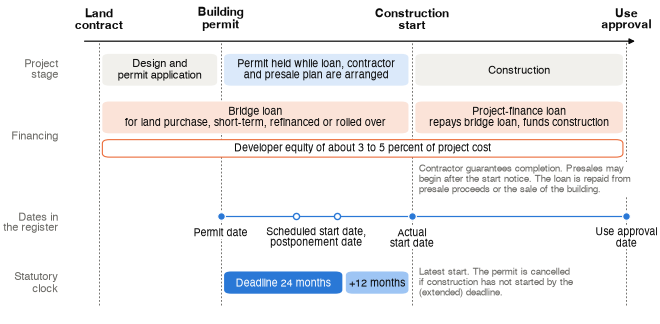

In [4]:
with mpl.rc_context({"font.size": 7.5, "axes.grid": False}):
    PALE, LBLUE, LORANGE = "#f1f0ec", "#dbe9fa", "#fbe3d8"
    fig, ax = plt.subplots(figsize=(6.8, 3.75)); ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
    X_ = {"land": 6, "permit": 27, "start": 60, "done": 97}
    def box(x0, x1, y, h, txt, fc, ec="none", col=INK, fs=7.2):
        ax.add_patch(FancyBboxPatch((x0, y), x1 - x0, h, boxstyle="round,pad=0,rounding_size=1.2", fc=fc, ec=ec, lw=.7))
        ax.text((x0 + x1) / 2, y + h / 2, txt, ha="center", va="center", fontsize=fs, color=col, linespacing=1.15)
    def rowlab(y, t): ax.text(-1, y, t, ha="right", va="center", fontsize=7.2, color=MUTED, linespacing=1.1)
    for k, t in [("land", "Land\ncontract"), ("permit", "Building\npermit"), ("start", "Construction\nstart"), ("done", "Use\napproval")]:
        ax.plot([X_[k]] * 2, [5, 88], color=MUTED, lw=.6, ls=(0, (2, 2)), zorder=0); ax.text(X_[k], 95, t, ha="center", va="center", fontsize=8, fontweight="bold", linespacing=1.1)
    ax.annotate("", xy=(99, 88), xytext=(3, 88), arrowprops=dict(arrowstyle="-|>", color=INK, lw=.8))
    rowlab(79, "Project\nstage")
    box(X_["land"] + .6, X_["permit"] - .6, 74, 10, "Design and\npermit application", PALE)
    box(X_["permit"] + .6, X_["start"] - .6, 74, 10, "Permit held while loan, contractor\nand presale plan are arranged", LBLUE, fs=6.9)
    box(X_["start"] + .6, X_["done"] - .6, 74, 10, "Construction", PALE)
    rowlab(58, "Financing")
    box(X_["land"] + .6, X_["start"] - .6, 59, 10, "Bridge loan\nfor land purchase, short-term, refinanced or rolled over", LORANGE, fs=6.9)
    box(X_["start"] + .6, X_["done"] - .6, 59, 10, "Project-finance loan\nrepays bridge loan, funds construction", LORANGE, fs=6.9)
    box(X_["land"] + .6, X_["done"] - .6, 51.5, 5.5, "Developer equity of about 3 to 5 percent of project cost", "white", ec=ORANGE, fs=6.8)
    ax.text(X_["start"] + 1.2, 44.5, "Contractor guarantees completion. Presales may\nbegin after the start notice. The loan is repaid from\npresale proceeds or the sale of the building.", fontsize=6.4, color=MUTED, va="center", linespacing=1.15, bbox=dict(fc="white", ec="none", pad=1))
    rowlab(31, "Dates in\nthe register")
    ax.plot([X_["permit"], X_["done"]], [33, 33], color=BLUE, lw=.8, zorder=1)
    for k, t in [("permit", "Permit date"), ("start", "Actual\nstart date"), ("done", "Use approval\ndate")]:
        ax.plot([X_[k]], [33], "o", ms=5, mfc=BLUE, mec="white", mew=.8, zorder=3); ax.text(X_[k], 29.5, t, ha="center", va="top", fontsize=6.8, linespacing=1.1, bbox=dict(fc="white", ec="none", pad=.8))
    ax.plot([40, 47], [33, 33], "o", ms=4, mfc="white", mec=BLUE, mew=.9, zorder=3); ax.text(43.5, 29.5, "Scheduled start date,\npostponement date", ha="center", va="top", fontsize=6.8, linespacing=1.1, bbox=dict(fc="white", ec="none", pad=.8))
    rowlab(12, "Statutory\nclock")
    box(X_["permit"] + .6, 48, 8.5, 7, "Deadline 24 months", BLUE, col="white", fs=6.9); box(48.6, X_["start"] - .6, 8.5, 7, "+12 months", "#9ec5f4", fs=6.9)
    ax.text(X_["start"] + 1.2, 12, "Latest start. The permit is cancelled\nif construction has not started by the\n(extended) deadline.", fontsize=6.4, color=MUTED, va="center", linespacing=1.15, bbox=dict(fc="white", ec="none", pad=1))
    savefig(fig, "fig01_schematic")

**Figure 2.** Interest rates and the quarterly flow of large development-finance projects.

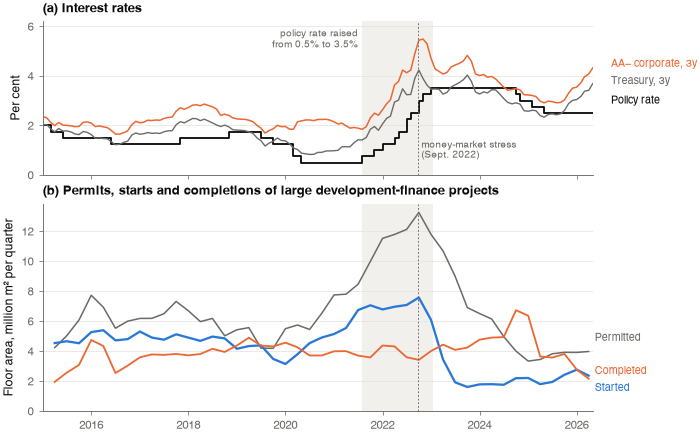

,permitted,started,completed
2021h1,16.9,13.5,7.4
2021h2,23.0,13.6,8.7
2022h1,24.2,14.1,7.2
2022h2,23.6,12.2,8.0
2023h1,18.0,3.8,8.2
2023h2,13.0,3.6,9.5
2024h1,9.9,3.5,9.9
2024h2,6.7,4.4,12.7
2025h1,7.6,3.9,7.1


In [5]:
rt = table("rates"); rt["t"] = pd.to_datetime(rt.date); rt = rt[rt.t >= "2015-01-01"]
Lf = p[(p.large == 1) & (p.fin == "finance")]
def flow(col, lo="2015-01-01"):
    x = Lf[Lf[col].notna() & (Lf[col] >= lo) & (Lf[col] <= pd.Timestamp("2026-03-31"))]; s = x.groupby(x[col].dt.to_period("Q")).area.sum() / 1e6
    s.index = s.index.to_timestamp(how="end"); return s
fig, axs = plt.subplots(2, 1, figsize=(6.8, 4.6), sharex=True, gridspec_kw={"height_ratios": [1, 1.35], "hspace": .16})
ax = axs[0]; ax.step(rt.t, rt.bok_base_rate, where="post", color=INK, lw=1.2); ax.plot(rt.t, rt.corp_aa3y, color=ORANGE, lw=1.0); ax.plot(rt.t, rt.ktb_3y, color=MUTED, lw=.9)
ax.set_ylabel("Per cent"); ax.set_title("(a) Interest rates"); ax.set_ylim(0, 6.2)
for y, s_, c_ in [(rt.corp_aa3y.iloc[-1], "AA− corporate, 3y", ORANGE), (rt.ktb_3y.iloc[-1], "Treasury, 3y", MUTED), (rt.bok_base_rate.iloc[-1], "Policy rate", INK)]:
    ax.annotate(s_, (rt.t.iloc[-1], y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=7, color=c_, annotation_clip=False)
ax = axs[1]
for col, lab, c_, lw in [("permit", "Permitted", MUTED, 1.0), ("start", "Started", BLUE, 1.5), ("approval", "Completed", ORANGE, 1.2)]:
    s = flow(col).rolling(2, min_periods=1).mean(); ax.plot(s.index, s.values, color=c_, lw=lw)
    ax.annotate(lab, (s.index[-1], s.values[-1]), xytext=(4, {"Permitted": 9, "Started": -8, "Completed": 5}[lab]), textcoords="offset points", va="center", fontsize=7, color=c_, annotation_clip=False)
ax.set_ylabel("Floor area, million m² per quarter"); ax.set_title("(b) Permits, starts and completions of large development-finance projects"); ax.set_ylim(0, None)
for a in axs:
    a.axvspan(pd.Timestamp("2021-08-01"), pd.Timestamp("2023-01-15"), color="#f1f0ec", zorder=0, lw=0); a.axvline(pd.Timestamp("2022-09-28"), color=MUTED, lw=.6, ls=(0, (2, 2)))
axs[0].text(pd.Timestamp("2021-07-01"), 5.9, "policy rate raised\nfrom 0.5% to 3.5%", ha="right", va="top", fontsize=6.5, color=MUTED, linespacing=1.1)
axs[0].text(pd.Timestamp("2022-10-20"), 1.0, "money-market stress\n(Sept. 2022)", ha="left", va="center", fontsize=6.5, color=MUTED, linespacing=1.1)
axs[1].set_xlim(pd.Timestamp("2015-01-01"), pd.Timestamp("2026-04-30")); fig.subplots_adjust(right=.86); savefig(fig, "fig02_timeline")
hy_ = lambda s: s.dt.year.astype(str) + np.where(s.dt.month <= 6, "h1", "h2")          # half-year floor area, million m2 (quoted in Section 5.4)
flows = pd.DataFrame({k: Lf[Lf[c].notna()].groupby(hy_(Lf.loc[Lf[c].notna(), c])).area.sum() / 1e6 for k, c in [("permitted", "permit"), ("started", "start"), ("completed", "approval")]})
flows.round(2).to_csv(INT / "flows_large_devfinance_halfyear.csv"); display(flows.loc["2021h1":"2025h1"].round(1))

**Figure 3.** Numerical solution of the model in Section 3. The value ratio $x = V/K$ follows a geometric Brownian motion under the risk-neutral measure (drift $r-\delta$, volatility $\sigma$). The permit lapses at $T$ unless the holder pays the relative cost $\tilde c$ for a one-year extension. The value function is solved by backward induction on a trinomial lattice in $\ln x$; the start hazard is simulated from a lognormal distribution of $x$ at the permit date.

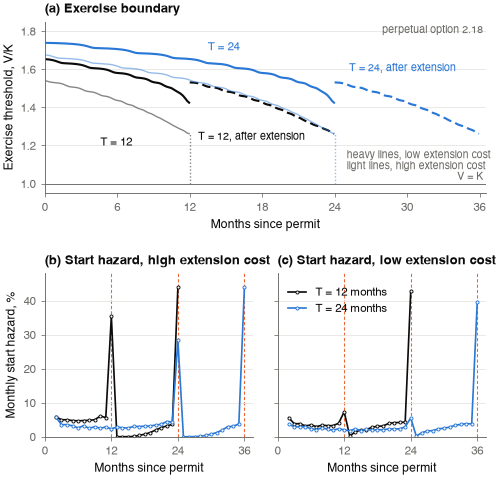

In [6]:
R_, DELTA, SIG = 0.05, 0.04, 0.20; NPM = 40; DT = 1 / (12 * NPM)
DX = SIG * np.sqrt(3 * DT); Gx = np.arange(-400, 401) * DX; Xg = np.exp(Gx)
nu = R_ - DELTA - .5 * SIG ** 2; pu = .5 * (SIG ** 2 * DT + nu ** 2 * DT ** 2) / DX ** 2 + .5 * nu * DT / DX; pdn = pu - nu * DT / DX; pmid = 1 - pu - pdn; DISC = np.exp(-R_ * DT)
PAY = np.maximum(Xg - 1, 0)

def solve(months, terminal):
    """Backward induction; returns the exercise boundary at each step, the value at t = 0 and an interpolated boundary for plotting."""
    n = months * NPM; v = terminal.copy(); b = np.full(n + 1, np.nan); bs = np.full(n + 1, np.nan)
    ex = (terminal <= PAY + 1e-12) & (Xg > 1); b[n] = Xg[ex].min() if ex.any() else np.nan
    for k in range(n - 1, -1, -1):
        c = v.copy(); c[1:-1] = DISC * (pu * v[2:] + pmid * v[1:-1] + pdn * v[:-2]); c[0] = 0; c[-1] = PAY[-1]
        v = np.maximum(c, PAY); ex = (PAY >= c - 1e-12) & (Xg > 1); b[k] = Xg[ex].min()
        j = np.argmax(ex); g0, g1 = c[j - 1] - PAY[j - 1], c[j] - PAY[j]
        bs[k] = Xg[j - 1] + (Xg[j] - Xg[j - 1]) * g0 / (g0 - g1) if (j > 0 and g0 > 0 and g0 != g1) else Xg[j]
    return b, v, bs

def regime(T, ctil):
    """Life of T months plus a 12-month extension at relative cost ctil."""
    b_ext, v_ext, s_ext = solve(12, PAY)
    ext_val = v_ext - ctil if np.isfinite(ctil) else np.full_like(Xg, -np.inf)
    term = np.maximum(np.maximum(PAY, ext_val), 0); b_pre, _, s_pre = solve(T, term)
    extend = (ext_val > PAY) & (ext_val > 0)
    return dict(T=T, b_pre=b_pre, b_ext=b_ext, extend=extend, s_pre=s_pre, s_ext=s_ext)

def hazard(rg, n=400_000, seed=1, mu_x0=0.45, sd_x0=0.35):
    rng = np.random.default_rng(seed); T = rg["T"]; nT = T * NPM; nA = nT + 12 * NPM
    idx = np.clip(np.round(rng.normal(mu_x0, sd_x0, n) / DX).astype(int) + 400, 0, 800); alive = np.ones(n, bool); start = np.full(n, -1)
    bidx = lambda b: np.searchsorted(Xg, b - 1e-12)
    for k in range(nA + 1):
        if k <= nT: thr = bidx(rg["b_pre"][k]) if np.isfinite(rg["b_pre"][k]) else 10 ** 6
        else: thr = bidx(rg["b_ext"][k - nT])
        hit = alive & (idx >= thr)
        if k == nT:
            hit = alive & (PAY[idx] > 0) & ~rg["extend"][idx]; lapse = alive & ~hit & ~rg["extend"][idx]; alive &= ~lapse
        if k == nA: hit = alive & (Xg[idx] >= 1)
        start[hit] = k; alive &= ~hit
        if k == nA: break
        u = rng.random(n); idx = np.clip(idx + (u < pu).astype(int) - (u > 1 - pdn).astype(int), 0, 800)
    m = np.where(start >= 0, np.ceil(np.maximum(start, 1) / NPM).astype(int), 0); out = []; at_risk = n
    for d in range(1, (nA // NPM) + 1):
        s = int((m == d).sum()); out.append((d, s / at_risk if at_risk else np.nan, at_risk)); at_risk -= s
        if d == T: at_risk = int(((m > T)).sum() + (alive & (start < 0)).sum())
    return pd.DataFrame(out, columns=["d", "hazard", "at_risk"])

CS_, CL_ = 0.06, 0.004                                                       # relative extension cost: high / low
RG = {("small", 12): regime(12, CS_), ("small", 24): regime(24, CS_), ("large", 12): regime(12, CL_), ("large", 24): regime(24, CL_)}
Hm = pd.concat([hazard(rg).assign(size=sz, T=T) for (sz, T), rg in RG.items()]); Hm.to_csv(INT / "model_hazard.csv", index=False)
beta_ = .5 - (R_ - DELTA) / SIG ** 2 + np.sqrt(((R_ - DELTA) / SIG ** 2 - .5) ** 2 + 2 * R_ / SIG ** 2)
smooth = lambda y: pd.Series(y).rolling(NPM // 2, center=True, min_periods=1).mean().values
fig = plt.figure(figsize=(5.17, 4.9)); gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1], hspace=.48, wspace=.12)
ax = fig.add_subplot(gs[0, :]); axb = fig.add_subplot(gs[1, 0]); axc = fig.add_subplot(gs[1, 1], sharey=axb)
for T, col in [(12, INK), (24, BLUE)]:
    rg = RG[("large", T)]; t = np.arange(T * NPM + 1) / NPM; ax.plot(t[:-2], smooth(rg["s_pre"])[:-2], color=col, lw=1.4)
    te = T + np.arange(12 * NPM + 1) / NPM; ax.plot(te[:-2], smooth(rg["s_ext"])[:-2], color=col, lw=1.4, ls=(0, (4, 2)))
    rs = RG[("small", T)]; ax.plot(t[:-2], smooth(rs["s_pre"])[:-2], color=col, lw=.9, alpha=.5); ax.plot([T, T], [1, smooth(rs["s_pre"])[-3]], color=col, lw=.9, alpha=.5, ls=(0, (1, 1.5)))
ax.axhline(1, color=MUTED, lw=.6); ax.text(36.3, 1.02, "V = K", ha="right", fontsize=7, color=MUTED)
ax.set_xlim(0, 36.5); ax.set_ylim(.95, 1.85); ax.xaxis.set_major_locator(MultipleLocator(6)); ax.set_xlabel("Months since permit"); ax.set_ylabel("Exercise threshold, V/K"); ax.set_title("(a) Exercise boundary")
ax.text(4.6, 1.20, "T = 12", color=INK, fontsize=7.5); ax.text(13.5, 1.70, "T = 24", color=BLUE, fontsize=7.5)
ax.text(12.7, 1.23, "T = 12, after extension", color=INK, fontsize=7); ax.text(25.2, 1.59, "T = 24, after extension", color=BLUE, fontsize=7)
ax.text(25.0, 1.12, "heavy lines, low extension cost\nlight lines, high extension cost", color=MUTED, fontsize=6.8, linespacing=1.15, va="center")
ax.text(36.3, 1.79, f"perpetual option {beta_ / (beta_ - 1):.2f}", ha="right", fontsize=7, color=MUTED)
for a_, sz, ttl in [(axb, "small", "(b) Start hazard, high extension cost"), (axc, "large", "(c) Start hazard, low extension cost")]:
    for T, col in [(12, INK), (24, BLUE)]:
        z = Hm[(Hm["size"] == sz) & (Hm["T"] == T) & (Hm.d >= 2)]; a_.plot(z.d, 100 * z.hazard, color=col, lw=1.1, marker="o", ms=2, mfc="white", mew=.6, label=f"T = {T} months")
    for d_ in (12, 24, 36): a_.axvline(d_, color=ORANGE, lw=.7, ls=(0, (3, 2)), zorder=0)
    a_.set_xlim(0, 37.5); a_.xaxis.set_major_locator(MultipleLocator(12)); a_.set_xlabel("Months since permit"); a_.set_title(ttl); a_.set_ylim(0, 48)
axb.set_ylabel("Monthly start hazard, %"); plt.setp(axc.get_yticklabels(), visible=False); axc.legend(loc="upper left", bbox_to_anchor=(.0, .98), handlelength=1.6)
savefig(fig, "fig03_model")

## 4. Descriptive statistics

**Table 1.** Summary statistics.

In [7]:
d1 = p[p.permit >= "2018-01-01"].copy()
def srow(lab, s, dd=1):
    s = s.dropna(); f = lambda v: f"{v:,.{dd}f}"
    return (lab, [n_(len(s)), f(s.mean()), f(s.std()), f(s.quantile(.1)), f(s.median()), f(s.quantile(.9)), f(s.max())])
def block(x, de=True):
    st = x[x.event]; bm = (x.approval - x.start).dt.days / MO
    return [srow(r"Floor area (m$^2$)", x.area, 0), srow(r"Site area (m$^2$)", x.site_area.where(x.site_area > 0), 0),
            srow("Started within 12 months (0/1)", x.loc[ok(x, 12), "y12"] / 100, 3), srow("Started within 24 months (0/1)", x.loc[ok(x, 24), "y24"] / 100, 3),
            srow("Months from permit to start (started projects)", st["T"], 1), srow("Months from start to completion (completed projects)", bm[bm >= 0], 1),
            srow("Start-postponement filing (0/1)", x.delay.notna().astype(float), 3)] + \
           ([srow("Declaration-eligible (0/1)", (x.grp == "DE").astype(float), 3)] if de else []) + [srow("Seoul metropolitan area (0/1)", x.sma.astype(float), 3)]
write_table("table01_summary", "lrrrrrrr", [r" & $N$ & Mean & SD & p10 & Median & p90 & Max \\"],
            [r"\multicolumn{8}{l}{\emph{Panel A. All new-construction permits and declarations, permit dates 2018m1--2026m4}} \\", "gap"] + block(d1) +
            ["gap", r"\multicolumn{8}{l}{\emph{Panel B. Large projects (floor area $\geq$3,300 m$^2$)}} \\", "gap"] + block(d1[d1.large == 1], de=False))

,(1),(2),(3),(4),(5),(6),(7)
,N,Mean,SD,p10,Median,p90,Max
"Panel A. All new-construction permits and declarations, permit dates 2018m1–2026m4",,,,,,,
Floor area (m²),"329,150","1,398","10,607",54,232,"1,655","2,247,561"
Site area (m²),"329,150","1,893","18,322",228,687,"3,304","6,169,460"
Started within 12 months (0/1),"306,822",0.763,0.425,0.000,1.000,1.000,1.000
Started within 24 months (0/1),"281,264",0.827,0.379,0.000,1.000,1.000,1.000
Months from permit to start (started projects),"275,337",4.4,7.5,0.0,1.0,12.0,97.0
Months from start to completion (completed projects),"229,037",8.3,8.2,2.4,6.0,16.5,100.7
Start-postponement filing (0/1),"329,150",0.111,0.314,0.000,0.000,1.000,1.000
Declaration-eligible (0/1),"329,150",0.406,0.491,0.000,0.000,1.000,1.000


**Table S2.** Permits by property use.

In [8]:
rows = []
for grp, lab in [("finance", "Dev.-finance"), ("owner", "Owner-user"), ("mixed", "Mixed")]:
    for g_ in [u for u in FIN + OWN + ["Neighbourhood commercial"] if p[p.g == u].fin.iloc[0] == grp]:
        x = d1[d1.g == g_]; xl = x[x.large == 1]; xo, xlo = x[ok(x, 12)], xl[ok(xl, 12)]
        rows.append((f"{g_} & {lab}", [n_(len(x)), f"{x.area.median():,.0f}", f"{xo.y12.mean() / 100:.3f}", n_(len(xl)), f"{xl.area.median():,.0f}", f"{xlo.y12.mean() / 100:.3f}"]))
    rows.append("gap")
rows[-1] = "mid"; xl = d1[d1.large == 1]
rows.append(("All uses & ", [n_(len(d1)), f"{d1.area.median():,.0f}", f"{d1[ok(d1, 12)].y12.mean() / 100:.3f}", n_(len(xl)), f"{xl.area.median():,.0f}", f"{xl[ok(xl, 12)].y12.mean() / 100:.3f}"]))
write_table("tableS02_uses", "llrrrrrr", [r" & & \multicolumn{3}{c}{All permits} & \multicolumn{3}{c}{Large ($\geq$ 3,300 m$^2$)} \\", r"\cmidrule(lr){3-5}\cmidrule(lr){6-8}",
                                         r"Property use & Group & $N$ & Median area & Start $\leq$12m & $N$ & Median area & Start $\leq$12m \\"], rows)

,(1),(2),(3),(4),(5),(6),(7)
,,All permits,"Large (≥ 3,300 m²)",,,,
Property use,Group,N,Median area,Start ≤12m,N,Median area,Start ≤12m
Warehouse,Dev.-finance,"50,536",122,0.844,"1,399","28,959",0.567
Knowledge-industry centre,Dev.-finance,270,"30,337",0.589,249,"34,162",0.565
Officetel,Dev.-finance,709,"5,836",0.514,450,"11,466",0.444
Lodging,Dev.-finance,"3,466",971,0.568,698,"9,623",0.485
Apartments,Dev.-finance,"25,558",659,0.785,"2,106","8,620",0.509
Office,Dev.-finance,"6,695","3,292",0.707,"3,343","8,506",0.654
Retail,Dev.-finance,590,"2,905",0.821,257,"5,816",0.696
Factory,Owner-user,"24,216","1,261",0.807,"4,423","5,836",0.844


## 5. Statutory deadlines and the two reforms

Declarations had a one-year life with no extension until 19 July 2016 and a one-year life with a one-year extension from 20 July 2016. Permits had a one-year life with a one-year extension until 17 July 2017 and a two-year life with a one-year extension for applications from 18 July 2017. Periods: A = 2014h1 to 2016h1 (declarations: 1 January 2014 to 19 July 2015), B = 20 July 2016 to 2017h1, C = 18 January 2018 to 2019h2. The declaration amendment has no transitional clause, so it applied to every declaration still valid on 20 July 2016, that is, to declarations made from 20 July 2015; declarations made between 20 July 2015 and 19 July 2016 are a transition window and are left out of the declaration periods. The permit amendment applied to applications filed from 18 July 2017, and permits issued between July 2017 and mid-January 2018 are left out. Groups: DE = declaration-eligible; PR1, PR2, PR3 = permits of 200–1,000, 1,000–3,300 and at least 3,300 m². Apartments are excluded.

**Figure 4.** Raw monthly start hazards before and after the reforms.

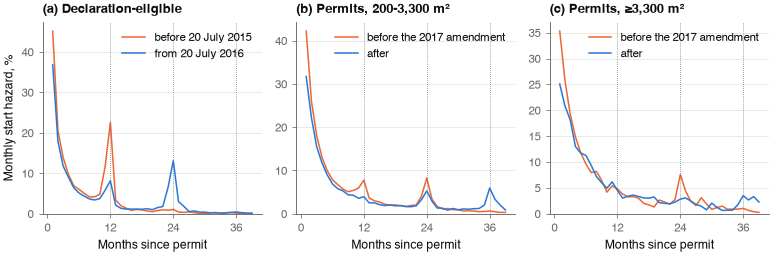

d                                                     9     12    24   36
panel                     period                                         
(a) Declaration-eligible  before 20 July 2015        4.2  22.6   1.1  0.1
                          from 20 July 2016          3.4   8.1  13.1  0.4
(b) Permits, 200-3,300 m² after                      4.4   3.9   5.3  5.9
                          before the 2017 amendment  5.1   7.8   8.3  0.6
(c) Permits, ≥3,300 m²    after                      6.0   4.5   2.8  3.5
                          before the 2017 amendment  6.4   4.8   7.6  1.0

In [9]:
GROUPS = ["DE", "PR1", "PR2", "PR3"]
GLAB = {"DE": "Declaration-eligible", "PR1": "Permits, 200-1,000 m²", "PR2": "Permits, 1,000-3,300 m²", "PR3": "Permits, ≥3,300 m²"}
q = p[(p.permit >= "2013-01-01") & (p.permit < "2020-01-01") & p.grp2.isin(GROUPS) & (p.g != "Apartments")].copy()
RCOLS = ("cl", "pm", "T", "event", "M", "permit", "g", "grp2", "approval", "start")

fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.5), sharey=False); HZ = []
PANELS = [("(a) Declaration-eligible", q[q.grp2 == "DE"], (q.permit < "2015-07-20"), (q.permit >= "2016-07-20"), "before 20 July 2015", "from 20 July 2016"),
          ("(b) Permits, 200-3,300 m²", q[q.grp2.isin(["PR1", "PR2"])], (q.permit < "2017-01-18"), (q.permit >= "2018-01-18"), "before the 2017 amendment", "after"),
          ("(c) Permits, ≥3,300 m²", q[q.grp2 == "PR3"], (q.permit < "2017-01-18"), (q.permit >= "2018-01-18"), "before the 2017 amendment", "after")]
for ax, (ttl, s, fb, fa, lb, la) in zip(axs, PANELS):
    for f_, col, lab in [(fb, ORANGE, lb), (fa, BLUE, la)]:
        z = s[f_.reindex(s.index).fillna(False)]
        r = panel(z, 40, cols=("cl", "pm", "T", "event", "M", "permit", "g")); r = r[r.cal < "2022-07"]
        h = (r.groupby("d").y.mean() * 100).loc[1:39]; ax.plot(h.index, h.values, color=col, lw=1, label=lab); HZ += [dict(panel=ttl, period=lab, d=int(k), hazard=v) for k, v in h.items()]
    for v in (12, 24, 36): ax.axvline(v, color=MUTED, lw=.5, ls=":")
    ax.set_title(ttl); ax.set_xlabel("Months since permit"); ax.set_xticks([0, 12, 24, 36]); ax.set_ylim(bottom=0); ax.legend(loc="upper right")
axs[0].set_ylabel("Monthly start hazard, %"); fig.tight_layout(); savefig(fig, "fig04_hazard_groups")
hz = pd.DataFrame(HZ); hz.to_csv(INT / "hazard_groups.csv", index=False)
display(hz[hz.d.isin([9, 12, 24, 36])].pivot_table(index=["panel", "period"], columns="d", values="hazard").round(1))

**Table 2.** Bunching of starts at months 10–12, 22–24 and 34–36 (relative to the preceding three months), by period and group. Poisson PML on the project-month panel with period × 6-month duration bin, calendar month and use effects, calendar months before July 2022, clustered by district.

In [10]:
def period(s, de=False):
    a_end = "2015-07-20" if de else "2016-07-01"                                  # declarations valid on 20 July 2016 could be extended
    return np.select([(s >= "2014-01-01") & (s < a_end), (s >= "2016-07-20") & (s < "2017-07-01"), (s >= "2018-01-18") & (s < "2020-01-01")], ["A", "B", "C"], "x")
def halfyear(s): return s.dt.year.astype(str) + np.where(s.dt.month <= 6, "h1", "h2")

def fit_bunching(r, cohcol, cohorts, ycol="y"):
    r = r.copy(); r["yy"] = r[ycol]; r["cb"] = r[cohcol] + "_" + ((r.d - 1) // 6).astype(str); r["cal_s"] = r.cal.astype(str); terms = []
    for a, b in [(10, 12), (22, 24), (34, 36)]:
        w = r.d.between(a, b)
        for c in cohorts:
            k = f"w{b}_{c}"; r[k] = (w & (r[cohcol] == c)).astype(int)
            if r.loc[r[k] == 1, "yy"].sum() >= 8: terms.append(k)
            else: r.drop(columns=k, inplace=True)
    m = pf.fepois("yy ~ " + "+".join(terms) + " | cb + cal_s + g", r, vcov={"CRV1": "cl"}); return m, terms

def contrast(m, a, b):
    nm = list(m._coefnames)
    if a not in nm or b not in nm: return None, None, None
    V = np.asarray(m._vcov); i, j = nm.index(a), nm.index(b); t = m.tidy()
    d = t.loc[a, "Estimate"] - t.loc[b, "Estimate"]; se = float(np.sqrt(V[i, i] + V[j, j] - 2 * V[i, j])); return d, se, pval(d, se)

PAN, HY, ST = {}, [], {}
for gname in GROUPS:
    s = q[q.grp2 == gname]
    r = panel(s, 40, cols=RCOLS); r = r[r.d.between(4, 39) & (r.cal < "2022-07")].copy()
    r["hy"] = halfyear(r.permit); r["per"] = period(r.permit, de=gname == "DE")
    r["real"] = (r.approval.notna() & ((r.approval - r.start).dt.days <= 36 * MO)).astype(int); r["yr"] = r.y * r.real     # starts completed within 36 months
    m, terms = fit_bunching(r, "hy", sorted(r.hy.unique())); t = m.tidy()
    for k in terms: w_, c = k.split("_", 1); HY.append(dict(group=gname, window=w_, cohort=c, est=t.loc[k, "Estimate"], se=t.loc[k, "Std. Error"]))
    r2 = r[r.per != "x"]; PAN[gname] = fit_bunching(r2, "per", ["A", "B", "C"])
    ST[gname] = dict(obs=PAN[gname][0]._N, cl=r2.cl.nunique(), starts=int(r2.y.sum()), **{f"proj{k}": int((period(s.permit, de=gname == "DE") == k).sum()) for k in "ABC"})
    PAN[gname + "_real"] = fit_bunching(r2, "per", ["A", "B", "C"], ycol="yr"); ST[gname]["starts_real"] = int(r2.yr.sum())
rows = []
for w_, lab in [("w12", "Months 10--12 relative to months 7--9"), ("w24", "Months 22--24 relative to months 19--21"), ("w36", "Months 34--36 relative to months 31--33")]:
    rows += [r"\multicolumn{5}{l}{\emph{" + lab + r"}} \\"]
    for per, plab in [("A", r"\quad Period A, 2014h1--2016h1"), ("B", r"\quad Period B, 2016h2--2017h1"), ("C", r"\quad Period C, 2018h1--2019h2")]:
        cs = []
        for gname in GROUPS:
            m, terms = PAN[gname]; k = f"{w_}_{per}"; t = m.tidy()
            cs.append(cell(t.loc[k, "Estimate"], t.loc[k, "Std. Error"], t.loc[k, "Pr(>|t|)"]) if k in terms else ("", ""))
        rows += [(plab, [c[0] for c in cs]), ("", [c[1] for c in cs])]
    for (a, b), clab in [(("B", "A"), r"\quad Declaration reform, B$-$A"), (("C", "B"), r"\quad Permit reform, C$-$B")]:
        cs = [cell(*c) if (c := contrast(PAN[g][0], f"{w_}_{a}", f"{w_}_{b}"))[0] is not None else ("", "") for g in GROUPS]
        rows += [(clab, [c[0] for c in cs]), ("", [c[1] for c in cs])]
    rows.append("gap")
rows += ["mid", ("Project-months", [n_(ST[g]["obs"]) for g in GROUPS]), *[(f"Projects, period {k}", [n_(ST[g][f"proj{k}"]) for g in GROUPS]) for k in "ABC"],
         ("Construction starts", [n_(ST[g]["starts"]) for g in GROUPS]), ("Clusters (districts)", [n_(ST[g]["cl"]) for g in GROUPS]),
         (r"Pseudo $R^2$", [f"{PAN[g][0]._pseudo_r2:.3f}" for g in GROUPS]), ("Log pseudo-likelihood", [ll_(PAN[g][0]._loglik) for g in GROUPS]),
         "mid", r"\multicolumn{5}{l}{\emph{Fixed effects}} \\", (r"\quad Period $\times$ six-month duration bin", ["Yes"] * 4), (r"\quad Calendar month", ["Yes"] * 4), (r"\quad Property use", ["Yes"] * 4)]
write_table("table02_reforms", "lcccc", [r" & \multicolumn{1}{c}{Declaration-} & \multicolumn{3}{c}{Permits} \\", r"\cmidrule(lr){3-5}",
            r" & eligible & 200--1,000 m$^2$ & 1,000--3,300 m$^2$ & $\geq$3,300 m$^2$ \\", r" & (1) & (2) & (3) & (4) \\"], rows)
hyd = pd.DataFrame(HY); hyd.to_csv(INT / "reforms_halfyear.csv", index=False)

,(1),(2),(3),(4)
,Declaration-,Permits,,
,eligible,"200–1,000 m²","1,000–3,300 m²","≥3,300 m²"
,(1),(2),(3),(4)
Months 10–12 relative to months 7–9,,,,
"Period A, 2014h1–2016h1",1.009***,0.141**,-0.045,-0.379***
,(0.096),(0.059),(0.079),(0.113)
"Period B, 2016h2–2017h1",0.596***,0.043,-0.009,-0.491***
,(0.074),(0.106),(0.130),(0.148)
"Period C, 2018h1–2019h2",0.333***,-0.245***,-0.438***,-0.400***
,(0.069),(0.051),(0.082),(0.109)


**Figure 5.** The same bunching coefficients estimated separately for each half-year permit cohort (95% intervals). Green line: first declaration cohort covered by the declaration reform (declarations made from 20 July 2015); orange line: permit reform.

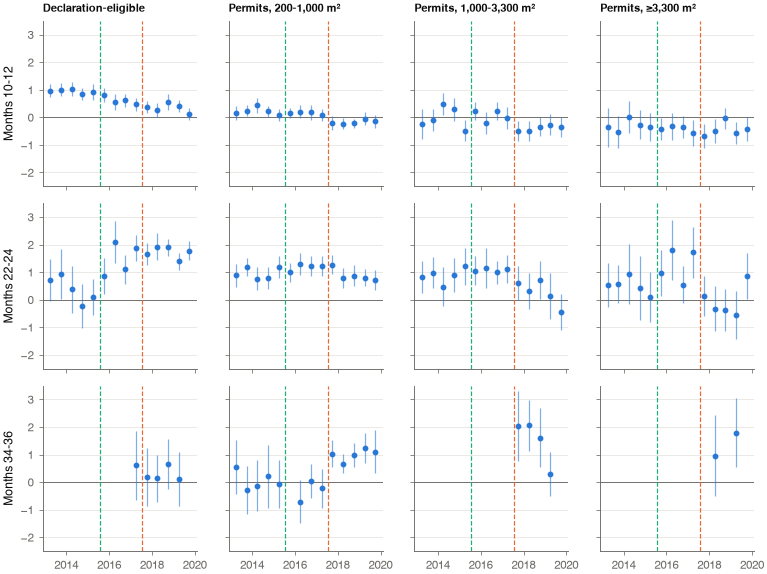

In [11]:
fig, axs = plt.subplots(3, 4, figsize=(7.2, 5.4), sharex=True, sharey=True)
for j, gname in enumerate(GROUPS):
    for i, w_ in enumerate(["w12", "w24", "w36"]):
        z = hyd[(hyd.group == gname) & (hyd.window == w_)].copy(); ax = axs[i, j]
        z["x"] = z.cohort.str[:4].astype(int) + np.where(z.cohort.str.endswith("h1"), .25, .75)
        ax.axhline(0, color=MUTED, lw=.6); ax.axvline(2015.55, color=GREEN, lw=.8, ls="--"); ax.axvline(2017.55, color=ORANGE, lw=.8, ls="--")
        ax.vlines(z.x, z.est - 1.96 * z.se, z.est + 1.96 * z.se, color=BLUE, lw=.8, alpha=.6); ax.plot(z.x, z.est, "o", ms=2.8, color=BLUE)
        ax.set_ylim(-2.5, 3.5); ax.set_xlim(2012.9, 2020.1)
        if i == 0: ax.set_title(GLAB[gname], fontsize=7.5)
        if j == 0: ax.set_ylabel({"w12": "Months 10-12", "w24": "Months 22-24", "w36": "Months 34-36"}[w_])
fig.tight_layout(); savefig(fig, "fig05_reforms_halfyear")

**Table 3 and Table S3.** Completion of projects started in the last three months before the statutory deadline or in the extension period. The statutory deadline is 12 months for declarations and for permits before 18 July 2017 and 24 months for later permits; permits within six months of the permit reform are dropped.

In [12]:
def completion_table(n, name):
    s = p[p.start.notna() & (p.start <= END - pd.DateOffset(months=n)) & p.grp.isin(["DE", "PR"]) & (p.permit >= "2010-01-01")].copy()
    s = s[~((s.grp == "PR") & (s.permit >= REFORM - pd.DateOffset(months=6)) & (s.permit < REFORM + pd.DateOffset(months=6)))]
    s["S"] = np.where(s.grp == "DE", 12, np.where(s.permit < REFORM, 12, 24)); s["gap"] = s.S - s["T"]
    s["near"] = s.gap.between(0, 2).astype(int); s["ext"] = (s.gap < 0).astype(int)
    s["done"] = (s.approval.notna() & ((s.approval - s.start).dt.days <= n * MO)).astype(float) * 100; s["g_sy"] = s.g + "_" + s.start.dt.year.astype(str)
    s["pyz"] = s.year.astype(str) + "_" + s.zone.astype(str)
    SPEC = [(s, "g_sy"), (s, "g_sy + district"), (s, "g_sy + district + pyz"), (s[s.grp == "DE"], "g_sy + district"), (s[s.grp2.isin(["PR1", "PR2"])], "g_sy + district"),
            (s[s.grp2 == "PR3"], "g_sy + district"), (s[(s.grp2 == "PR3") & (s.fin == "finance")], "g_sy + district"), (s[(s.grp2 == "PR3") & (s.fin == "owner")], "g_sy + district")]
    ms = [pf.feols(f"done ~ near + ext + lnarea | {fe}", x, vcov={"CRV1": "cl"}) for x, fe in SPEC]
    rows = coef_rows(ms, [("near", "Started in last 3 months before statutory deadline"), ("ext", "Started after statutory deadline"), ("lnarea", "Log floor area")])
    rows += ["gap", ("Mean of dependent variable", [f"{x.done.mean():.2f}" for x, _ in SPEC]), (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Adjusted $R^2$", [f"{m._adj_r2:.3f}" for m in ms]),
             (r"Within $R^2$", [f"{m._r2_within:.3f}" for m in ms]),
             ("Observations", [n_(m._N) for m in ms]), ("Started near deadline / after deadline", [f"{x.near.sum():,} / {x.ext.sum():,}" for x, _ in SPEC]), ("Clusters (districts)", [n_(x.cl.nunique()) for x, _ in SPEC]),
             "mid", r"\multicolumn{9}{l}{\emph{Fixed effects}} \\", (r"\quad Property use $\times$ start year", ["Yes"] * 8), (r"\quad District", yn([0, 1, 1, 1, 1, 1, 1, 1])),
             (r"\quad Permit year $\times$ zoning category", yn([0, 0, 1, 0, 0, 0, 0, 0]))]
    write_table(name, "lcccccccc", [r" & \multicolumn{3}{c}{All projects} & Declaration- & Permits & \multicolumn{3}{c}{Permits $\geq$3,300 m$^2$} \\", r"\cmidrule(lr){2-4}\cmidrule(lr){7-9}",
                r" & & & & eligible & 200--3,300 m$^2$ & All uses & Dev.-finance & Owner-user \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\"], rows)
completion_table(36, "table03_completion36")

,(1),(2),(3),(4),(5),(6),(7),(8)
,All projects,Declaration-,Permits,"Permits ≥3,300 m²",,,,
,,,,eligible,"200–3,300 m²",All uses,Dev.-finance,Owner-user
,(1),(2),(3),(4),(5),(6),(7),(8)
Started in last 3 months before statutory deadline,-36.27***,-33.57***,-28.72***,-37.12***,-26.40***,-8.69***,-11.84***,-2.15
,(1.14),(1.10),(0.97),(1.10),(1.70),(1.86),(2.38),(3.03)
Started after statutory deadline,-34.56***,-32.68***,-23.36***,-38.74***,-28.51***,-27.35***,-27.73***,-27.68***
,(1.13),(1.03),(1.04),(1.50),(1.02),(1.42),(1.94),(2.50)
Log floor area,2.55***,2.05***,2.12***,0.69*,0.35,-6.46***,-8.62***,-4.33***
,(0.23),(0.20),(0.20),(0.35),(0.22),(0.42),(0.59),(0.61)
Mean of dependent variable,86.71,86.71,86.71,80.02,91.27,88.11,83.67,90.22


In [13]:
completion_table(48, "tableS03_completion48")

,(1),(2),(3),(4),(5),(6),(7),(8)
,All projects,Declaration-,Permits,"Permits ≥3,300 m²",,,,
,,,,eligible,"200–3,300 m²",All uses,Dev.-finance,Owner-user
,(1),(2),(3),(4),(5),(6),(7),(8)
Started in last 3 months before statutory deadline,-34.84***,-32.20***,-27.52***,-36.97***,-23.72***,-8.58***,-10.54***,-3.97
,(1.25),(1.21),(1.08),(1.22),(1.81),(1.88),(2.36),(3.01)
Started after statutory deadline,-31.69***,-29.95***,-20.95***,-36.81***,-26.14***,-24.80***,-25.53***,-26.23***
,(1.13),(1.02),(0.99),(1.53),(1.02),(1.44),(1.81),(2.59)
Log floor area,2.81***,2.42***,2.48***,0.76**,0.52**,-1.45***,-1.65***,-1.77***
,(0.22),(0.20),(0.20),(0.30),(0.20),(0.31),(0.45),(0.62)
Mean of dependent variable,88.23,88.23,88.23,81.62,92.44,91.95,89.80,92.24


**Table S4.** Panel A: the reform contrasts of Table 2 when only starts followed by completion within 36 months count as events. Panel B: the size of the bunching. The starts that a deadline adds in its window are $(1-e^{-\beta})$ times the starts in the window, where $\beta$ is the period coefficient of Table 2; they are expressed as a share of the projects of the period, per year and in floor area. If the starts that would have occurred in the window without the deadline are completed at the rate of the starts of the preceding three months, the starts added by the deadline are completed at $(c_w - e^{-\beta} c_b)/(1-e^{-\beta})$, where $c_w$ and $c_b$ are the completion rates within 36 months of the start of the starts in the window and in the preceding three months. Projects whose window ends before July 2022; windows whose coefficient is positive and significant at the 5 percent level; the completion rate of the added starts is computed for all such windows of a group together.

In [14]:
rows = []; own = {"DE": ("B", "A"), "PR1": ("C", "B"), "PR2": ("C", "B"), "PR3": ("C", "B")}
for w_, lab in [("w12", "Months 10--12"), ("w24", "Months 22--24"), ("w36", "Months 34--36")]:
    cs = []
    for gname in GROUPS:
        a, b = own[gname]
        for key in (gname, gname + "_real"):
            d, se, pv = contrast(PAN[key][0], f"{w_}_{a}", f"{w_}_{b}"); cs.append(cell(d, se, pv) if d is not None else ("", ""))
    rows += [(lab, [c[0] for c in cs]), ("", [c[1] for c in cs])]
rows += ["mid", ("Reform contrast", ["B $-$ A", "B $-$ A"] + ["C $-$ B"] * 6), ("Starts counted as events", sum([[n_(ST[g]["starts"]), n_(ST[g]["starts_real"])] for g in GROUPS], [])),
         ("Project-months", sum([[n_(PAN[g][0]._N), n_(PAN[g + "_real"][0]._N)] for g in GROUPS], [])), ("Clusters (districts)", sum([[n_(ST[g]["cl"])] * 2 for g in GROUPS], [])),
         (r"Pseudo $R^2$", sum([[f"{PAN[k][0]._pseudo_r2:.3f}" for k in (g, g + "_real")] for g in GROUPS], [])), ("Log pseudo-likelihood", sum([[ll_(PAN[k][0]._loglik) for k in (g, g + "_real")] for g in GROUPS], [])),
         (r"Period $\times$ six-month duration bin, calendar month, use effects", ["Yes"] * 8)]
HEAD_A = [r"\multicolumn{9}{l}{\emph{Panel A. Reform contrasts, all starts and starts followed by completion within 36 months}} \\", "gap",
          r" & \multicolumn{2}{c}{Declaration-eligible} & \multicolumn{2}{c}{Permits 200--1,000 m$^2$} & \multicolumn{2}{c}{Permits 1,000--3,300 m$^2$} & \multicolumn{2}{c}{Permits $\geq$3,300 m$^2$} \\",
          r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}\cmidrule(lr){8-9}", r" & All & Completed & All & Completed & All & Completed & All & Completed \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\", "mid"]

# Panel B. Size of the bunching and completion of the starts added by the deadline
GTEX = {"DE": "Declaration-eligible", "PR1": "Permits 200--1,000 m$^2$", "PR2": "Permits 1,000--3,300 m$^2$", "PR3": r"Permits $\geq$3,300 m$^2$"}
done36 = lambda x: 100 * ((x.approval - x.start).dt.days <= 36 * MO).mean()
SZ, PA = [], {}
for gname in GROUPS:
    s = q[q.grp2 == gname].copy(); s["per"] = period(s.permit, de=gname == "DE"); m, terms = PAN[gname]; t = m.tidy()
    for per in "ABC":
        x = s[s.per == per]; PA[(gname, per)] = x.area.sum() / ((x.permit.max() - x.permit.min()).days / MO) * 12 / 1e3     # floor area approved per year, 1,000 m2
        for w_ in (12, 24, 36):
            k = f"w{w_}_{per}"
            if k not in terms or t.loc[k, "Estimate"] <= 0 or t.loc[k, "Pr(>|t|)"] >= .05: continue
            b = t.loc[k, "Estimate"]; f = 1 - np.exp(-b)
            full = x[x.permit + pd.DateOffset(months=w_) < pd.Timestamp("2022-07-01")]; months = (full.permit.max() - full.permit.min()).days / MO
            win = full[full.event & full["T"].between(w_ - 2, w_)]; bef = full[full.event & full["T"].between(w_ - 5, w_ - 3)]
            cw, cb = done36(win), done36(bef)
            SZ.append(dict(group=gname, per=per, window=w_, beta=b, pv=t.loc[k, "Pr(>|t|)"], projects=len(full), nwin=len(win), f=f,
                           win_pct=100 * len(win) / len(full), ex_pct=100 * len(win) * f / len(full), ex_yr=len(win) * f / months * 12,
                           ex_area_yr=win.area.sum() * f / months * 12 / 1e3, ex_share=100 * win.area.sum() * f / full.area.sum(), c_before=cb, c_win=cw))
SZ = pd.DataFrame(SZ); SZ.to_csv(INT / "bunching_size.csv", index=False)
def pooled_completion(x):
    """Completion within 36 months of the earlier starts and of the starts in the window, and the implied rate of the added starts, over the windows of a group."""
    base = x.nwin * np.exp(-x.beta)
    return (base * x.c_before).sum() / base.sum(), (x.nwin * x.c_win).sum() / x.nwin.sum(), ((x.nwin * x.c_win).sum() - (base * x.c_before).sum()) / (x.nwin * x.f).sum()
TOT = {per: (SZ[SZ.per == per].ex_yr.sum(), SZ[SZ.per == per].ex_area_yr.sum(), 100 * SZ[SZ.per == per].ex_area_yr.sum() / sum(PA[(g, per)] for g in GROUPS)) for per in "ABC"}
PC = {lab: pooled_completion(SZ[SZ.group.isin(gs)]) for lab, gs in [("DE", ["DE"]), ("PR", ["PR1", "PR2", "PR3"])]}
HEAD_B = [r"\multicolumn{9}{l}{\emph{Panel B. Size of the bunching and completion of the starts added by the deadline}} \\", "gap",
          r" & Bunching & Added starts & Added starts & Added floor area & Share of floor & \multicolumn{3}{c}{Completed within 36 months (\%)} \\", r"\cmidrule(lr){7-9}",
          r" & coefficient & (\% of projects) & per year & per year (1,000 m$^2$) & area approved (\%) & Earlier starts & Starts in window & Added starts \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\", "mid"]
rowsB = []
for r_ in SZ.itertuples():
    rowsB.append((f"{GTEX[r_.group]}, period {r_.per}, months {r_.window - 2}--{r_.window}", [f"${r_.beta:.3f}{stars(r_.pv)}$", f"{r_.ex_pct:.2f}", f"{r_.ex_yr:,.0f}",
                                                                                          f"{r_.ex_area_yr:,.1f}", f"{r_.ex_share:.2f}", f"{r_.c_before:.1f}", f"{r_.c_win:.1f}", ""]))
rowsB += ["gap"] + [(f"All groups and windows, period {per}", ["", "", f"{TOT[per][0]:,.0f}", f"{TOT[per][1]:,.1f}", f"{TOT[per][2]:.2f}", "", "", ""]) for per in "ABC"]
rowsB += ["gap"] + [(lab, ["", "", "", "", "", f"{PC[k][0]:.1f}", f"{PC[k][1]:.1f}", f"{PC[k][2]:.1f}"]) for k, lab in [("DE", "Declaration-eligible, all windows"), ("PR", "Permits, all windows")]]
write_table("tableS04_bunch_completed", "lcccccccc", [], HEAD_A + rows + ["mid"] + HEAD_B + rowsB)
print("totals (added starts per year, 1,000 m2 per year, % of floor area approved):", {k: tuple(round(v, 2) for v in t_) for k, t_ in TOT.items()})
print("pooled completion within 36 months (earlier starts, starts in window, added starts):", {k: tuple(round(v, 1) for v in c_) for k, c_ in PC.items()})

,(1),(2),(3),(4),(5),(6),(7),(8)
"Panel A. Reform contrasts, all starts and starts followed by completion within 36 months",,,,,,,,
,Declaration-eligible,"Permits 200–1,000 m²","Permits 1,000–3,300 m²","Permits ≥3,300 m²",,,,
,All,Completed,All,Completed,All,Completed,All,Completed
,(1),(2),(3),(4),(5),(6),(7),(8)
Months 10–12,-0.414***,-0.227*,-0.288**,-0.180,-0.429***,-0.393**,0.091,0.065
,(0.115),(0.118),(0.117),(0.147),(0.160),(0.177),(0.192),(0.237)
Months 22–24,1.391***,0.808**,-0.345**,-0.320*,-0.812***,-0.705**,-1.139***,-0.753**
,(0.263),(0.343),(0.154),(0.172),(0.243),(0.291),(0.289),(0.377)
Months 34–36,-0.241,,1.146***,0.817**,1.279**,,0.943,
,(0.634),,(0.287),(0.369),(0.500),,(0.581),


totals (added starts per year, 1,000 m2 per year, % of floor area approved): {'A': (np.float64(802.16), np.float64(426.19), np.float64(0.84)), 'B': (np.float64(885.18), np.float64(616.07), np.float64(1.09)), 'C': (np.float64(1116.49), np.float64(433.0), np.float64(0.92))}
pooled completion within 36 months (earlier starts, starts in window, added starts): {'DE': (np.float64(66.4), np.float64(36.4), np.float64(15.3)), 'PR': (np.float64(78.4), np.float64(55.6), np.float64(25.8))}


**Table 4 and Table S5.** Outcome levels around the reform dates: difference in discontinuities, comparing the jump at the reform cutoff with the average jump at the same calendar date in three earlier years. The declaration cutoff is 20 July 2015, the first declaration date covered by the 2016 extension; the permit cutoff is 18 July 2017. Because the permit amendment applies by application date and the register records only the permit date, permits issued in the six months after each permit cutoff are dropped (a two-month donut before it), and the same donut is applied to the placebo cutoffs. Local linear in months from the cutoff on each side, with cutoff × use and cutoff × district effects, clustered by district. Panel A uses a 12-month bandwidth and Panel B an 18-month bandwidth.

In [15]:
def rd_stack(qq, md, cuts, h, d_before, d_after):
    parts = []
    for yr in cuts:
        c = pd.Timestamp(f"{yr}-{md}"); t = (qq.permit - c).dt.days / MO
        keep = ((t < 0) & (t >= -h) & (t < -d_before)) | ((t > 0) & (t <= h) & (t > d_after))
        s = qq[keep].copy(); s["t"] = t[s.index]; s["cut"] = str(yr); s["after"] = (s.t > 0).astype(int); parts.append(s)
    s = pd.concat(parts, ignore_index=True)
    for yr in cuts:
        k = str(yr); s["a_" + k] = ((s.cut == k) & (s.after == 1)).astype(int); s["t_" + k] = (s.cut == k) * s.t; s["ta_" + k] = s["t_" + k] * s.after
    return s
CUTS = {"DE": ("07-20", [2012, 2013, 2014, 2015], 2, 2), "PR1": ("07-18", [2013, 2014, 2015, 2017], 2, 6), "PR2": ("07-18", [2013, 2014, 2015, 2017], 2, 6), "PR3": ("07-18", [2013, 2014, 2015, 2017], 2, 6)}
OUTS = [("y12", "Started within 12 months"), ("y24", "Started within 24 months"), ("y48", "Started within 48 months"), ("c60", "Completed within 60 months"), ("idle48", "Months unstarted, first 48 months")]
LEVELS = {}
def levels(h):
    res = {}
    for gname in GROUPS:
        md, cuts, db, da = CUTS[gname]; s = rd_stack(p[(p.grp2 == gname) & (p.g != "Apartments")], md, cuts, h, db, da)
        a = ["a_" + str(y) for y in cuts]; tt = [c + str(y) for y in cuts for c in ("t_", "ta_")]; res[gname] = {}
        for y, _l in OUTS:
            m = pf.feols(f"{y} ~ " + "+".join(a + tt) + " | cut^g + cut^district", s, vcov={"CRV1": "district"})
            nm = list(m._coefnames); V = np.asarray(m._vcov); b = np.asarray(m.coef()[a]); ix = [nm.index(k) for k in a]
            w = np.array([-1 / 3, -1 / 3, -1 / 3, 1.0]); d = float(w @ b); se = float(np.sqrt(w @ V[np.ix_(ix, ix)] @ w))
            res[gname][y] = (d, se, s.loc[(s.cut == str(cuts[-1])) & (s.after == 0), y].mean(), m._r2, m._N)
        res[gname]["n"] = int((s.cut == str(cuts[-1])).sum())
    return res
def levels_rows(res):
    rows = []
    for y, lab in OUTS:
        cs = [cell(res[g][y][0], res[g][y][1], pval(res[g][y][0], res[g][y][1]), 2) for g in GROUPS]
        rows += [(lab, [c[0] for c in cs]), ("", [c[1] for c in cs]), ("", [f"[{res[g][y][0] - 1.96 * res[g][y][1]:.1f}, {res[g][y][0] + 1.96 * res[g][y][1]:.1f}]" for g in GROUPS])]
    rows += ["gap", r"\multicolumn{5}{l}{\emph{Mean before the reform cutoff}} \\"] + [(r"\quad " + lab, [f"{res[g][y][2]:.2f}" for g in GROUPS]) for y, lab in OUTS]
    rows += ["gap", r"\multicolumn{5}{l}{\emph{$R^2$ of the stacked regression}} \\"] + [(r"\quad " + lab, [f"{res[g][y][3]:.3f}" for g in GROUPS]) for y, lab in OUTS]
    rows += ["gap", ("Permits within the bandwidth of the reform cutoff", [n_(res[g]["n"]) for g in GROUPS]), ("Observations in the stacked regression", [n_(res[g][OUTS[0][0]][4]) for g in GROUPS])]
    return rows
LEV_HEAD = [r" & \multicolumn{1}{c}{Declaration-} & \multicolumn{3}{c}{Permits} \\", r"\cmidrule(lr){3-5}", r" & eligible & 200--1,000 m$^2$ & 1,000--3,300 m$^2$ & $\geq$3,300 m$^2$ \\", r" & (1) & (2) & (3) & (4) \\"]
LEV_FOOT = ["mid", ("Reform cutoff", ["20 Jul 2015", "18 Jul 2017", "18 Jul 2017", "18 Jul 2017"]), ("Placebo cutoffs (same date)", ["2012, 2013, 2014"] + ["2013, 2014, 2015"] * 3),
            ("Donut before / after cutoff (months)", ["2 / 2"] + ["2 / 6"] * 3), (r"Cutoff $\times$ use, cutoff $\times$ district effects", ["Yes"] * 4)]
for h, name in [(12, "table04_levels"), (18, "tableS05_levels18")]:
    LEVELS[h] = levels(h); write_table(name, "lcccc", LEV_HEAD, levels_rows(LEVELS[h]) + LEV_FOOT)

,(1),(2),(3),(4)
,Declaration-,Permits,,
,eligible,"200–1,000 m²","1,000–3,300 m²","≥3,300 m²"
,(1),(2),(3),(4)
Started within 12 months,0.75,12.32***,-11.76**,-2.00
,(1.68),(3.19),(5.64),(7.78)
,"[-2.5, 4.0]","[6.1, 18.6]","[-22.8, -0.7]","[-17.3, 13.3]"
Started within 24 months,0.13,9.82***,-12.68**,-0.76
,(1.68),(2.76),(5.48),(6.71)
,"[-3.2, 3.4]","[4.4, 15.2]","[-23.4, -1.9]","[-13.9, 12.4]"
Started within 48 months,-0.08,6.35***,-10.77**,1.95


,(1),(2),(3),(4)
,Declaration-,Permits,,
,eligible,"200–1,000 m²","1,000–3,300 m²","≥3,300 m²"
,(1),(2),(3),(4)
Started within 12 months,1.32,5.09***,-5.20*,4.80
,(1.23),(1.51),(2.70),(4.09)
,"[-1.1, 3.7]","[2.1, 8.0]","[-10.5, 0.1]","[-3.2, 12.8]"
Started within 24 months,0.69,3.85***,-5.62**,5.16
,(1.16),(1.37),(2.60),(3.20)
,"[-1.6, 3.0]","[1.2, 6.5]","[-10.7, -0.5]","[-1.1, 11.4]"
Started within 48 months,0.15,2.36**,-4.56**,4.36


**Table S1.** Starts after the extended deadline (Panel A) and new permits on the same parcel (Panel B), large projects.

In [16]:
Lg = p[p.large == 1].copy(); Lg["m"] = (Lg.start - Lg.permit).dt.days / MO; lt = []
for lab, qq, ext in [("One-year", Lg[Lg.permit < "2017-01-01"], 24), ("Two-year", Lg[(Lg.permit >= "2018-01-01") & (Lg.permit < "2022-01-01")], 36)]:
    st = qq[qq.start.notna() & (qq.start <= END)]; late = st[st.m > ext + .5]
    lt.append(dict(regime=lab, period="2010--2016" if lab == "One-year" else "2018--2021", permits=len(qq), started=len(st), late=len(late), late_share=100 * len(late) / len(st), late_median_m=late.m.median()))
lt = pd.DataFrame(lt)
A = p.sort_values(["parcel", "permit"]).copy(); A["ext_deadline"] = A.permit + pd.to_timedelta((A.M + 12) * MO, unit="D")
A["next_permit"] = A.groupby("parcel").permit.shift(-1)
cand = A[(A.large == 1) & (A.ext_deadline <= END - pd.DateOffset(months=24))].copy()             # permits with 24 months observed after the extended deadline
cand["lapsed"] = cand.start.isna() | (cand.start > cand.ext_deadline)
cand["re_any"] = cand.next_permit.notna() & (cand.next_permit > cand.permit); cand["gap_m"] = (cand.next_permit - cand.permit).dt.days / MO
cand["re_before"] = cand.re_any & (cand.next_permit <= cand.ext_deadline)
cand["re_after24"] = cand.re_any & (cand.next_permit > cand.ext_deadline) & (cand.next_permit <= cand.ext_deadline + pd.DateOffset(months=24))
g5 = cand.groupby(["M", "lapsed"]).agg(n=("area", "size"), re_any=("re_any", "mean"), re_before=("re_before", "mean"), re_after24=("re_after24", "mean"), med_gap=("gap_m", "median")).reset_index()
rows = [r"\multicolumn{7}{l}{\emph{Panel A. Timing of construction starts relative to the extended deadline}} \\", "gap",
        r"Deadline regime & Permit dates & Permits & Started & Started after & Share of starts & Median month of \\", r" & & & & extended deadline & (\%) & late starts \\", "mid"]
rows += [(f"{r.regime} & {r.period}", [f"{r.permits:,}", f"{r.started:,}", f"{r.late:,}", f"{r.late_share:.1f}", f"{r.late_median_m:.1f}"]) for r in lt.itertuples()]
rows += ["mid", r"\multicolumn{7}{l}{\emph{Panel B. New permits on the same parcel, by status at the extended deadline}} \\", "gap",
         r" & & & \multicolumn{3}{c}{New permit on the same parcel (\%)} & Median months \\", r"\cmidrule(lr){4-6}",
         r"Deadline regime & Status at the deadline & Permits & Any & Before the deadline & Within 24 months after & to new permit \\", "mid"]
rows += [(f"{'One-year' if r.M == 12 else 'Two-year'} & {'Not started' if r.lapsed else 'Started'}", [f"{int(r.n):,}", f"{100 * r.re_any:.1f}", f"{100 * r.re_before:.1f}", f"{100 * r.re_after24:.1f}", f"{r.med_gap:.1f}"])
         for r in g5.sort_values(["M", "lapsed"]).itertuples()]
write_table("tableS01_timing_repermit", "llrrrrr", [], rows)

,(1),(2),(3),(4),(5),(6)
Panel A. Timing of construction starts relative to the extended deadline,,,,,,
Deadline regime,Permit dates,Permits,Started,Started after,Share of starts,Median month of
,,,,extended deadline,(%),late starts
One-year,2010–2016,"16,267","14,861",448,3.0,28.6
Two-year,2018–2021,"10,095","8,883",175,2.0,40.9
"Panel B. New permits on the same parcel, by status at the extended deadline",,,,,,
,,,New permit on the same parcel (%),Median months,,
Deadline regime,Status at the deadline,Permits,Any,Before the deadline,Within 24 months after,to new permit
One-year,Started,"15,702",10.3,9.1,0.4,0.8
One-year,Not started,"2,154",29.5,11.2,8.7,28.3


## 6. The 2022 contraction of development finance

**Table 5.** Start hazards of treated projects relative to comparison projects in three calendar periods: rate increases (2021m7–2022m9), credit freeze (2022m10–2024m9) and after the first rate cut (2024m10–2026m4), with calendar months from 2019 as the base. Poisson PML on the project-month panel of permits from 2018 (up to 36 months since permit) with calendar-month, use and treated × duration-bin effects, clustered by district.

In [17]:
Lp = p[p.large == 1]; isF = lambda d: d.fin == "finance"
DESIGNS = [("(a) Development-finance vs owner-user", Lp[Lp.fin.isin(["finance", "owner"])], isF),
           ("(b) Warehouses vs factories", Lp[Lp.g.isin(["Warehouse", "Factory"])], lambda d: d.g == "Warehouse"),
           ("(c) Offices vs owner-user", Lp[Lp.g.isin(["Office"] + OWN)], lambda d: d.g == "Office"),
           ("(d) Apartments and officetels vs owner-user", Lp[Lp.g.isin(["Apartments", "Officetel"] + OWN)], lambda d: d.g.isin(["Apartments", "Officetel"])),
           ("(e) 1,000-3,300 m², dev.-finance vs owner-user", p[(p.area >= 1000) & (p.area < 3300) & p.fin.isin(["finance", "owner"])], isF),
           ("(f) 200-1,000 m² permits, dev.-finance vs owner-user", p[(p.grp2 == "PR1") & p.fin.isin(["finance", "owner"]) & (p.g != "Apartments")], isF),
           ("(g) Placebo, factories vs other owner-user", Lp[Lp.fin == "owner"], lambda d: d.g == "Factory")]

def cal_panel(q, treat, calmin="2019-01"):
    q = q[q.permit >= "2018-01-01"].copy(); q["tr"] = treat(q).astype(int)
    r = panel(q, 36, cols=("cl", "pm", "T", "event", "permit", "g", "tr")); r = r[r.cal >= calmin].copy()
    r["db"] = pd.cut(r.d, [-1, 0, 2, 5, 11, 17, 23, 29, 35], labels=False).astype(str); r["cal_s"] = r.cal.astype(str); r["tr_db"] = r.tr.astype(str) + "_" + r.db
    return r, q

PER = [("hike", "2021-07", "2022-10"), ("freeze", "2022-10", "2024-10"), ("after", "2024-10", "2026-05")]
res = []
for lab, qq, tr in DESIGNS:
    r, q2 = cal_panel(qq, tr)
    for k, a, b in PER: r[k] = ((r.cal >= a) & (r.cal < b) & (r.tr == 1)).astype(int)
    m = pf.fepois("y ~ hike + freeze + after | cal_s + g + tr_db", r, vcov={"CRV1": "cl"}); t = m.tidy(); V = np.asarray(m._vcov); nm = list(m._coefnames)
    i, j = nm.index("freeze"), nm.index("hike"); dfh = t.loc["freeze", "Estimate"] - t.loc["hike", "Estimate"]; sdfh = float(np.sqrt(V[i, i] + V[j, j] - 2 * V[i, j]))
    res.append(dict(m=m, dfh=dfh, sdfh=sdfh, nt=r.loc[r.tr == 1].index.nunique(), nc=r.loc[r.tr == 0].index.nunique(), ev=int(r.loc[r.tr == 1, "y"].sum()), cl=r.cl.nunique(),
                    base_t=r.loc[(r.tr == 1) & (r.cal < "2021-07"), "y"].mean() * 100, base_c=r.loc[(r.tr == 0) & (r.cal < "2021-07"), "y"].mean() * 100))
ms = [x["m"] for x in res]
rows = coef_rows(ms, [("hike", r"Treated $\times$ 2021q3--2022q3 (rate increases)"), ("freeze", r"Treated $\times$ 2022q4--2024q3 (development-finance contraction)"), ("after", r"Treated $\times$ 2024q4--2026q2 (after first cut)")], d=3)
cs = [cell(x["dfh"], x["sdfh"], pval(x["dfh"], x["sdfh"])) for x in res]
rows += ["gap", ("2022q4--2024q3 minus rate-increase period", [c[0] for c in cs]), ("", [c[1] for c in cs]), "gap",
         ("Monthly start hazard 2019--2021q2, treated / control (\\%)", [f"{x['base_t']:.2f} / {x['base_c']:.2f}" for x in res]), ("Project-months", [n_(m._N) for m in ms]),
         ("Treated / control projects", [f"{x['nt']:,} / {x['nc']:,}" for x in res]), ("Starts by treated projects", [n_(x["ev"]) for x in res]), ("Clusters (districts)", [n_(x["cl"]) for x in res]),
         (r"Pseudo $R^2$", [f"{m._pseudo_r2:.3f}" for m in ms]), ("Log pseudo-likelihood", [ll_(m._loglik) for m in ms]),
         "mid", r"\multicolumn{8}{l}{\emph{Fixed effects}} \\", (r"\quad Calendar month", ["Yes"] * 7), (r"\quad Property use", ["Yes"] * 7), (r"\quad Treated group $\times$ duration bin", ["Yes"] * 7)]
write_table("table05_freeze", "lccccccc", [r" & \multicolumn{4}{c}{Floor area $\geq$3,300 m$^2$} & 1,000--3,300 m$^2$ & 200--1,000 m$^2$ & Placebo \\", r"\cmidrule(lr){2-5}",
            r" & Dev.-finance & Warehouses & Offices & Apartments, & Dev.-finance & Dev.-finance & Factories vs \\", r" & vs owner-user & vs factories & vs owner-user & officetels vs O-U & vs owner-user & vs owner-user & other O-U \\",
            r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) \\"], rows)
HR_POOLED = {k: float(res[0]["m"].coef()[k]) for k in ("hike", "freeze", "after")}          # column (1), used in Table 10

,(1),(2),(3),(4),(5),(6),(7)
,"Floor area ≥3,300 m²","1,000–3,300 m²","200–1,000 m²",Placebo,,,
,Dev.-finance,Warehouses,Offices,"Apartments,",Dev.-finance,Dev.-finance,Factories vs
,vs owner-user,vs factories,vs owner-user,officetels vs O-U,vs owner-user,vs owner-user,other O-U
,(1),(2),(3),(4),(5),(6),(7)
Treated × 2021q3–2022q3 (rate increases),-0.014,-0.163,0.116*,-0.099,-0.059,-0.032,0.020
,(0.058),(0.143),(0.067),(0.091),(0.045),(0.055),(0.098)
Treated × 2022q4–2024q3 (development-finance contraction),-0.857***,-1.087***,-0.754***,-0.961***,-0.317***,-0.070,0.044
,(0.067),(0.151),(0.084),(0.109),(0.060),(0.134),(0.100)
Treated × 2024q4–2026q2 (after first cut),-0.562***,-0.861***,-0.314***,-0.835***,-0.260**,0.032,0.102
,(0.087),(0.226),(0.112),(0.142),(0.127),(0.210),(0.117)


**Table S6 (freeze phases, vintages and randomization inference).** Design (a) of Table 5 (large development-finance versus owner-user projects). Column (2) splits the freeze into an acute phase (2022m10–2023m3, before and just after the support programme) and a persistent phase (2023m4–2024m9). Column (3) restricts the risk set to permits issued before October 2022, so that the estimates for later quarters are not affected by the entry of permits issued during the contraction. The randomization $p$-value relabels which 7 of the 11 large-permit uses count as development-finance uses (330 relabellings) and reports the share of relabellings with a freeze coefficient at or below the actual one.

In [18]:
lab0, qq0, tr0 = DESIGNS[0]
def freeze_fit(qq, tr, periods, sub=None):
    r, q2 = cal_panel(qq, tr)
    if sub is not None: r = r[sub(r)].copy()
    for k, a, b in periods: r[k] = ((r.cal >= a) & (r.cal < b) & (r.tr == 1)).astype(int)
    ks = [k for k, _, _ in periods if r[k].sum() > 0]
    return pf.fepois("y ~ " + " + ".join(ks) + " | cal_s + g + tr_db", r, vcov={"CRV1": "cl"}), r
PH = [("hike", "2021-07", "2022-10"), ("acute", "2022-10", "2023-04"), ("persistent", "2023-04", "2024-10"), ("after", "2024-10", "2026-05")]
fz = [freeze_fit(qq0, tr0, PER), freeze_fit(qq0, tr0, PH), freeze_fit(qq0, tr0, PER, lambda r: r.permit < "2022-10-01")]
# randomization inference over the assignment of uses
rq, _ = cal_panel(qq0, tr0)
for k, a, b in PER: rq[k + "_c"] = ((rq.cal >= a) & (rq.cal < b)).astype(int)
b_act = fz[0][0].coef()["freeze"]; perm_f = []
for comb in itertools.combinations(FIN + OWN, len(FIN)):
    rq["trp"] = rq.g.isin(comb).astype(int); rq["trp_db"] = rq.trp.astype(str) + "_" + rq.db
    for k, _, _ in PER: rq[k] = rq[k + "_c"] * rq.trp
    perm_f.append(pf.fepois("y ~ hike + freeze + after | cal_s + g + trp_db", rq, vcov="iid").coef()["freeze"])
perm_f = np.array(perm_f); p_rand = float((perm_f <= b_act + 1e-9).mean()); print("relabellings", len(perm_f), "randomization p", p_rand)
ms = [m for m, _ in fz]
rows = coef_rows(ms, [("hike", r"Treated $\times$ 2021q3--2022q3 (rate increases)"), ("freeze", r"Treated $\times$ 2022q4--2024q3"), ("acute", r"Treated $\times$ 2022q4--2023q1"),
                      ("persistent", r"Treated $\times$ 2023q2--2024q3"), ("after", r"Treated $\times$ 2024q4--2026q2 (after first cut)")], d=3)
rows += ["gap", ("Randomization $p$, 2022q4--2024q3 (330 relabellings of uses)", [f"{p_rand:.3f}", "", ""]), ("Project-months", [n_(m._N) for m in ms]),
         ("Treated / control projects", [f"{r.loc[r.tr == 1].index.nunique():,} / {r.loc[r.tr == 0].index.nunique():,}" for _, r in fz]),
         ("Starts by treated projects", [n_(r.loc[r.tr == 1, "y"].sum()) for _, r in fz]), ("Clusters (districts)", [n_(r.cl.nunique()) for _, r in fz]),
         (r"Pseudo $R^2$", [f"{m._pseudo_r2:.3f}" for m in ms]), ("Log pseudo-likelihood", [ll_(m._loglik) for m in ms]),
         "mid", r"\multicolumn{4}{l}{\emph{Fixed effects}} \\", (r"\quad Calendar month", ["Yes"] * 3), (r"\quad Property use", ["Yes"] * 3), (r"\quad Treated group $\times$ duration bin", ["Yes"] * 3)]
write_table("tableS06_freeze_phases", "lccc", [r" & \multicolumn{3}{c}{Large projects, development-finance vs owner-user uses} \\", r"\cmidrule(lr){2-4}",
            r" & Baseline & Two phases & Permits issued \\", r" & & & before 2022m10 \\", r" & (1) & (2) & (3) \\"], rows)
HR_OLD = {k: float(fz[2][0].coef()[k]) for k in ("freeze", "after")}                         # column (3), permits issued before October 2022, used in Table 10

relabellings 330 randomization p 0.0030303030303030303


,(1),(2),(3)
,"Large projects, development-finance vs owner-user uses",,
,Baseline,Two phases,Permits issued
,,,before 2022m10
,(1),(2),(3)
Treated × 2021q3–2022q3 (rate increases),-0.014,-0.014,-0.019
,(0.058),(0.058),(0.058)
Treated × 2022q4–2024q3,-0.857***,,-0.691***
,(0.067),,(0.103)
Treated × 2022q4–2023q1,,-0.625***,
,,(0.088),


**Figure 6.** Treated × calendar-quarter coefficients (2021q2 = 0) for designs (a)–(f) of Table 5. **Figure S1.** Treated × calendar-month coefficients (June 2022 = 0) for designs (a) and (c).

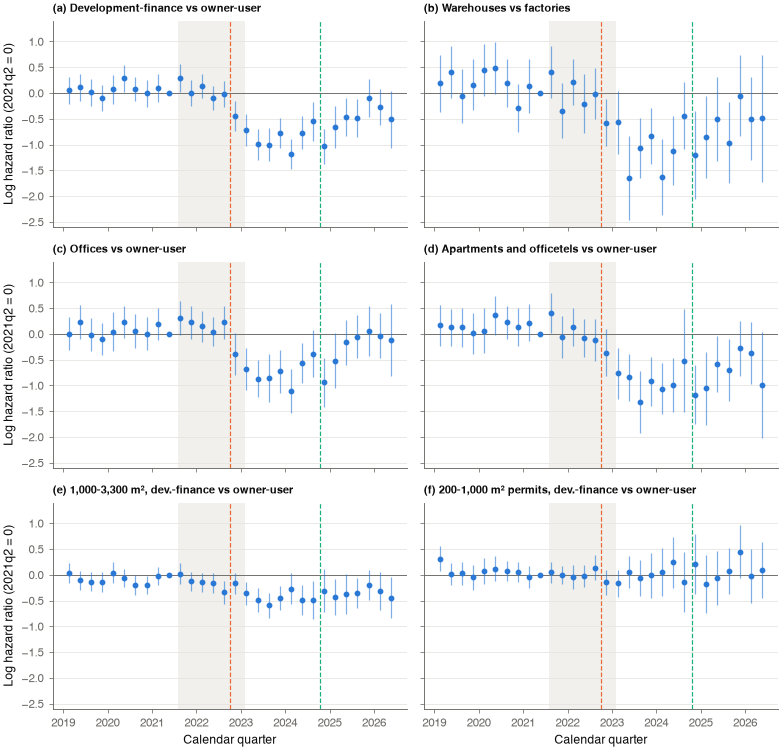

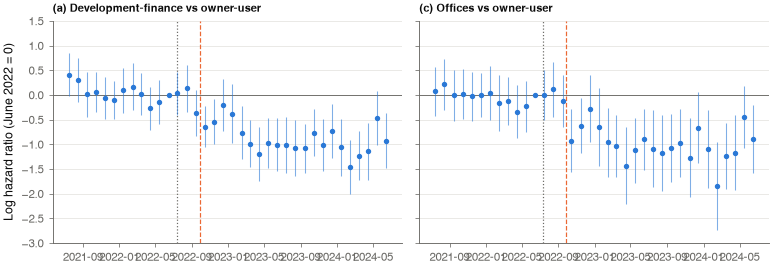

In [19]:
def qtr(c): return c.astype(str).str[:4] + "Q" + ((c.dt.month - 1) // 3 + 1).astype(str)
def cal_es(qq, treat, unit="q", ref="2021Q2", calmin="2019-01"):
    r, _ = cal_panel(qq, treat, calmin); r["u"] = qtr(r.cal) if unit == "q" else r.cal.astype(str).str.replace("-", "m")
    us = [x for x in sorted(r.u.unique()) if x != ref]
    for x in us: r["e_" + x] = ((r.u == x) & (r.tr == 1)).astype(int)
    m = pf.fepois("y ~ " + "+".join("e_" + x for x in us) + " | cal_s + g + tr_db", r, vcov={"CRV1": "cl"}); t = m.tidy()
    return pd.DataFrame([dict(u=x, est=t.loc["e_" + x, "Estimate"], se=t.loc["e_" + x, "Std. Error"]) for x in us] + [dict(u=ref, est=0.0, se=0.0)]).sort_values("u")
QS = {}
fig, axs = plt.subplots(3, 2, figsize=(7.2, 7.0), sharex=True, sharey=True)
for ax, (lab, qq, tr) in zip(axs.flat, DESIGNS[:6]):
    o = cal_es(qq, tr); QS[lab] = o; x = o.u.str[:4].astype(int) + (o.u.str[-1].astype(int) - 1) / 4 + .125
    ax.axvspan(2021 + 7 / 12, 2023 + 1 / 12, color="#f1f0ec", lw=0, zorder=0); ax.axvline(2022 + 9 / 12, color=ORANGE, lw=.8, ls="--"); ax.axvline(2024 + 9.5 / 12, color=GREEN, lw=.8, ls="--")
    ax.axhline(0, color=MUTED, lw=.6); ax.vlines(x, o.est - 1.96 * o.se, o.est + 1.96 * o.se, color=BLUE, lw=.8, alpha=.6); ax.plot(x, o.est, "o", ms=2.8, color=BLUE)
    ax.set_title(lab, fontsize=7.5); ax.set_ylim(-2.6, 1.4)
pd.concat([o.assign(design=lab) for lab, o in QS.items()]).to_csv(INT / "fig06_quarterly_coefficients.csv", index=False)
for ax in axs[:, 0]: ax.set_ylabel("Log hazard ratio (2021q2 = 0)")
for ax in axs[-1]: ax.set_xlabel("Calendar quarter")
fig.tight_layout(); savefig(fig, "fig06_freeze_quarterly")

fig, axs = plt.subplots(1, 2, figsize=(7.2, 2.6), sharey=True); MS2 = []
for ax, (lab, qq, tr) in zip(axs, [DESIGNS[0], DESIGNS[2]]):
    o = cal_es(qq, tr, unit="m", ref="2022m06", calmin="2021-01"); o = o[(o.u >= "2021m07") & (o.u <= "2024m06")]; MS2.append(o.assign(design=lab))
    x = pd.PeriodIndex(o.u.str.replace("m", "-"), freq="M").to_timestamp() + pd.Timedelta(days=14)
    ax.axhline(0, color=MUTED, lw=.6); ax.axvline(pd.Timestamp("2022-07-13"), color=MUTED, lw=.8, ls=":"); ax.axvline(pd.Timestamp("2022-09-28"), color=ORANGE, lw=.8, ls="--")
    ax.vlines(x, o.est - 1.96 * o.se, o.est + 1.96 * o.se, color=BLUE, lw=.7, alpha=.6); ax.plot(x, o.est, "o", ms=2.5, color=BLUE); ax.set_title(lab, fontsize=7.5); ax.set_ylim(-3, 1.5)
axs[0].set_ylabel("Log hazard ratio (June 2022 = 0)"); fig.tight_layout(); savefig(fig, "figS01_freeze_monthly")
pd.concat(MS2).to_csv(INT / "figS01_monthly_coefficients.csv", index=False)

**Table S7 (money-market stress and the policy rate).** Quarterly coefficients of design (a) in Figure 6, 2019q1–2026q2 (2021q2 = 0), regressed on the quarterly mean of the spread of 91-day commercial paper over 91-day certificates of deposit and on the quarterly mean of the Bank of Korea base rate (ECOS table 721Y001 and `kr_rates_monthly.csv`). Newey–West standard errors with four lags. Thirty quarterly observations, so the table describes co-movement and does not identify a channel.

In [20]:
cpcd = table("cp_cd", dtype={"ym": str}); cpcd["q"] = cpcd.ym.str[:4] + "Q" + ((cpcd.ym.str[4:6].astype(int) - 1) // 3 + 1).astype(str)
cpcd["spread"] = cpcd.cp_91d - cpcd.cd_91d
rq_ = rt.assign(q=rt.t.dt.year.astype(str) + "Q" + rt.t.dt.quarter.astype(str)).groupby("q").bok_base_rate.mean()
hq = QS[DESIGNS[0][0]].set_index("u")[["est", "se"]].join(cpcd.groupby("q").spread.mean()).join(rq_.rename("rate")).dropna()
hq["spread_lag"] = hq.spread.shift(1)
hr = []
for cols_ in (["spread"], ["rate"], ["spread", "rate"], ["spread", "spread_lag", "rate"]):
    z = hq.dropna(subset=cols_); mm = sm.OLS(z.est, sm.add_constant(z[cols_])).fit(cov_type="HAC", cov_kwds={"maxlags": 4}); hr.append(mm)
rows = []
for k, lab in [("spread", "CP$-$CD spread, pp"), ("spread_lag", "CP$-$CD spread, previous quarter"), ("rate", "Base rate, \\%")]:
    cs = [cell(mm.params[k], mm.bse[k], mm.pvalues[k]) if k in mm.params else ("", "") for mm in hr]; rows += [(lab, [c[0] for c in cs]), ("", [c[1] for c in cs])]
rows += ["gap", (r"$R^2$", [f"{mm.rsquared:.3f}" for mm in hr]), ("Quarters", [n_(mm.nobs) for mm in hr])]
write_table("tableS07_stress_rate", "lcccc", [r" & \multicolumn{4}{c}{Dependent variable: quarterly coefficient, dev.-finance vs owner-user (Figure 6a)} \\", r"\cmidrule(lr){2-5}", r" & (1) & (2) & (3) & (4) \\"], rows)

,(1),(2),(3),(4)
,"Dependent variable: quarterly coefficient, dev.-finance vs owner-user (Figure 6a)",,,
,(1),(2),(3),(4)
"CP-CD spread, pp",-0.320,,-0.055,0.134*
,(0.405),,(0.131),(0.080)
"CP-CD spread, previous quarter",,,,-0.341***
,,,,(0.122)
"Base rate, %",,-0.338***,-0.336***,-0.328***
,,(0.038),(0.037),(0.027)
R^2,0.031,0.774,0.775,0.807
Quarters,30,30,30,29


**Table 6.** Large warehouses (treated) versus large factories (control) across permit cohorts. OLS; permit cohorts from 2018h1, omitted cohort 2021h1; clustered by district. The wild cluster bootstrap uses Webb weights and 1,999 draws and is reported as n.a. when it contradicts the conventional $p$-value by construction.

In [21]:
PERIODS = [("pre", lambda d: d.h < "2021H1"), ("hike", lambda d: d.h.isin(["2021H2", "2022H1"])), ("post", lambda d: d.h >= "2022H2")]
def prep(qq, ycol, n, T):
    d = qq[(qq.permit >= "2018-01-01") & (qq.permit <= END - pd.DateOffset(months=n))].copy(); d["T"] = T(d).astype(int); d["y"] = d[ycol]
    for k, f_ in PERIODS: d["P_" + k] = f_(d).astype(int); d[k] = d["T"] * d["P_" + k]
    return d
def pretrend(d, fe, treat="T", extra=""):
    """Half-year event study; returns the joint F-test p-value of the pre-2021 coefficients, the model and the half-years."""
    hs = sorted(h for h in d.h.unique() if h != "2021H1"); d = d.copy()
    for h_ in hs: d["e_" + h_] = ((d.h == h_) & (d[treat] == 1)).astype(int)
    rhs = "+".join("e_" + h_ for h_ in hs) + extra
    m = pf.feols(f"y ~ {rhs} + {treat} + C(h)" if fe == "1" else f"y ~ {rhs} | {fe}", d, vcov={"CRV1": "cl"})
    pre = [f"e_{h_}" for h_ in hs if h_ < "2021H1"]; nm = list(m._coefnames); ix = [nm.index(k) for k in pre]
    b = np.asarray(m.coef()[pre]); V = np.asarray(m._vcov)[np.ix_(ix, ix)]
    return 1 - sst.f.cdf(float(b @ np.linalg.solve(V, b)) / len(pre), len(pre), d.cl.nunique() - 1), m, hs
def wild_p(m, term, seed):
    conv = m.tidy().loc[term, "Pr(>|t|)"]
    try:
        wp = float(m.wildboottest(param=term, reps=1999, seed=seed, weights_type="webb")["Pr(>|t|)"])
        return "n.a." if (conv > .5 and wp < .01) or (conv < .001 and wp > .5) else f"{wp:.3f}"
    except Exception: return "n.a."

WF = p[p.g.isin(["Warehouse", "Factory"])].copy(); LG = WF[WF.area >= 3300].copy(); isW = lambda d: d.g == "Warehouse"
SPEC = [("y12", 12, "pre + hike + post + T + P_pre + P_hike + P_post", "", "1", True), ("y12", 12, "pre + hike + post", "T + pm_s", "T + pm_s", True),
        ("y12", 12, "pre + hike + post", "T + pm_s + district", "T + pm_s + district", True), ("y12", 12, "pre + hike + post + lnarea", "T + pm_s + district + zone", "T + pm_s + district + zone", True),
        ("y12", 12, "pre + hike + post", "T + sgg_h", "T + sgg_h", False), ("y24", 24, "pre + hike + post", "T + pm_s + district", "T + pm_s + district", True),
        ("c36", 36, "pre + hike + post", "T + pm_s + district", "T + pm_s + district", True), ("c36", 36, "pre + hike + post", "T + sgg_h", "T + sgg_h", False)]
ms, info = [], []
for ycol, n, rhs, fe, fe_es, wild in SPEC:
    d = prep(LG, ycol, n, isW); m = pf.feols(f"y ~ {rhs}" + (f" | {fe}" if fe else ""), d, vcov={"CRV1": "cl"}); pt, _, _ = pretrend(d, fe_es)
    ms.append(m); info.append(dict(ci=ci(m, "post"), wild=wild_p(m, "post", 20260920) if wild else "n.a.", pt=f"{pt:.3f}", mt=d.loc[(d["T"] == 1) & (d.h <= "2021H1"), "y"].mean(),
                                   mc=d.loc[(d["T"] == 0) & (d.h <= "2021H1"), "y"].mean(), nt=int(d["T"].sum()), nc=int((1 - d["T"]).sum()), ntp=int(d.post.sum()), cl=d.cl.nunique()))
rows = [r"\multicolumn{9}{l}{\emph{Treated: large warehouses. Control: large factories. All permits have floor area of at least 3,300 m$^2$}} \\", "gap"]
rows += coef_rows(ms, [("pre", r"Warehouse $\times$ cohorts 2018h1--2020h2"), ("hike", r"Warehouse $\times$ cohorts 2021h2--2022h1"), ("post", r"Warehouse $\times$ cohorts 2022h2 onward"), None,
                       ("T", "Warehouse"), ("P_pre", "Cohorts 2018h1--2020h2"), ("P_hike", "Cohorts 2021h2--2022h1"), ("P_post", "Cohorts 2022h2 onward"), None, ("lnarea", "Log floor area"), None])
rows += [(r"95\% CI, Warehouse $\times$ 2022h2 onward", [i["ci"] for i in info]), (r"Wild cluster bootstrap $p$, same coefficient", [i["wild"] for i in info]),
         (r"Pre-period joint test ($p$-value)", [i["pt"] for i in info]), (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Adjusted $R^2$", [f"{m._adj_r2:.3f}" for m in ms]),
         (r"Within $R^2$", [f"{m._r2_within:.3f}" if np.isfinite(m._r2_within) else "" for m in ms]), ("Observations", [f"{m._N:,}" for m in ms]),
         ("Mean of dep. var., warehouses, cohorts to 2021h1", [f"{i['mt']:.2f}" for i in info]), ("Mean of dep. var., factories, cohorts to 2021h1", [f"{i['mc']:.2f}" for i in info]),
         ("Warehouse / factory permits", [f"{i['nt']:,} / {i['nc']:,}" for i in info]), ("Warehouse permits, cohorts 2022h2 onward", [f"{i['ntp']:,}" for i in info]),
         ("Clusters (districts)", [f"{i['cl']}" for i in info]), "mid", r"\multicolumn{9}{l}{\emph{Fixed effects and controls}} \\",
         (r"\quad Use", yn([i != 0 for i in range(8)])), (r"\quad Permit month", yn([i in (1, 2, 3, 5, 6) for i in range(8)])), (r"\quad District", yn([i in (2, 3, 5, 6) for i in range(8)])),
         (r"\quad Zoning category, log floor area", yn([i == 3 for i in range(8)])), (r"\quad District $\times$ half-year", yn([i in (4, 7) for i in range(8)]))]
write_table("table06_main_factory", "lcccccccc", [r" & \multicolumn{5}{c}{Started within 12 months ($\times$100)} & Started within & \multicolumn{2}{c}{Completed within 36 months} \\",
            r" & & & & & & 24 months ($\times$100) & \multicolumn{2}{c}{of permit ($\times$100)} \\", r"\cmidrule(lr){2-6}\cmidrule(lr){7-7}\cmidrule(lr){8-9}", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\"], rows)

,(1),(2),(3),(4),(5),(6),(7),(8)
,Started within 12 months (×100),Started within,Completed within 36 months,,,,,
,,,,,,24 months (×100),of permit (×100),
,(1),(2),(3),(4),(5),(6),(7),(8)
"Treated: large warehouses. Control: large factories. All permits have floor area of at least 3,300 m²",,,,,,,,
Warehouse × cohorts 2018h1–2020h2,5.21,4.89,1.25,-0.03,4.73,1.79,-2.83,7.39
,(6.77),(6.58),(6.88),(6.98),(8.37),(6.06),(5.84),(7.78)
Warehouse × cohorts 2021h2–2022h1,-10.56,-11.11*,-14.10**,-12.22*,-15.08**,-14.86**,-22.60***,-13.24*
,(6.82),(6.70),(6.72),(6.60),(7.33),(5.85),(5.64),(7.07)
Warehouse × cohorts 2022h2 onward,-35.37***,-34.42***,-35.98***,-34.63***,-30.45***,-41.81***,-45.53***,-36.39***
,(7.46),(7.44),(7.41),(7.63),(8.58),(8.15),(6.97),(8.74)


**Figure 7 and Table S8.** Half-year event study of large warehouses versus large factories (use, permit-month and district effects; 2021h1 = 0).

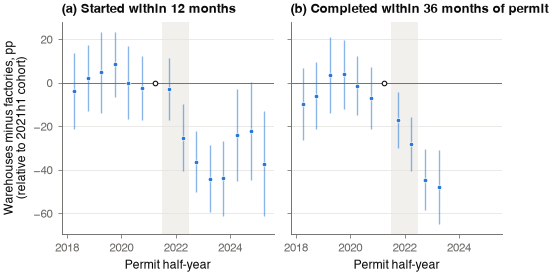

,(1),(2)
Permit half-year,Started within,Completed within 36
× warehouse,12 months (×100),months of permit (×100)
,(1),(2)
2018h1,-3.83,-9.74
,(8.88),(8.40)
2018h2,2.22,-5.90
,(7.75),(7.81)
2019h1,4.86,3.55
,(9.46),(8.86)
2019h2,8.51,3.95


In [22]:
es_rows, es_m = [], {}
for ycol, n in [("y12", 12), ("c36", 36)]:
    d = prep(LG, ycol, n, isW); pt, m, hs = pretrend(d, "T + pm_s + district"); t = m.tidy(); es_m[ycol] = (m, pt, d)
    for h_ in hs: es_rows.append(dict(outcome=ycol, half=h_, est=t.loc["e_" + h_, "Estimate"], se=t.loc["e_" + h_, "Std. Error"], lo=t.loc["e_" + h_, "2.5%"], hi=t.loc["e_" + h_, "97.5%"], p=t.loc["e_" + h_, "Pr(>|t|)"]))
es = pd.DataFrame(es_rows); es.to_csv(INT / "event_study_factory.csv", index=False)
hx = lambda hs: [int(h[:4]) + (.25 if h.endswith("1") else .75) for h in hs]
fig, axs = plt.subplots(1, 2, figsize=(5.17, 2.5), sharey=True, gridspec_kw={"wspace": .08})
for ax, (ycol, ttl) in zip(axs, [("y12", "(a) Started within 12 months"), ("c36", "(b) Completed within 36 months of permit")]):
    z = es[es.outcome == ycol]; x = hx(z.half); ax.axvspan(2021.5, 2022.5, color="#f1f0ec", lw=0, zorder=0); ax.axhline(0, color=MUTED, lw=.6)
    ax.vlines(x, z.lo, z.hi, color=BLUE, lw=.9, alpha=.55); ax.plot(x, z.est, "o", color=BLUE, ms=3, mec="white", mew=.5); ax.plot([2021.25], [0], "o", ms=3, mfc="white", mec=INK, mew=.7)
    ax.set_title(ttl); ax.set_xlabel("Permit half-year"); ax.set_xlim(2017.8, 2025.6)
axs[0].set_ylabel("Warehouses minus factories, pp\n(relative to 2021h1 cohort)"); savefig(fig, "fig07_event_study_factory")

g_ = {o: es[es.outcome == o].set_index("half") for o in ("y12", "c36")}; rows = []
for h_ in sorted(set(es.half)):
    a, b_ = [], []
    for o in ("y12", "c36"):
        if h_ in g_[o].index: r_ = g_[o].loc[h_]; a.append(f"${r_.est:.2f}{stars(r_.p)}$"); b_.append(f"$({r_.se:.2f})$")
        else: a.append(""); b_.append("")
    rows += [(h_.replace("H", "h"), a), ("", b_)] + (["gap"] if h_ == "2020H2" else [])
rows += ["mid", r"\multicolumn{3}{l}{\emph{Fixed effects}} \\", (r"\quad Use, permit month, district", ["Yes", "Yes"]), "gap",
         (r"Pre-period joint test ($p$-value)", [f"{es_m[o][1]:.3f}" for o in ("y12", "c36")]), (r"$R^2$", [f"{es_m[o][0]._r2:.3f}" for o in ("y12", "c36")]),
         (r"Within $R^2$", [f"{es_m[o][0]._r2_within:.3f}" for o in ("y12", "c36")]), ("Observations", [f"{es_m[o][0]._N:,}" for o in ("y12", "c36")]), ("Clusters (districts)", [f"{es_m[o][2].cl.nunique()}" for o in ("y12", "c36")])]
write_table("tableS08_es_factory", "lcc", [r"Permit half-year & Started within & Completed within 36 \\", r"$\times$ warehouse & 12 months ($\times$100) & months of permit ($\times$100) \\", r" & (1) & (2) \\"], rows)

**Table S9.** Alternative comparison groups, inverse-probability reweighting and regions. Reweighting: within each group, cohorts of the hike and post periods are reweighted to the pre-period distribution of log floor area, floor-area ratio, size above 10,000 m², Seoul metropolitan area, the most common zoning category and a corporate building name (logit propensity scores trimmed at 0.02 and 0.98).

In [23]:
def ipw(d, X):
    d = d.copy(); d["w"] = 1.0; d["period"] = np.where(d.P_post == 1, "post", np.where(d.P_hike == 1, "hike", "pre"))
    for T_ in (1, 0):
        for per in ("post", "hike"):
            s = d[(d["T"] == T_) & d.period.isin(["pre", per])]; z = (s.period == per).astype(int); Xv = [v for v in X if s[v].std() > 1e-8]
            if z.sum() < 20: continue
            Xm = sm.add_constant(s[Xv].astype(float)); ps = sm.Logit(z, Xm).fit(disp=0).predict(Xm).clip(.02, .98); wt = ((1 - ps) / ps)[z == 1]; d.loc[wt.index, "w"] = wt / wt.mean()
    return d
def covs(d):
    d["corp"] = d.corp_name.astype(float); d["far"] = (d.area / d.site_area.where(d.site_area > 0)).clip(upper=10); d["far"] = d.far.fillna(d.far.median())
    d["ge10k"] = (d.area >= 10000).astype(float); d["sma_f"] = d.sma.astype(float); d["zone1"] = (d.zone == d.zone.value_counts().index[0]).astype(float); return d
XV = ["lnarea", "far", "ge10k", "sma_f", "zone1", "corp"]; Wh = WF[WF.g == "Warehouse"]
COMP = [(LG, isW, None), (LG[LG.area >= 10000], isW, None), (LG, isW, "ipw"), (LG[LG.sma], isW, None), (LG[~LG.sma], isW, None),
        (Wh[(Wh.area >= 3300) | (Wh.area < 1000)], lambda d: d.area >= 3300, None), (Wh[Wh.area >= 1000], lambda d: d.area >= 3300, None),
        (Wh[(Wh.area >= 3300) | (Wh.area < 1000)], lambda d: d.area >= 3300, "ipwT")]
rows = []
for ycol, n, ttl in [("y12", 12, r"\multicolumn{9}{l}{\emph{Panel A. Dependent variable: construction started within 12 months of permit ($\times$100)}} \\"),
                     ("c36", 36, r"\multicolumn{9}{l}{\emph{Panel B. Dependent variable: completed within 36 months of permit ($\times$100)}} \\")]:
    res = []
    for qq, T, mode in COMP:
        d = prep(qq, ycol, n, T); kw = {}
        if mode:
            d = ipw(covs(d), XV); kw = dict(weights="w")
            if mode == "ipwT": d.loc[d["T"] == 0, "w"] = 1.0
        m = pf.feols("y ~ pre + hike + post | T + pm_s + district", d, vcov={"CRV1": "cl"}, **kw); m2 = pf.feols("y ~ pre + hike + post | T + sgg_h", d, vcov={"CRV1": "cl"}, **kw)
        res.append((m, m2, d))
    rows += [ttl, "gap"] + coef_rows([r[0] for r in res], [("pre", r"Treated $\times$ cohorts 2018h1--2020h2"), ("hike", r"Treated $\times$ cohorts 2021h2--2022h1"), ("post", r"Treated $\times$ cohorts 2022h2 onward")])
    rows += ["gap"] + coef_rows([r[1] for r in res], [("post", r"Treated $\times$ 2022h2 onward, district $\times$ half-year effects")])
    rows += ["gap", (r"$R^2$", [f"{r[0]._r2:.3f}" for r in res]), (r"Within $R^2$", [f"{r[0]._r2_within:.3f}" for r in res]), ("Observations", [f"{r[0]._N:,}" for r in res]),
             ("Median floor area, treated / control (m$^2$)", [f"{r[2].loc[r[2]['T'] == 1, 'area'].median():,.0f} / {r[2].loc[r[2]['T'] == 0, 'area'].median():,.0f}" for r in res]),
             ("Treated permits, cohorts 2022h2 onward", [f"{int(r[2].post.sum()):,}" for r in res]), ("Clusters (districts)", [f"{r[2].cl.nunique()}" for r in res])]
    if ycol == "y12": rows.append("mid")
rows += ["mid", r"\multicolumn{9}{l}{\emph{Fixed effects (coefficient rows)}} \\", (r"\quad Treated group, permit month, district", ["Yes"] * 8)]
write_table("tableS09_alt_comparisons", "lcccccccc", [r" & \multicolumn{5}{c}{Large warehouses vs.\ large factories} & \multicolumn{3}{c}{Warehouses $\geq$3,300 m$^2$ vs.\ smaller warehouses} \\", r"\cmidrule(lr){2-6}\cmidrule(lr){7-9}",
            r" & $\geq$3,300 m$^2$ & $\geq$10,000 m$^2$ & Reweighted & Seoul metro & Other regions & vs.\ $<$1,000 & vs.\ 1,000--3,300 & vs.\ $<$1,000, reweighted \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\"], rows)

,(1),(2),(3),(4),(5),(6),(7),(8)
,Large warehouses vs. large factories,"Warehouses ≥3,300 m² vs. smaller warehouses",,,,,,
,"≥3,300 m²","≥10,000 m²",Reweighted,Seoul metro,Other regions,"vs. <1,000","vs. 1,000–3,300","vs. <1,000, reweighted"
,(1),(2),(3),(4),(5),(6),(7),(8)
Panel A. Dependent variable: construction started within 12 months of permit (×100),,,,,,,,
Treated × cohorts 2018h1–2020h2,1.25,11.16,0.97,-0.56,4.88,2.67,2.92,2.18
,(6.88),(7.92),(6.94),(7.85),(12.15),(6.39),(7.34),(6.38)
Treated × cohorts 2021h2–2022h1,-14.10**,-7.34,-7.62,-12.97*,-14.31,-16.97***,-3.27,-11.01*
,(6.72),(8.82),(6.88),(7.06),(12.70),(6.24),(8.36),(6.35)
Treated × cohorts 2022h2 onward,-35.98***,-33.44***,-28.48***,-44.56***,-20.28,-41.68***,-26.50***,-32.86***
,(7.41),(8.97),(7.40),(7.31),(12.86),(6.72),(8.93),(7.28)


**Table S10, Panel A.** Monthly start hazard of the treated group relative to the comparison group and to earlier permit cohorts (2015m1–2019m6, calendar months before 2021m7) at the same duration since permit, averaged over duration bins with the weights of treated project-months. 95% intervals from a cluster bootstrap with 399 draws.

The bootstrap draws follow the seeds and the order of draws used for the paper: seed 20260920 for the warehouse–factory design and seed 20260919 for the development-finance design, whose stream is first advanced by the draws of two other bootstraps (a composition-fixed estimate and the large-versus-small warehouse design) that are not reported in the paper.

In [24]:
def hazard_att(q, rng, B=399, draws_only=False):
    r = panel(q, 24, cols=("cl", "pm", "T", "event", "permit", "treat"))
    r["per"] = np.where((r.permit >= "2015-01-01") & (r.permit < "2019-07-01") & (r.cal < "2021-07"), "ctrl",
               np.where(r.permit >= "2019-07-01", np.where(r.cal < "2021-07", "placebo", np.where(r.cal < "2022-07", "hike", "post")), "drop"))
    r = r[r.per != "drop"]; r["db"] = pd.cut(r.d, [-1, 2, 5, 11, 17, 23], labels=False)
    cnt = r.groupby(["cl", "treat", "per", "db"]).y.agg(["sum", "size"]).unstack(["treat", "per", "db"]).fillna(0)
    if draws_only:
        for _ in range(B): rng.integers(0, len(cnt), len(cnt))
        return None
    def fn(sv):
        o = {}
        for per in ["placebo", "hike", "post"]:
            w = sv["size"][True][per]; lv = lr = ws = 0.0
            for b_ in w.index:
                h = {(t_, q_): sv["sum"][t_][q_][b_] / sv["size"][t_][q_][b_] for t_ in (True, False) for q_ in (per, "ctrl")}
                if min(h.values()) <= 0 or not np.isfinite(list(h.values())).all(): continue
                lv += w[b_] * ((h[(True, per)] - h[(True, "ctrl")]) - (h[(False, per)] - h[(False, "ctrl")]))
                lr += w[b_] * (np.log(h[(True, per)] / h[(True, "ctrl")]) - np.log(h[(False, per)] / h[(False, "ctrl")])); ws += w[b_]
            o[(per, "level_pp")] = 100 * lv / ws if ws else np.nan; o[(per, "log_ratio")] = lr / ws if ws else np.nan
        return pd.Series(o)
    est = fn(cnt.sum()); A_ = cnt.values; bs = []
    for _ in range(B):
        w_ = np.bincount(rng.integers(0, len(cnt), len(cnt)), minlength=len(cnt)); bs.append(fn(pd.Series(w_ @ A_, index=cnt.columns)))
    bs = pd.DataFrame(bs); o = pd.DataFrame({"est": est, "se": bs.std(), "lo": bs.quantile(.025), "hi": bs.quantile(.975)}).reset_index()
    o.columns = ["calendar", "scale", "est", "se", "lo", "hi"]; return o

qf = p[p.g.isin(["Warehouse", "Factory"]) & (p.area >= 3300)].copy(); qf["treat"] = qf.g == "Warehouse"
att_wf = hazard_att(qf, np.random.default_rng(20260920))
rng = np.random.default_rng(20260919)
dW = did_data(W); cls = np.array(sorted(dW.cl.unique()))
for _ in range(399): rng.choice(cls, len(cls))                                     # draws of the composition-fixed bootstrap
wq = W[(W.large == 1) | (W.small == 1)].copy(); wq["treat"] = wq.large == 1; hazard_att(wq, rng, draws_only=True)
uq = p[(p.large == 1) & (p.fin != "mixed")].copy(); uq["treat"] = uq.fin == "finance"
att_fo = hazard_att(uq, rng)
att_wf.to_csv(INT / "hazard_att_warehouse_factory.csv", index=False); att_fo.to_csv(INT / "hazard_att_finance_owner.csv", index=False)

**Table S10, Panel B.** Rambachan and Roth (2023) bounds for the average 2022–2024 cohort effect in the annual event study of large warehouses versus large factories (base year 2020, pre-periods 2018 and 2019). `honestdid` 0.1.1 needs numpy 1.26, scipy 1.13, cvxpy 1.5 and pandas 2.2. If it is not importable in this kernel, the cell runs it with the interpreter named in the environment variable `HONESTDID_PYTHON` (see `requirements-honestdid.txt`); without either, it reads the bounds shipped in `data/honestdid_bounds_reference.csv`.

In [25]:
for lab, qq in [("nationwide", LG), ("SMA", LG[LG.sma])]:
    d = prep(qq, "y12", 12, isW); d = d[d.year <= 2024]; yrs = [2018, 2019, 2021, 2022, 2023, 2024]
    for y_ in yrs: d[f"e{y_}"] = ((d.year == y_) & (d["T"] == 1)).astype(int)
    m = pf.feols("y ~ " + "+".join(f"e{y_}" for y_ in yrs) + " | T + pm_s + district", d, vcov={"CRV1": "cl"}); nm = [f"e{y_}" for y_ in yrs]; ix = [list(m._coefnames).index(k) for k in nm]
    np.savez(INT / f"es_annual_factory_{lab}.npz", beta=np.asarray(m.coef()[nm]), V=np.asarray(m._vcov)[np.ix_(ix, ix)])
HD_CODE = textwrap.dedent('''
    import sys, numpy as np, pandas as pd, honestdid as H
    INT = sys.argv[1]; rows = []
    for lab in ("nationwide", "SMA"):
        z = np.load(f"{INT}/es_annual_factory_{lab}.npz"); beta, V = z["beta"], z["V"]; npre, npost = 2, 4; l = np.array([0, 1 / 3, 1 / 3, 1 / 3])
        o = H.constructOriginalCS(beta, V, npre, npost, l_vec=l); rows.append(dict(spec=lab, restriction="parallel trends", M=0.0, lb=float(np.ravel(o["lb"])[0]), ub=float(np.ravel(o["ub"])[0])))
        rm = H.createSensitivityResults_relativeMagnitudes(beta, V, npre, npost, Mbarvec=np.array([0.5, 1.0, 1.5, 2.0]), l_vec=l, gridPoints=400)
        rows += [dict(spec=lab, restriction="relative magnitudes", M=float(r["Mbar"]), lb=float(r["lb"]), ub=float(r["ub"])) for _, r in rm.iterrows()]
        sd = H.createSensitivityResults(beta, V, npre, npost, Mvec=np.array([0.0, 2.0, 5.0]), l_vec=l)
        rows += [dict(spec=lab, restriction="smoothness", M=float(r["M"]), lb=float(r["lb"]), ub=float(r["ub"])) for _, r in sd.iterrows()]
    pd.DataFrame(rows).to_csv(f"{INT}/honestdid_bounds.csv", index=False)
''')
try:
    import honestdid  # noqa: F401
    exec(HD_CODE.replace("INT = sys.argv[1]", f"INT = r'{INT}'")); src = "computed in this kernel"
except ImportError:
    py = os.environ.get("HONESTDID_PYTHON")
    if py:
        with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False) as f: f.write(HD_CODE)
        subprocess.run([py, f.name, str(INT)], check=True, capture_output=True); src = "computed with the interpreter in HONESTDID_PYTHON"
    else:
        table("honestdid_reference").to_csv(INT / "honestdid_bounds.csv", index=False); src = "read from the reference bounds in the data file"
hd = pd.read_csv(INT / "honestdid_bounds.csv"); print("Rambachan-Roth bounds", src)

def hz_cells(df, cal, sc):
    r_ = df[(df.calendar == cal) & (df.scale == sc)].iloc[0]; d = 3 if sc == "log_ratio" else 2
    return f"${r_.est:.{d}f}$ $({r_.se:.{d}f})$", f"$[{r_.lo:.{d}f},\\ {r_.hi:.{d}f}]$"
rows = [r"\multicolumn{6}{l}{\emph{Panel A. Monthly start hazard relative to earlier permit cohorts at the same duration}} \\"]
for cal, lab in [("placebo", "Before 2021m7 (placebo)"), ("hike", "2021m7--2022m6"), ("post", "2022m7 onward")]:
    for sc, sl in [("log_ratio", "Log hazard ratio"), ("level_pp", "Level, pp")]:
        x, y = hz_cells(att_wf, cal, sc), hz_cells(att_fo, cal, sc); rows.append((f"{lab if sc == 'log_ratio' else ''} & {sl}", [x[0], x[1], y[0], y[1]]))
rows += ["mid", r"\multicolumn{6}{l}{\emph{Panel B. Sensitivity of the 2022--2024 average effect to violations of parallel trends, large warehouses vs.\ large factories}} \\",
         r" & & \multicolumn{2}{c}{Nationwide} & \multicolumn{2}{c}{Seoul metropolitan area} \\", r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}", r"Restriction & Bound & \multicolumn{2}{c}{95\% robust interval} & \multicolumn{2}{c}{95\% robust interval} \\"]
def rr(res_, M): return [rf"\multicolumn{{2}}{{c}}{{$[{r_.lb:.1f},\ {r_.ub:.1f}]$}}" for sp in ("nationwide", "SMA") for r_ in [hd[(hd.spec == sp) & (hd.restriction == res_) & (hd.M.round(2) == M)].iloc[0]]]
rows.append(("Parallel trends & --", rr("parallel trends", 0.0)))
rows += [((r"Relative magnitudes, $\bar{M}$" if i == 0 else "") + f" & {M:g}", rr("relative magnitudes", M)) for i, M in enumerate([0.5, 1.0, 1.5, 2.0])]
rows += [((r"Smoothness, $M$ (pp per year$^2$)" if i == 0 else "") + f" & {M:g}", rr("smoothness", M)) for i, M in enumerate([0.0, 2.0, 5.0])]
write_table("tableS10_hazard_factory", "llcccc", [r" & & \multicolumn{2}{c}{Large warehouses vs.\ large factories} & \multicolumn{2}{c}{Large projects, dev.-finance vs.\ owner-user} \\",
            r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}", r"Calendar period & Scale & Estimate & 95\% interval & Estimate & 95\% interval \\"], rows)

Rambachan-Roth bounds read from the reference bounds in the data file


,(1),(2),(3),(4),(5)
,,Large warehouses vs. large factories,"Large projects, dev.-finance vs. owner-user",,
Calendar period,Scale,Estimate,95% interval,Estimate,95% interval
Panel A. Monthly start hazard relative to earlier permit cohorts at the same duration,,,,,
Before 2021m7 (placebo),Log hazard ratio,-0.043 (0.100),"[-0.237, 0.149]",-0.157 (0.055),"[-0.271, -0.057]"
,"Level, pp",-0.70 (1.43),"[-3.56, 1.89]",-1.61 (0.68),"[-2.93, -0.32]"
2021m7–2022m6,Log hazard ratio,-0.245 (0.132),"[-0.514, -0.012]",-0.206 (0.061),"[-0.329, -0.091]"
,"Level, pp",-1.03 (1.30),"[-3.80, 1.22]",-0.61 (0.56),"[-1.69, 0.40]"
2022m7 onward,Log hazard ratio,-0.928 (0.148),"[-1.189, -0.611]",-0.778 (0.076),"[-0.920, -0.631]"
,"Level, pp",-2.60 (0.51),"[-3.61, -1.59]",-2.37 (0.32),"[-2.90, -1.71]"
"Panel B. Sensitivity of the 2022–2024 average effect to violations of parallel trends, large warehouses vs. large factories",,,,,


## 7. Boom and regional conditions

**Table S14.** Large warehouses versus large factories by the district's warehouse building boom: floor area of large warehouse permits in 2020–2022h1 relative to 2.5 years of the 2014–2019 average, $R = \text{boom}/(\text{base} + 10{,}000)$. Quartiles are those of warehouse permits from 2018.

In [26]:
WL = p[(p.g == "Warehouse") & (p.area >= 3300)]
boom = WL[(WL.permit >= "2020-01-01") & (WL.permit < "2022-07-01")].groupby("district").area.sum()
base = WL[(WL.permit >= "2014-01-01") & (WL.permit < "2020-01-01")].groupby("district").area.sum() / 6 * 2.5
dist = pd.DataFrame({"boom": boom, "base": base}).fillna(0); dist["R"] = dist.boom / (dist.base + 10000)
LB = LG.join(dist[["R"]], on="district"); LB["R"] = LB.R.fillna(0)
qs = LB.loc[(LB.g == "Warehouse") & (LB.permit >= "2018-01-01"), "R"].quantile([.25, .5, .75]).values; LB["Q"] = np.digitize(LB.R, qs) + 1
def prep_boom(ycol, n):
    d = prep(LB, ycol, n, isW)
    d["H"] = (d.R > qs[1]).astype(int); d["Z"] = (d.R - d.loc[d["T"] == 1, "R"].mean()) / d.loc[d["T"] == 1, "R"].std()
    for k in ("pre", "hike", "post"):
        d[k + "_H"] = d[k] * d.H; d["P" + k + "_H"] = d["P_" + k] * d.H; d[k + "_Z"] = d[k] * d.Z; d["P" + k + "_Z"] = d["P_" + k] * d.Z
    d["T_H"] = d["T"] * d.H; d["T_Z"] = d["T"] * d.Z; return d
rows = []
for ycol, n, ttl in [("y12", 12, r"\emph{Panel A. Construction started within 12 months of permit ($\times$100)}"), ("c36", 36, r"\emph{Panel B. Completed within 36 months of permit ($\times$100)}")]:
    d = prep_boom(ycol, n); ms, info = [], []
    for qq in (1, 2, 3, 4):
        s = d[d.Q == qq]; ms.append(pf.feols("y ~ pre + hike + post | g + pm_s + district", s, vcov={"CRV1": "cl"}))
        info.append(dict(rng=f"{s.loc[s['T'] == 1, 'R'].min():.1f}--{s.loc[s['T'] == 1, 'R'].max():.1f}", dists=s.loc[s["T"] == 1, "district"].nunique(), ntp=int(s.post.sum()), cl=s.cl.nunique()))
    for v in ("H", "Z"):
        ms.append(pf.feols(f"y ~ pre + hike + post + pre_{v} + hike_{v} + post_{v} + Ppre_{v} + Phike_{v} + Ppost_{v} + T_{v} | g + pm_s + district", d, vcov={"CRV1": "cl"}))
        info.append(dict(rng="All", dists=d.loc[d["T"] == 1, "district"].nunique(), ntp=int(d.post.sum()), cl=d.cl.nunique()))
    rows += [r"\multicolumn{7}{l}{" + ttl + r"} \\", "gap"]
    rows += coef_rows(ms, [("pre", r"Warehouse $\times$ cohorts 2018h1--2020h2"), ("hike", r"Warehouse $\times$ cohorts 2021h2--2022h1"), ("post", r"Warehouse $\times$ cohorts 2022h2 onward"),
                           ("post_H", r"Warehouse $\times$ 2022h2 onward $\times$ boom above median"), ("post_Z", r"Warehouse $\times$ 2022h2 onward $\times$ boom (standardised)")])
    rows += ["gap", (r"95\% CI, 2022h2 onward (1)--(4) or its interaction (5)--(6)", [ci(m, k) for m, k in zip(ms, ["post"] * 4 + ["post_H", "post_Z"])]),
             ("Boom intensity of treated districts", [i["rng"] for i in info]), ("Districts with large warehouse permits", [n_(i["dists"]) for i in info]),
             ("Warehouse permits, cohorts 2022h2 onward", [n_(i["ntp"]) for i in info]), (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), ("Observations", [n_(m._N) for m in ms]), ("Clusters (districts)", [n_(i["cl"]) for i in info])]
    if ycol == "y12": rows.append("mid")
rows += ["mid", (r"Use, permit month and district effects", ["Yes"] * 6)]
write_table("tableS14_boom", "lcccccc", [r" & \multicolumn{4}{c}{Quartile of district boom intensity} & \multicolumn{2}{c}{All districts} \\", r"\cmidrule(lr){2-5}\cmidrule(lr){6-7}",
            r" & Lowest & Second & Third & Highest & Interaction & Interaction \\", r" & (1) & (2) & (3) & (4) & (5) & (6) \\"], rows)

,(1),(2),(3),(4),(5),(6)
,Quartile of district boom intensity,All districts,,,,
,Lowest,Second,Third,Highest,Interaction,Interaction
,(1),(2),(3),(4),(5),(6)
Panel A. Construction started within 12 months of permit (×100),,,,,,
Warehouse × cohorts 2018h1–2020h2,-14.57*,16.73,2.63,-8.41,4.15,-2.30
,(8.78),(14.09),(10.10),(13.40),(8.19),(6.30)
Warehouse × cohorts 2021h2–2022h1,-28.43***,13.50,-14.83*,-25.85*,-5.59,-15.86***
,(9.99),(11.36),(7.35),(13.88),(7.03),(5.88)
Warehouse × cohorts 2022h2 onward,-31.86***,-36.60**,-25.37***,-51.64***,-30.07***,-38.01***
,(7.04),(12.36),(7.89),(14.13),(8.64),(6.56)


**Table S15.** Regional demand and credit conditions. Province-level measures from the Bank of Korea (ECOS tables 141Y010, 141Y004, 132Y001), the MOLIT unsold-housing statistics and the Korea Real Estate Board vacancy survey (the raw files are in `data/regional/`; region and category labels are in Korean as published). Gwangju (29) and Jeonnam (46) are summed (averaged for vacancy rates) into code 12, the merged code of the register extract. Each measure is standardised across provinces and interacted with treated × post; standard errors are clustered by province (in brackets, by district), with a wild cluster bootstrap over provinces.

In [27]:
MERGE = {"29": "12", "46": "12"}
def rd(f):
    d = table("regional_" + f.removesuffix(".csv"), dtype={"sido_cd": str}); d["sido_cd"] = d.sido_cd.replace(MERGE); return d
nb = rd("ecos_141Y010_nonbank_corp_loans_sido_m.csv"); nb = nb[(nb.item_code == "AEX10000") & (nb.region_level == "시도")]            # 시도 = province
bk = rd("ecos_141Y004_bank_corp_loans_sido_m.csv"); bk = bk[(bk.item_code.astype(str) == "1A0000") & (bk.region_level == "시도")]
v = lambda d, inst, per: d[(d.inst_code.isin(inst)) & (d.period == per)].groupby("sido_cd").value.sum()
ALL, PFI = [920], [620, 660, 640]                                   # all non-banks; savings banks, credit unions and mutual finance
E = pd.DataFrame({"g_nb_1921": np.log(v(nb, ALL, "2021-12") / v(nb, ALL, "2019-12")), "g_pfi_1921": np.log(v(nb, PFI, "2021-12") / v(nb, PFI, "2019-12")),
                  "share_nb_2012": v(nb, ALL, "2020-12") / (v(nb, ALL, "2020-12") + bk[bk.period == "2020-12"].groupby("sido_cd").value.sum())})
ind = rd("ecos_132Y001_bank_industry_loans_sido_q.csv"); ind = ind[ind.period == "2020Q4"]
E["share_bank_recon_2020"] = ind[ind.item_code.isin(["F000000", "L000000"])].groupby("sido_cd").value.sum() / ind[ind.item_code == "X000000"].groupby("sido_cd").value.sum()   # real estate + construction
un = rd("unsold_housing_sido_m.csv"); un = un[(un.series == "unsold_total") & (un.region_level == "시도")].groupby(["sido_cd", "period"]).value.sum().unstack()
E["d_unsold"] = np.log((un["2023-06"] + 100) / (un["2022-06"] + 100))
vac = rd("reb_commercial_vacancy_sido_q.csv"); vo = vac[(vac.property_type == "오피스") & (vac.region_level == "시도")]                   # 오피스 = office
E["d_office_vac"] = vo[vo.year == 2023].groupby("sido_cd").value.mean() - vo[vo.year == 2021].groupby("sido_cd").value.mean()
E["office_vac_2023"] = vo[vo.year == 2023].groupby("sido_cd").value.mean()
E.index.name = "sido_cd"; E.to_csv(INT / "regional_measures.csv"); display(E.round(3))

p["sido"] = p.sido_cd.replace({"51": "42", "52": "45"})          # new codes of Gangwon and Jeonbuk
LL = p[(p.large == 1) & p.fin.isin(["finance", "owner"]) & (p.permit >= "2018-01-01") & (p.permit <= END - pd.DateOffset(months=12))].copy()
LL = LL[(LL.h <= "2021H1") | LL.h.between("2022H2", "2024H1")].copy(); LL["Post"] = (LL.h >= "2022H2").astype(int); LL["y"] = LL.y12; LL["sido_cl"] = pd.factorize(LL.sido)[0]
REG = [("d_unsold", LL[LL.g.isin(["Apartments", "Officetel"]) | (LL.fin == "owner")], lambda d: d.g.isin(["Apartments", "Officetel"])),
       ("d_office_vac", LL[(LL.g == "Office") | (LL.fin == "owner")], lambda d: d.g == "Office"), ("office_vac_2023", LL[(LL.g == "Office") | (LL.fin == "owner")], lambda d: d.g == "Office"),
       ("g_nb_1921", LL, isF), ("g_pfi_1921", LL, isF), ("share_nb_2012", LL, isF), ("share_bank_recon_2020", LL, isF)]
out = []
for e, d, tr in REG:
    d = d.join(E[[e]], on="sido").dropna(subset=[e]).copy(); d["Ez"] = (d[e] - E[e].mean()) / E[e].std(); t_ = tr(d).astype(int)
    d["TP"] = t_ * d.Post; d["TPE"] = d.TP * d.Ez; d["PE"] = d.Post * d.Ez; d["TE"] = t_ * d.Ez
    m = pf.feols("y ~ TP + TPE + PE + TE | g + pm_s + district", d, vcov={"CRV1": "sido_cl"}); md = pf.feols("y ~ TP + TPE + PE + TE | g + pm_s + district", d, vcov={"CRV1": "cl"})
    try: wb = float(m.wildboottest(param="TPE", reps=1999, seed=1, weights_type="webb")["Pr(>|t|)"])
    except Exception: wb = np.nan
    out.append(dict(m=m, md=md, wb=wb, nprov=d.sido.nunique(), ntp=int(d.TP.sum())))
ms = [x["m"] for x in out]; rows = coef_rows(ms, [("TP", r"Treated $\times$ cohorts 2022h2--2024h1"), ("TPE", r"Treated $\times$ cohorts 2022h2--2024h1 $\times$ regional measure")])
rows += [("", [f"[{x['md'].tidy().loc['TPE', 'Std. Error']:.2f}]" for x in out]), "gap", (r"95\% CI, interaction (province clusters)", [ci(m, "TPE") for m in ms]),
         ("Wild cluster bootstrap $p$, interaction (provinces)", [f"{x['wb']:.3f}" if np.isfinite(x["wb"]) else "n.a." for x in out]), (r"$R^2$", [f"{m._r2:.3f}" for m in ms]),
         ("Observations", [n_(m._N) for m in ms]), ("Treated permits, cohorts 2022h2--2024h1", [n_(x["ntp"]) for x in out]), ("Provinces", [n_(x["nprov"]) for x in out]),
         "mid", (r"Use, permit month and district effects", ["Yes"] * 7)]
write_table("tableS15_regional", "lccccccc", [r" & Apartments, & \multicolumn{2}{c}{Offices} & \multicolumn{4}{c}{Development-finance uses} \\", r"\cmidrule(lr){3-4}\cmidrule(lr){5-8}",
            r" & officetels & Change in & Vacancy & Non-bank & Savings banks, & Non-bank & Bank real estate \\", r" & Change in & vacancy & rate & corporate loan & credit unions & share of & and construction \\",
            r" & unsold units & 2021--23 & 2023 & growth 2019--21 & growth 2019--21 & corporate loans & loan share \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) \\"], rows)

,g_nb_1921,g_pfi_1921,share_nb_2012,share_bank_recon_2020,d_unsold,d_office_vac,office_vac_2023
sido_cd,,,,,,,
11,0.506,0.522,0.171,0.311,0.447,-2.133,5.929
12,0.520,0.530,0.287,0.205,0.400,-0.377,20.425
26,0.324,0.533,0.207,0.246,0.853,1.389,17.592
27,0.587,0.646,0.204,0.219,0.524,-9.610,10.120
28,0.400,0.382,0.191,0.208,1.470,0.545,19.523
30,0.657,0.752,0.248,0.231,1.077,-0.742,15.098
31,0.599,0.696,0.224,0.171,1.614,-2.820,16.313
36,0.481,0.514,0.357,0.396,0.507,NaN,NaN
41,0.617,0.627,0.218,0.224,0.762,-1.212,4.851


,(1),(2),(3),(4),(5),(6),(7)
,"Apartments,",Offices,Development-finance uses,,,,
,officetels,Change in,Vacancy,Non-bank,"Savings banks,",Non-bank,Bank real estate
,Change in,vacancy,rate,corporate loan,credit unions,share of,and construction
,unsold units,2021–23,2023,growth 2019–21,growth 2019–21,corporate loans,loan share
,(1),(2),(3),(4),(5),(6),(7)
Treated × cohorts 2022h2–2024h1,-35.97***,-31.90***,-27.41***,-33.22***,-32.62***,-28.75***,-30.05***
,(3.62),(3.01),(4.35),(3.08),(2.68),(2.76),(3.09)
Treated × cohorts 2022h2–2024h1 × regional measure,2.29,-5.62,3.30,0.98,-4.05,9.41***,-6.23
,(3.19),(5.79),(2.77),(3.56),(3.55),(2.76),(3.69)
,[3.87],[4.50],[2.50],[2.59],[3.10],[2.78],[2.88]


## 8. Price indices (Appendix C)

Quarterly time-dummy hedonic indices for warehouses (floor area of at least 3,300 m², Seoul metropolitan area, 2006–2026q2), offices and retail buildings (floor area of at least 1,000 m², 2018–2026) from the MOLIT transaction records: whole-building sales, excluding unit and share sales and cancelled contracts, with the log price per m² trimmed at 0.5 percent in each tail. The files in `data/hedonic_*.parquet` hold the estimation samples. Regressors: log floor area, log site area, age and its square, missing-value indicators, a pre-completion indicator, zoning groups, district effects and quarter dummies; the base quarter is the earliest with at least five sales. Collinear columns are dropped in column order, so quarter dummies take priority over district effects. The annual price level is the exponential of the mean quarterly coefficient in the year. Apartment and officetel prices are the nationwide sales price indices of the Korea Real Estate Board (annual means).

In [28]:
HED_X = ["ln_gfa", "ln_land", "land_missing", "age", "age2", "age_missing", "pre_completion"]
def drop_dependent(X, tol=1e-8):
    """Drop linearly dependent columns in column order (modified Gram-Schmidt)."""
    A_ = X.to_numpy(dtype=float); Q = np.zeros_like(A_); keep, j = [], 0
    for i in range(A_.shape[1]):
        v_ = A_[:, i].copy()
        if j > 0: v_ -= Q[:, :j] @ (Q[:, :j].T @ v_); v_ -= Q[:, :j] @ (Q[:, :j].T @ v_)
        nv = np.linalg.norm(v_)
        if nv / max(np.linalg.norm(A_[:, i]), 1.0) > tol: Q[:, j] = v_ / nv; j += 1; keep.append(X.columns[i])
    return X[keep]
def hedonic_index(d):
    d = d.copy(); d["quarter"] = d.year.astype(str) + "Q" + d.qnum.astype(str)
    cnt = d.groupby("quarter").size(); base_q = sorted(cnt[cnt >= 5].index)[0]
    X = pd.concat([pd.DataFrame({"const": 1.0}, index=d.index), d[HED_X].astype(float), pd.get_dummies(d.zone, prefix="zone", drop_first=True, dtype=float),
                   pd.get_dummies(d.quarter, prefix="T", dtype=float).drop(columns=f"T_{base_q}"),
                   pd.get_dummies(d.sgg_cd, prefix="sgg", dtype=float).drop(columns=f"sgg_{d.sgg_cd.value_counts().index[0]}")], axis=1)
    X = drop_dependent(X[[c for c in X.columns if c == "const" or X[c].std() > 0]])
    res_ = sm.OLS(d.ln_p.to_numpy(), X.to_numpy()).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d.sgg_cd)[0]})
    b = pd.Series(res_.params, index=X.columns)
    idx = pd.DataFrame({"quarter": sorted(d.quarter.unique())}); idx["log_index"] = [0.0 if q_ == base_q else b.get(f"T_{q_}", np.nan) for q_ in idx.quarter]
    idx["year"] = idx.quarter.str[:4].astype(int)
    V = pd.DataFrame(res_.cov_params(), index=X.columns, columns=X.columns); return idx, res_.rsquared, d, V, res_, list(X.columns), base_q
def annual_change(idx, V, y, y0=2022):
    """Change of the annual price level in year y relative to y0, % and 95% interval (delta method on the quarter coefficients)."""
    w = pd.Series(0.0, index=V.index)
    for yy, sgn in [(y, 1), (y0, -1)]:
        qs = idx[(idx.year == yy) & idx.log_index.notna()].quarter
        for q_ in qs:
            if f"T_{q_}" in w.index: w[f"T_{q_}"] += sgn / len(qs)
    L = idx[(idx.year == y) & idx.log_index.notna()].log_index.mean() - idx[(idx.year == y0) & idx.log_index.notna()].log_index.mean()
    se = float(np.sqrt(w @ V @ w)); return 100 * (np.exp(L) - 1), 100 * (np.exp(L - 1.96 * se) - 1), 100 * (np.exp(L + 1.96 * se) - 1)
PRICE, PRICE_CI, hed_info, HED = {}, {}, [], {}
for use_, f in [("Warehouse", "warehouse"), ("Office", "office"), ("Retail", "retail")]:
    idx, r2, d, V, res_, xcols, base_q = hedonic_index(table(f"hedonic_{f}", dtype={"zone": str, "sgg_cd": str})); idx.to_csv(INT / f"hedonic_index_{f}.csv", index=False)
    HED[use_] = dict(idx=idx, d=d, V=V, res=res_, cols=xcols, base=base_q)
    lvl = idx.groupby("year").log_index.mean(); PRICE[use_] = tuple(100 * (np.exp(lvl[y] - lvl[2022]) - 1) for y in (2023, 2024))
    PRICE_CI[use_] = tuple(annual_change(idx, V, y)[1:] for y in (2023, 2024))
    hed_info.append(dict(use=use_, sales=len(d), first_year=d.year.min(), districts=d.sgg_cd.nunique(), r2=round(r2, 3), **{f"sales_{y}": int((d.year == y).sum()) for y in (2022, 2023, 2024)},
                         price_2023_vs_2022=round(PRICE[use_][0], 1), price_2024_vs_2022=round(PRICE[use_][1], 1),
                         ci_2023=tuple(round(v, 1) for v in PRICE_CI[use_][0]), ci_2024=tuple(round(v, 1) for v in PRICE_CI[use_][1])))
reb = table("reb_price"); reb = reb[reb.CLS_NM == "전국"]                       # 전국 = nationwide
reb["year"] = reb.ym.astype(str).str[:4].astype(int); ry = reb.groupby(["series", "year"]).DTA_VAL.mean().unstack()
for use_, s in [("Apartments", "apartment_sales_index"), ("Officetel", "officetel_sales_index")]:
    PRICE[use_] = tuple(round(100 * (ry.loc[s, y] / ry.loc[s, 2022] - 1), 1) for y in (2023, 2024))
    hed_info.append(dict(use=use_, price_2023_vs_2022=PRICE[use_][0], price_2024_vs_2022=PRICE[use_][1]))
display(pd.DataFrame(hed_info))

,use,sales,first_year,districts,r2,sales_2022,sales_2023,sales_2024,price_2023_vs_2022,price_2024_vs_2022,ci_2023,ci_2024
0,Warehouse,458.0,2006.0,37.0,0.759,40.0,29.0,36.0,-21.0,-13.3,"(-35.0, -4.0)","(-25.9, 1.4)"
1,Office,948.0,2018.0,58.0,0.776,87.0,64.0,80.0,-5.3,8.9,"(-13.3, 3.4)","(-2.6, 21.8)"
2,Retail,4709.0,2018.0,81.0,0.792,487.0,266.0,374.0,-4.9,-1.7,"(-10.3, 0.8)","(-7.4, 4.4)"
3,Apartments,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.6,-10.9,NaN,NaN
4,Officetel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.7,-4.6,NaN,NaN


**Table C.1 and Figure C.1.** The hedonic regressions behind the price indices of Appendix C (coefficients on the building characteristics and zoning groups; the quarter and district effects are not shown) and the quarterly indices relative to their 2022 average from 2018, with 95% intervals from the cluster-robust covariance of the quarter coefficients. The full index series are written to `output/intermediate/price_indices_2022base.csv`.

,(1),(2),(3)
,Warehouses,Offices,Retail
,"≥3,300 m²","≥1,000 m²","≥1,000 m²"
,(1),(2),(3)
Log floor area,-0.264***,-0.462***,-0.477***
,(0.065),(0.036),(0.023)
Log site area,0.374***,0.598***,0.529***
,(0.069),(0.040),(0.025)
Building age (years),-0.027***,-0.024***,-0.022***
,(0.005),(0.004),(0.003)
Building age squared,0.047***,0.049***,0.044***


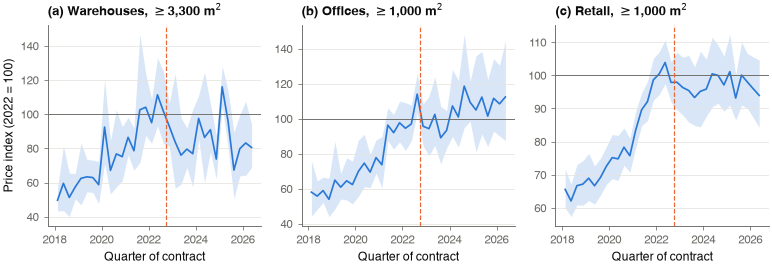

In [29]:
HLAB = {"ln_gfa": "Log floor area", "ln_land": "Log site area", "land_missing": "Site area missing", "age": "Building age (years)", "age2": "Building age squared",
        "age_missing": "Building age missing", "pre_completion": "Sale before completion"}
ZLAB = {"planned_management": "planned management", "industrial": "industrial", "green": "green", "distribution_commercial": "distribution commercial",
        "management_other": "other management", "residential": "residential", "commercial_other": "other commercial", "unspecified": "unspecified"}
HU = ["Warehouse", "Office", "Retail"]
def hed_cell(h, name):
    if name not in h["cols"]: return "", ""
    k = h["cols"].index(name); return cell(h["res"].params[k], h["res"].bse[k], h["res"].pvalues[k], 3)
zones = sorted({c for u in HU for c in HED[u]["cols"] if c.startswith("zone_")})
rows = []
for v in [v for v in HED_X if any(v in HED[u]["cols"] for u in HU)]:                    # characteristics estimated in at least one sample
    cs = [hed_cell(HED[u], v) for u in HU]; rows += [(HLAB[v], [c[0] for c in cs]), ("", [c[1] for c in cs])]
rows.append("gap")
for z in zones:
    cs = [hed_cell(HED[u], z) for u in HU]; rows += [("Zoning group: " + ZLAB[z[5:]], [c[0] for c in cs]), ("", [c[1] for c in cs])]
rows += ["mid", ("Omitted zoning group", [ZLAB[sorted(HED[u]["d"].zone.unique())[0]] for u in HU]), ("Base quarter", [HED[u]["base"].replace("Q", "q") for u in HU]),
         ("Sale years", [f"{HED[u]['d'].year.min()}--{HED[u]['d'].year.max()}" for u in HU]), ("Sales", [n_(HED[u]["res"].nobs) for u in HU]),
         ("Quarters", [n_(HED[u]["d"].quarter.nunique()) for u in HU]), ("Districts", [n_(HED[u]["d"].sgg_cd.nunique()) for u in HU]),
         (r"$R^2$", [f"{HED[u]['res'].rsquared:.3f}" for u in HU]), (r"Adjusted $R^2$", [f"{HED[u]['res'].rsquared_adj:.3f}" for u in HU]),
         "mid", r"\multicolumn{4}{l}{\emph{Fixed effects}} \\", (r"\quad Quarter of contract", ["Yes"] * 3), (r"\quad District", ["Yes"] * 3)]
write_table("tableC1_hedonic", "lccc", [r" & Warehouses & Offices & Retail \\", r" & $\geq$3,300 m$^2$ & $\geq$1,000 m$^2$ & $\geq$1,000 m$^2$ \\", r" & (1) & (2) & (3) \\"], rows)

def rebased(h, y0=2022):
    """Quarterly index relative to the average of year y0 (= 100), with a 95% interval (delta method on the quarter coefficients)."""
    idx, V = h["idx"].dropna(subset=["log_index"]), h["V"]; q0 = [q for q in idx.quarter if q.startswith(str(y0))]
    L0 = idx.set_index("quarter").loc[q0, "log_index"].mean(); out = []
    for q, li in zip(idx.quarter, idx.log_index):
        w = pd.Series(0.0, index=V.index)
        if f"T_{q}" in w.index: w[f"T_{q}"] += 1.0
        for q_ in q0:
            if f"T_{q_}" in w.index: w[f"T_{q_}"] -= 1 / len(q0)
        se = float(np.sqrt(w @ V @ w)); out.append(dict(quarter=q, index=100 * np.exp(li - L0), lo=100 * np.exp(li - L0 - 1.96 * se), hi=100 * np.exp(li - L0 + 1.96 * se)))
    o = pd.DataFrame(out); o["x"] = o.quarter.str[:4].astype(int) + (o.quarter.str[-1].astype(int) - 1) / 4 + .125; return o
fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.6))
IDX = []
for ax, u, ttl in zip(axs, HU, ["(a) Warehouses, $\\geq$3,300 m$^2$", "(b) Offices, $\\geq$1,000 m$^2$", "(c) Retail, $\\geq$1,000 m$^2$"]):
    o = rebased(HED[u]); IDX.append(o.assign(use=u)); o = o[o.x >= 2018]                  # plotted from 2018 (the warehouse index starts in 2006)
    ax.fill_between(o.x, o.lo, o.hi, color=BLUE, alpha=.18, lw=0); ax.plot(o.x, o["index"], color=BLUE, lw=1.1)
    ax.axhline(100, color=MUTED, lw=.6); ax.axvline(2022.75, color=ORANGE, lw=.8, ls="--"); ax.set_title(ttl); ax.set_xlabel("Quarter of contract")
axs[0].set_ylabel("Price index (2022 = 100)"); fig.tight_layout(); savefig(fig, "figC1_price_indices")
pd.concat(IDX).round(3).to_csv(INT / "price_indices_2022base.csv", index=False)

## 9. Property uses

Large permits (at least 3,300 m²) of development-finance uses (warehouses, knowledge-industry centres, officetels, lodging, apartments, offices, retail) and owner-user uses (factories, education and research, medical, welfare). Normal-times cohorts 2018h1–2021h1, tightening cohorts 2022h2–2024h1.

**Table 7.** Change in the 12-month start probability by use, with price changes.

In [30]:
U = p[(p.large == 1) & (p.fin != "mixed") & ok(p, 12) & (((p.h >= "2018H1") & (p.h <= "2021H1")) | ((p.h >= "2022H2") & (p.h <= "2024H1")))].copy()
U["po"] = (U.h >= "2022H2").astype(int); U["y"] = U.y12
chg = {}
for u in FIN + OWN:
    m = pf.feols("y ~ po", U[U.g == u], vcov={"CRV1": "cl"}); t = m.tidy().loc["po"]; chg[u] = (t["Estimate"], t["Std. Error"], t["Pr(>|t|)"])
fmt_pr = lambda x: f"{x:,.1f}".replace("-", "$-$") if np.isfinite(x) else "n.a."
rows = []
for grp, lab in [("finance", "Dev.-finance"), ("owner", "Owner-user")]:
    for u in sorted([u for u in FIN + OWN if (u in FIN) == (grp == "finance")], key=lambda u: chg[u][0]):
        x = U[U.g == u]; b, se, pv = chg[u]; pr = PRICE.get(u, (np.nan, np.nan))
        rows.append((f"{u} & {lab}", [f"{x.y[x.po == 0].mean():.1f}", f"{x.y[x.po == 1].mean():.1f}", f"${b:.1f}{stars(pv)}$", f"$({se:.1f})$", n_(len(x)), fmt_pr(pr[0]), fmt_pr(pr[1])]))
        if u in PRICE_CI: rows.append((" & ", [""] * 5 + [f"[{fmt_pr(lo)}, {fmt_pr(hi)}]" for lo, hi in PRICE_CI[u]]))
    rows.append("gap")
rows[-1] = "mid"; rows.append(("Observations, all uses & ", ["", "", "", "", n_(len(U)), "", ""]))
write_table("table07_uses_change", "llrrrrrrr", [r" & & \multicolumn{2}{c}{Start $\leq$12m (\%)} & & & & \multicolumn{2}{c}{Price vs.\ 2022 (\%)} \\", r"\cmidrule(lr){3-4}\cmidrule(lr){8-9}",
            r"Property use & Group & 2018h1--21h1 & 2022h2--24h1 & Change (pp) & SE & Observations & 2023 & 2024 \\"], rows)

,(1),(2),(3),(4),(5),(6),(7),(8)
,,Start ≤12m (%),,,,Price vs. 2022 (%),,
Property use,Group,2018h1–21h1,2022h2–24h1,Change (pp),SE,Observations,2023,2024
Knowledge-industry centre,Dev.-finance,84.2,28.0,-56.2***,(5.8),177,n.a.,n.a.
Warehouse,Dev.-finance,80.1,28.5,-51.6***,(4.9),975,-21.0,-13.3
,,,,,,,"[-35.0, -4.0]","[-25.9, 1.4]"
Apartments,Dev.-finance,68.1,18.3,-49.8***,(2.7),"1,498",-10.6,-10.9
Officetel,Dev.-finance,62.4,16.9,-45.4***,(5.3),296,-2.7,-4.6
Office,Dev.-finance,76.9,33.7,-43.2***,(2.4),"2,360",-5.3,8.9
,,,,,,,"[-13.3, 3.4]","[-2.6, 21.8]"
Lodging,Dev.-finance,57.8,27.1,-30.7***,(5.7),542,n.a.,n.a.


**Figure S2.** Share of large permits started within 12 months, by use and permit half-year (cells with at least 15 permits).

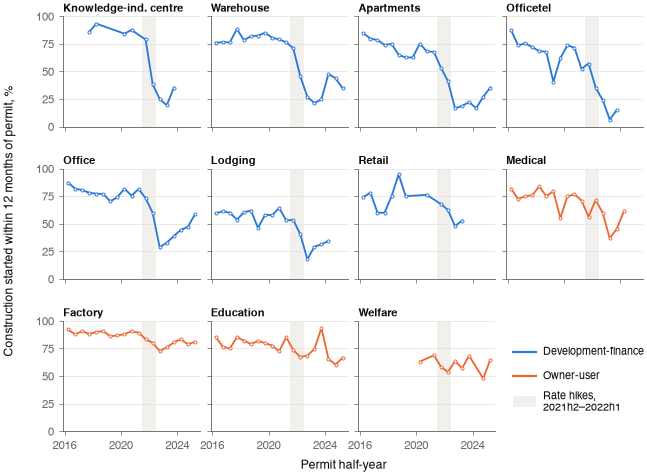

In [31]:
c = p[(p.large == 1) & (p.h >= "2016H1") & ok(p, 12) & (p.fin != "mixed")].groupby(["g", "h"]).y12.agg(["mean", "size"]).reset_index(); c = c[c["size"] >= 15]
order = ["Knowledge-industry centre", "Warehouse", "Apartments", "Officetel", "Office", "Lodging", "Retail", "Medical", "Factory", "Education", "Welfare"]
fig, axs = plt.subplots(3, 4, figsize=(6.8, 4.9), sharex=True, sharey=True, gridspec_kw={"hspace": .38, "wspace": .08})
for ax, g_ in zip(axs.ravel(), order):
    z = c[c.g == g_]; col = BLUE if g_ in FIN else ORANGE
    ax.axvspan(2021.5, 2022.5, color="#f1f0ec", lw=0, zorder=0); ax.plot(hx(z.h), z["mean"], color=col, lw=1.2, marker="o", ms=2, mfc="white", mew=.6)
    ax.set_title(g_.replace("Knowledge-industry centre", "Knowledge-ind. centre"), fontsize=7.5, fontweight="bold", color=INK, pad=3)
    ax.set_ylim(0, 100); ax.set_xlim(2015.9, 2025.6); ax.xaxis.set_major_locator(MultipleLocator(4)); ax.yaxis.set_major_locator(MultipleLocator(25))
ax = axs.ravel()[-1]; ax.axis("off")
ax.plot([.05, .22], [.72, .72], color=BLUE, lw=1.4, transform=ax.transAxes); ax.text(.27, .72, "Development-finance", transform=ax.transAxes, va="center", fontsize=7)
ax.plot([.05, .22], [.50, .50], color=ORANGE, lw=1.4, transform=ax.transAxes); ax.text(.27, .50, "Owner-user", transform=ax.transAxes, va="center", fontsize=7)
ax.add_patch(plt.Rectangle((.05, .22), .17, .1, transform=ax.transAxes, fc="#f1f0ec", ec="none")); ax.text(.27, .27, "Rate hikes,\n2021h2–2022h1", transform=ax.transAxes, va="center", fontsize=7, linespacing=1.05)
fig.supylabel("Construction started within 12 months of permit, %", fontsize=8, x=.045); fig.supxlabel("Permit half-year", fontsize=8, y=.035); savefig(fig, "figS02_uses_cohorts")

**Table 8 and Table S17.** Development-finance uses × tightening cohorts, starts within 12 months (Table 8) and 24 months (Table S17). The exact permutation $p$-value relabels which 7 of the 11 uses count as development-finance uses (330 relabellings) and reports the share with an estimate at or below the actual one.

In [32]:
def mk(d, fs):
    d = d.copy(); d["fin1"] = d.g.isin(fs).astype(int); d["fp"] = d.fin1 * d.po; return d
POOL_HEAD = [r" & \multicolumn{7}{c}{OLS, large permits, development-finance versus owner-user uses} \\", r"\cmidrule(lr){2-8}",
             r" & \multicolumn{5}{c}{Baseline classification} & Excl.\ office & Presale \\", r"\cmidrule(lr){2-6}", r" & & & & & & and retail & uses only \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) \\"]
for n, name in [(12, "table08_pooled"), (24, "tableS17_pooled24")]:
    Un = p[(p.large == 1) & (p.fin != "mixed") & ok(p, n) & (((p.h >= "2018H1") & (p.h <= "2021H1")) | ((p.h >= "2022H2") & (p.h <= ("2024H1" if n == 12 else "2023H2"))))].copy()
    Un["po"] = (Un.h >= "2022H2").astype(int); Un["y"] = Un[f"y{n}"]
    d0 = mk(Un, FIN); dA = mk(Un[~Un.g.isin(["Office", "Retail"])], [u for u in FIN if u not in ("Office", "Retail")])
    dB = mk(Un[~Un.g.isin(["Warehouse", "Office", "Retail"])], ["Apartments", "Officetel", "Knowledge-industry centre", "Lodging"])
    spec = [(d0, "y ~ fp + fin1 + po"), (d0, "y ~ fp | g + pm_s"), (d0, "y ~ fp | g + pm_s + district"), (d0, "y ~ fp + lnarea | g + pm_s + district"),
            (d0, "y ~ fp + lnarea | g + sgg_h"), (dA, "y ~ fp | g + pm_s + district"), (dB, "y ~ fp | g + pm_s + district")]
    ms = [pf.feols(f, d, vcov={"CRV1": "cl"}) for d, f in spec]; perm_p = [""] * 7
    if n == 12:
        b0 = ms[2].tidy().loc["fp", "Estimate"]
        perm = np.array([pf.feols("y ~ fp | g + pm_s + district", mk(Un, list(c_)), vcov={"CRV1": "cl"}).tidy().loc["fp", "Estimate"] for c_ in itertools.combinations(FIN + OWN, len(FIN))])
        perm_p[2] = f"{float((perm <= b0 + 1e-9).mean()):.3f}"; print("relabellings:", len(perm))
    rows = [rf"\multicolumn{{8}}{{l}}{{\emph{{Dependent variable is construction started within {n} months of permit ($\times$100)}}}} \\", "gap"]
    coh = "2022h2--2024h1" if n == 12 else "2022h2--2023h2"
    rows += coef_rows(ms, [("fp", rf"Dev.-finance use $\times$ cohorts {coh}"), None, ("fin1", "Dev.-finance use"), ("po", f"Cohorts {coh}"), ("lnarea", "Log floor area"), None])
    rows += [(r"95\% CI, interaction", [ci(m, "fp") for m in ms])] + ([(r"Exact permutation $p$ (330 relabellings)", perm_p)] if n == 12 else []) + [
             ("Mean of dep. var., dev.-finance, cohorts to 2021h1", [f"{d.loc[(d.fin1 == 1) & (d.po == 0), 'y'].mean():.2f}" for d, _ in spec]),
             ("Mean of dep. var., owner-user, cohorts to 2021h1", [f"{d.loc[(d.fin1 == 0) & (d.po == 0), 'y'].mean():.2f}" for d, _ in spec]),
             (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Adjusted $R^2$", [f"{m._adj_r2:.3f}" for m in ms]), (r"Within $R^2$", [f"{m._r2_within:.3f}" if np.isfinite(m._r2_within) else "" for m in ms]),
             ("Observations", [n_(m._N) for m in ms]), ("Clusters (districts)", [n_(d.cl.nunique()) for d, _ in spec]),
             ("Dev.-finance / owner-user permits", [f"{n_(d.fin1.sum())} / {n_((d.fin1 == 0).sum())}" for d, _ in spec]), ("Property uses", [n_(d.g.nunique()) for d, _ in spec]),
             "mid", r"\multicolumn{8}{l}{\emph{Fixed effects}} \\", (r"\quad Property use", yn([0, 1, 1, 1, 1, 1, 1])), (r"\quad Permit month", yn([0, 1, 1, 1, 0, 1, 1])),
             (r"\quad District", yn([0, 0, 1, 1, 0, 1, 1])), (r"\quad District $\times$ half-year", yn([0, 0, 0, 0, 1, 0, 0]))]
    write_table(name, "lccccccc", POOL_HEAD, rows)

relabellings: 330


,(1),(2),(3),(4),(5),(6),(7)
,"OLS, large permits, development-finance versus owner-user uses",,,,,,
,Baseline classification,Excl. office,Presale,,,,
,,,,,,and retail,uses only
,(1),(2),(3),(4),(5),(6),(7)
Dependent variable is construction started within 12 months of permit (×100),,,,,,,
Dev.-finance use × cohorts 2022h2–2024h1,-34.80***,-33.87***,-33.13***,-31.26***,-28.01***,-35.34***,-33.23***
,(2.40),(2.37),(2.42),(2.42),(2.50),(2.86),(2.68)
Dev.-finance use,-12.60***,,,,,,
,(1.14),,,,,,
Cohorts 2022h2–2024h1,-10.28***,,,,,,


,(1),(2),(3),(4),(5),(6),(7)
,"OLS, large permits, development-finance versus owner-user uses",,,,,,
,Baseline classification,Excl. office,Presale,,,,
,,,,,,and retail,uses only
,(1),(2),(3),(4),(5),(6),(7)
Dependent variable is construction started within 24 months of permit (×100),,,,,,,
Dev.-finance use × cohorts 2022h2–2023h2,-37.07***,-36.73***,-36.34***,-34.77***,-31.74***,-40.73***,-37.24***
,(2.55),(2.56),(2.53),(2.52),(2.50),(3.03),(2.93)
Dev.-finance use,-9.17***,,,,,,
,(1.06),,,,,,
Cohorts 2022h2–2023h2,-9.83***,,,,,,


**Table S18.** Table 8, column (3), excluding one development-finance use at a time.

In [33]:
def pooled(d, fs):
    d = d.copy(); d["fp"] = d.g.isin(fs).astype(int) * d.po
    return pf.feols("y ~ fp | g + pm_s + district", d, vcov={"CRV1": "cl"}), d.cl.nunique()
c11 = [pooled(U[U.g != u], [x for x in FIN if x != u]) for u in FIN]; ms = [m for m, _ in c11]
rows = coef_rows(ms, [("fp", r"Development-finance use $\times$ permit cohorts 2022h2--2024h1")])
rows += ["mid", r"\multicolumn{8}{l}{\emph{Fixed effects}} \\", (r"\quad Property use, permit month, district", ["Yes"] * 7), "gap",
         (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Within $R^2$", [f"{m._r2_within:.3f}" for m in ms]), ("Observations", [n_(m._N) for m in ms]), ("Clusters (districts)", [n_(G) for _, G in c11])]
write_table("tableS18_pooled_loo", "lccccccc", [r" & \multicolumn{7}{c}{Dependent variable is started within 12 months of permit ($\times$100), OLS, by excluded use} \\", r"\cmidrule(lr){2-8}",
            " & " + " & ".join(["Warehouse", "Knowl.-ind.", "Officetel", "Lodging", "Apartments", "Office", "Retail"]) + r" \\", " & " + " & ".join(f"({i})" for i in range(1, 8)) + r" \\"], rows)

,(1),(2),(3),(4),(5),(6),(7)
,"Dependent variable is started within 12 months of permit (×100), OLS, by excluded use",,,,,,
,Warehouse,Knowl.-ind.,Officetel,Lodging,Apartments,Office,Retail
,(1),(2),(3),(4),(5),(6),(7)
Development-finance use × permit cohorts 2022h2–2024h1,-31.64***,-32.87***,-33.00***,-34.76***,-31.43***,-34.31***,-33.72***
,(2.34),(2.43),(2.49),(2.45),(2.74),(2.82),(2.43)
Fixed effects,,,,,,,
"Property use, permit month, district",Yes,Yes,Yes,Yes,Yes,Yes,Yes
R^2,0.240,0.248,0.245,0.255,0.238,0.274,0.254
Within R^2,0.029,0.031,0.031,0.035,0.030,0.037,0.032
Observations,"9,152","9,952","9,833","9,587","8,629","7,765","9,952"


**Table S16.** Development-finance versus owner-user uses (large permits) by permit half-year (use, permit-month and district effects; 2021h1 = 0), and the corresponding difference in differences.

In [34]:
def es_uses(ycol, n):
    Ue = p[(p.large == 1) & (p.fin != "mixed") & (p.permit >= "2018-01-01") & (p.permit <= END - pd.DateOffset(months=n))].copy(); Ue["y"] = Ue[ycol]; Ue["D"] = (Ue.fin == "finance").astype(int)
    pj, m, hs = pretrend(Ue, "g + pm_s + district", treat="D")
    Q = Ue[(Ue.h <= "2021H1") | (Ue.h >= "2022H2")].copy(); Q["dp"] = Q.D * (Q.h >= "2022H2"); md = pf.feols("y ~ dp | g + pm_s + district", Q, vcov={"CRV1": "cl"})
    return m, hs, pj, Ue, md
RU = {k: es_uses(k, n) for k, n in [("y12", 12), ("c36", 36)]}
rows = [r"\multicolumn{3}{l}{\emph{Panel A. Dev.-finance use $\times$ permit half-year}} \\", "gap"]
for h_ in sorted(set(RU["y12"][1]) | set(RU["c36"][1])):
    a, b_ = [], []
    for k in ("y12", "c36"):
        m = RU[k][0]
        if "e_" + h_ in m._coefnames: t = m.tidy().loc["e_" + h_]; a.append(f"${t['Estimate']:.2f}{stars(t['Pr(>|t|)'])}$"); b_.append(f"$({t['Std. Error']:.2f})$")
        else: a.append(""); b_.append("")
    rows += [(h_.replace("H", "h"), a), ("", b_)] + (["gap"] if h_ == "2020H2" else [])
rows += ["gap", (r"Pre-period joint test ($p$-value)", [f"{RU[k][2]:.3f}" for k in ("y12", "c36")]), (r"$R^2$", [f"{RU[k][0]._r2:.3f}" for k in ("y12", "c36")]),
         ("Observations", [f"{RU[k][0]._N:,}" for k in ("y12", "c36")]), ("Clusters (districts)", [f"{RU[k][3].cl.nunique()}" for k in ("y12", "c36")]), "mid", r"\multicolumn{3}{l}{\emph{Panel B. Difference in differences}} \\", "gap"]
rows += coef_rows([RU[k][4] for k in ("y12", "c36")], [("dp", r"Dev.-finance $\times$ cohorts 2022h2 onward")])
rows += [(r"$R^2$", [f"{RU[k][4]._r2:.3f}" for k in ("y12", "c36")]), ("Observations", [f"{RU[k][4]._N:,}" for k in ("y12", "c36")]), ("Last permit cohort", ["2025h1", "2023h1"]),
         ("Clusters (districts)", [f"{RU[k][3].cl.nunique()}" for k in ("y12", "c36")]), "mid", r"\multicolumn{3}{l}{\emph{Fixed effects}} \\", (r"\quad Use, permit month, district", ["Yes", "Yes"])]
write_table("tableS16_es_uses", "lcc", [r" & Started within & Completed within 36 \\", r" & 12 months ($\times$100) & months of permit ($\times$100) \\", r" & (1) & (2) \\"], rows)

,(1),(2)
,Started within,Completed within 36
,12 months (×100),months of permit (×100)
,(1),(2)
Panel A. Dev.-finance use × permit half-year,,
2018h1,0.03,8.11*
,(3.60),(4.64)
2018h2,0.22,6.55
,(3.69),(4.57)
2019h1,-5.05,3.57
,(3.64),(4.06)


## 10. Outcomes of the permits

**Figure 8 and Table S19.** Large permits of development-finance and owner-user uses by status 36 months after the permit, by permit half-year.

,(1),(2),(3),(4),(5),(6),(7),(8),(9),(10)
,Development-finance uses,Owner-user uses,,,,,,,,
Permit,,Start,Start,Unstarted,Postpone-,,Start,Start,Unstarted,Postpone-
half-year,N,<24m,24–36m,at 36m,ment filed,N,<24m,24–36m,at 36m,ment filed
2018h1,624,82.4,3.5,14.1,9.0,381,91.1,2.4,6.6,3.1
2018h2,565,80.2,3.0,16.8,12.0,409,91.2,1.5,7.3,4.2
2019h1,546,76.6,4.0,19.4,13.7,375,89.3,2.7,8.0,4.5
2019h2,519,79.6,4.0,16.4,9.2,377,86.5,2.9,10.6,6.1
2020h1,535,83.7,3.2,13.1,9.3,396,88.6,1.0,10.4,4.8
2020h2,656,80.6,1.4,18.0,9.0,403,90.8,0.7,8.4,3.7
2021h1,678,79.4,2.8,17.8,10.9,461,91.1,2.0,6.9,3.9


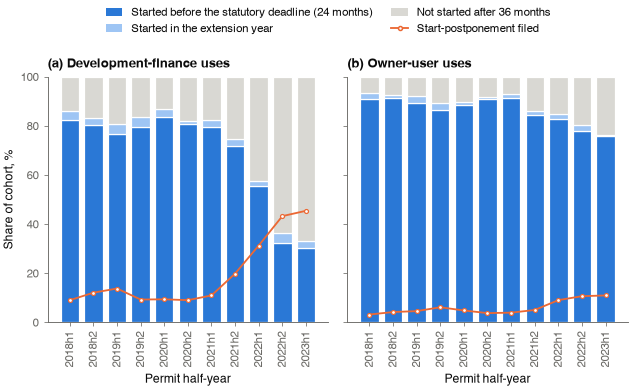

In [35]:
c = p[(p.large == 1) & (p.fin != "mixed") & (p.permit >= "2018-01-01") & ok(p, 36)].copy()
c["start_in_24m"] = c.event & (c["T"] < 24); c["start_24_36m"] = c.event & (c["T"] >= 24) & (c["T"] < 36); c["unstarted_36m"] = ~(c.event & (c["T"] < 36)); c["delay_filed"] = c.delay.notna()
f8a = c.groupby(["fin", "h"])[["start_in_24m", "start_24_36m", "unstarted_36m", "delay_filed"]].mean(); f8a["n"] = c.groupby(["fin", "h"]).size(); f8a = f8a.reset_index()
rows = []
for h_ in sorted(f8a.h.unique()):
    v_ = []
    for fn in ["finance", "owner"]:
        r_ = f8a[(f8a.fin == fn) & (f8a.h == h_)].iloc[0]; v_ += [n_(r_.n)] + [f"{100 * r_[k]:.1f}" for k in ["start_in_24m", "start_24_36m", "unstarted_36m", "delay_filed"]]
    rows.append((h_.replace("H", "h"), v_)); rows += ["gap"] if h_ == "2021H1" else []
write_table("tableS19_outcomes", "lrrrrrrrrrr", [r" & \multicolumn{5}{c}{Development-finance uses} & \multicolumn{5}{c}{Owner-user uses} \\", r"\cmidrule(lr){2-6}\cmidrule(lr){7-11}",
            r"Permit & & Start & Start & Unstarted & Postpone- & & Start & Start & Unstarted & Postpone- \\", r"half-year & $N$ & $<$24m & 24--36m & at 36m & ment filed & $N$ & $<$24m & 24--36m & at 36m & ment filed \\"], rows)

fig, axs = plt.subplots(1, 2, figsize=(6.8, 2.9), sharey=True, gridspec_kw={"wspace": .07})
for ax, (fn, ttl) in zip(axs, [("finance", "(a) Development-finance uses"), ("owner", "(b) Owner-user uses")]):
    z = f8a[f8a.fin == fn].sort_values("h"); x = np.arange(len(z)); w = .78; b1, b2, b3 = 100 * z.start_in_24m.values, 100 * z.start_24_36m.values, 100 * z.unstarted_36m.values
    ax.bar(x, b1, w, color=BLUE, ec="white", lw=.8); ax.bar(x, b2, w, bottom=b1, color="#9ec5f4", ec="white", lw=.8); ax.bar(x, b3, w, bottom=b1 + b2, color="#d9d8d3", ec="white", lw=.8)
    ax.plot(x, 100 * z.delay_filed.values, color=ORANGE, lw=1.2, marker="o", ms=2.6, mfc="white", mew=.8, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels([h.replace("H", "h") for h in z.h], rotation=90); ax.set_title(ttl); ax.set_ylim(0, 100); ax.grid(axis="y", visible=False); ax.set_xlabel("Permit half-year")
axs[0].set_ylabel("Share of cohort, %")
hd_ = [Patch(fc=BLUE, label="Started before the statutory deadline (24 months)"), Patch(fc="#9ec5f4", label="Started in the extension year"), Patch(fc="#d9d8d3", label="Not started after 36 months"),
       Line2D([0], [0], color=ORANGE, lw=1.2, marker="o", ms=2.6, mfc="white", label="Start-postponement filed")]
fig.legend(handles=hd_, loc="upper center", ncol=2, bbox_to_anchor=(.5, 1.13), fontsize=7.5, columnspacing=1.6, handlelength=1.4); savefig(fig, "fig08_outcomes")

**Extension-year starts conditional on reaching the statutory deadline unstarted.** Large permits of the cohorts in Table S19.

In [36]:
cx = c.copy(); cx["unst_M"] = ~(cx.event & (cx["T"] < cx.M)); cx["ext_start"] = cx.event & (cx["T"] >= cx.M) & (cx["T"] < cx.M + 12)
cx["cohort"] = np.where(cx.h <= "2021H1", "2018h1-2021h1", np.where(cx.h >= "2022H2", "2022h2-2023h1", "other"))
ext_cond = cx[cx.unst_M & (cx.cohort != "other")].groupby(["fin", "cohort"]).ext_start.agg(["mean", "size"]); ext_cond["mean"] *= 100; display(ext_cond.round(1))

mean  size
fin     cohort                   
finance 2018h1-2021h1  15.7   810
        2022h2-2023h1   5.0   745
owner   2018h1-2021h1  18.3   284
        2022h2-2023h1   7.0   128

**Table S20 (remaining life at the freeze).** Large permits of development-finance and owner-user uses that were valid and unstarted on 1 October 2022, compared with those valid and unstarted on 1 October 2018 and 2019, by months remaining to the extended deadline on that date. Panel A: start before the extended deadline (every deadline falls within 36 months of the reference date and is observed). Panel B: start within 12 months of the reference date. The difference in differences is the coefficient on development finance × 2022 in an OLS regression of the outcome (×100) with use, district and reference-year effects, and in a Poisson regression of the outcome (0/1) with use and reference-year effects (log points), estimated separately for each group. The placebo compares 2019 with 2018. Clustered by district.

In [37]:
def alive_on(D):
    D = pd.Timestamp(D); q_ = p[(p.large == 1) & p.fin.isin(["finance", "owner"]) & (p.permit < D)].copy()
    q_["ext"] = q_.permit + pd.to_timedelta((q_.M + 12) * MO, unit="D")
    q_ = q_[(q_.ext > D) & ~(q_.start < D)].copy()
    q_["rem"] = (q_.ext - D).dt.days / MO; q_["bin"] = pd.cut(q_.rem, [0, 12, 24, 36], labels=["<12", "12-24", "24-36"])
    q_["y_dl"] = (q_.start.notna() & (q_.start <= q_.ext)).astype(float) * 100                        # started before the extended deadline
    q_["y_1y"] = (q_.start.notna() & (q_.start < D + pd.DateOffset(months=12))).astype(float) * 100    # started within 12 months of the reference date
    q_["F"] = (q_.fin == "finance").astype(int); q_["ref"] = D.year
    return q_[q_["bin"].notna()]
AL = pd.concat([alive_on(f"{y}-10-01") for y in (2018, 2019, 2022)])
def rl_did(x, yv, shock, base):
    x = x[x.ref.isin(base + (shock,))].copy(); x["S"] = (x.ref == shock).astype(int); x["FS"] = x.F * x.S; x["R"] = x.ref.astype(str)
    m = pf.feols(f"{yv} ~ FS | g + district + R", x, vcov={"CRV1": "cl"}).tidy().loc["FS"]
    mp = pf.fepois(f"{yv} ~ FS | g + R", x.assign(**{yv: x[yv] / 100}), vcov={"CRV1": "cl"}, fixef_maxiter=100000).tidy().loc["FS"]
    return m, mp
RL = {}
rows = []
for yv, ttl in [("y_dl", "Panel A. Started before the extended deadline"), ("y_1y", "Panel B. Started within 12 months of the reference date")]:
    rows += [rf"\multicolumn{{11}}{{l}}{{\emph{{{ttl}}}}} \\", "gap"]
    for b in ["24-36", "12-24", "<12"]:
        x = AL[AL["bin"] == b]; sh = x.assign(P=np.where(x.ref == 2022, "22", "1819")).groupby(["F", "P"])[yv].mean()
        nn = x.assign(P=np.where(x.ref == 2022, "22", "1819")).groupby(["F", "P"]).size()
        (a1, a2), (pl1, pl2) = rl_did(x, yv, 2022, (2018, 2019)), rl_did(x, yv, 2019, (2018,)); RL[(yv, b)] = (a1, a2, pl1, pl2)
        c1, c2, c3, c4 = cell(a1["Estimate"], a1["Std. Error"], a1["Pr(>|t|)"], 1), cell(a2["Estimate"], a2["Std. Error"], a2["Pr(>|t|)"], 2), cell(pl1["Estimate"], pl1["Std. Error"], pl1["Pr(>|t|)"], 1), cell(pl2["Estimate"], pl2["Std. Error"], pl2["Pr(>|t|)"], 2)
        rows.append(({"24-36": "24--36 months", "12-24": "12--24 months", "<12": "$<$12 months"}[b], [f"{sh[(1, '1819')]:.1f}", f"{sh[(1, '22')]:.1f}", f"{sh[(0, '1819')]:.1f}", f"{sh[(0, '22')]:.1f}", c1[0], c2[0], c3[0], c4[0],
                                                          f"{nn[(1, '1819')]:,} / {nn[(1, '22')]:,}", f"{nn[(0, '1819')]:,} / {nn[(0, '22')]:,}"]))
        rows.append(("", ["", "", "", "", c1[1], c2[1], c3[1], c4[1], "", ""]))
    if yv == "y_dl": rows.append("mid")
rows += ["mid", r"\multicolumn{11}{l}{\emph{Fixed effects}} \\", (r"\quad Use, reference year", ["", "", "", "", "Yes", "Yes", "Yes", "Yes", "", ""]), (r"\quad District", ["", "", "", "", "Yes", "No", "Yes", "No", "", ""])]
write_table("tableS20_remaining_life", "lcccccccccc", [r"Months remaining to & \multicolumn{2}{c}{Development finance (\%)} & \multicolumn{2}{c}{Owner-user (\%)} & \multicolumn{2}{c}{2022 vs.\ 2018--19} & \multicolumn{2}{c}{Placebo, 2019 vs.\ 2018} & \multicolumn{2}{c}{Permits, 2018--19 / 2022} \\",
            r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}\cmidrule(lr){8-9}\cmidrule(lr){10-11}", r"the extended deadline & 2018--19 & 2022 & 2018--19 & 2022 & DiD (pp) & DiD (log) & DiD (pp) & DiD (log) & Dev.-finance & Owner-user \\",
            r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) & (9) & (10) \\"], rows)
print("share of the 2022 stock with 24-36 months left:", round(100 * (AL[(AL.ref == 2022)]["bin"] == "24-36").mean(), 1))

,(1),(2),(3),(4),(5),(6),(7),(8),(9),(10)
Months remaining to,Development finance (%),Owner-user (%),2022 vs. 2018–19,"Placebo, 2019 vs. 2018","Permits, 2018–19 / 2022",,,,,
the extended deadline,2018–19,2022,2018–19,2022,DiD (pp),DiD (log),DiD (pp),DiD (log),Dev.-finance,Owner-user
,(1),(2),(3),(4),(5),(6),(7),(8),(9),(10)
Panel A. Started before the extended deadline,,,,,,,,,,
24–36 months,65.6,31.9,75.3,60.3,-21.3***,-0.52***,11.9**,0.10,"1,103 / 1,045",498 / 353
,,,,,(4.3),(0.08),(5.7),(0.07),,
12–24 months,30.4,18.2,40.0,31.5,-6.6,-0.30,-12.6,-0.04,335 / 336,105 / 111
,,,,,(9.2),(0.25),(15.8),(0.33),,
<12 months,12.8,4.4,5.5,5.3,-7.7,-1.25,-22.9*,-2.09**,281 / 181,91 / 75
,,,,,(5.1),(0.76),(13.7),(0.93),,


share of the 2022 stock with 24-36 months left: 66.5


**Table 9.** Floor area of large development-finance permits from 2022h2 not started within 12 (24) months, compared with the area-weighted start share of the use in 2018h1–2021h1, and net of the change in the owner-user start share.

In [38]:
gap_rows = []
for N_ in (12, 24):
    qg = p[(p.large == 1) & (p.fin != "mixed") & (p.permit <= END - pd.DateOffset(months=N_))].copy(); qg["y"] = qg[f"y{N_}"] / 100
    calm = qg[(qg.h >= "2018H1") & (qg.h <= "2021H1")]; shock = qg[qg.h >= "2022H2"]
    aw = lambda x: (x.y * x.area).sum() / x.area.sum()
    own_chg = aw(shock[shock.fin == "owner"]) - aw(calm[calm.fin == "owner"])
    for g_ in FIN:
        a, b = calm[calm.g == g_], shock[shock.g == g_]
        if len(b) < 20: continue
        p0 = aw(a); actual = (b.y * b.area).sum()
        gap_rows.append(dict(window=N_, use=g_, permitted=b.area.sum() / 1e6, p0=p0, started=actual / 1e6, gapA=(p0 * b.area.sum() - actual) / 1e6, gapB=((p0 + own_chg) * b.area.sum() - actual) / 1e6, own_chg=own_chg))
gp = pd.DataFrame(gap_rows); gp.to_csv(INT / "supply_gap.csv", index=False)
rows = []
for N_, ttl in [(12, "Panel A. Starts within 12 months, permit cohorts 2022h2--2025h1"), (24, "Panel B. Starts within 24 months, permit cohorts 2022h2--2024h1")]:
    rows += [rf"\multicolumn{{6}}{{l}}{{\emph{{{ttl}}}}} \\", "gap"]; x = gp[gp.window == N_]
    rows += [(r_.use, [f"{r_.permitted:.2f}", f"{r_.p0:.3f}", f"{r_.started:.2f}", f"{r_.gapA:.2f}", f"{r_.gapB:.2f}"]) for r_ in x.sort_values("gapB", ascending=False).itertuples()]
    rows += ["gap", ("All development-finance uses", [f"{x.permitted.sum():.2f}", "", f"{x.started.sum():.2f}", f"{x.gapA.sum():.2f}", f"{x.gapB.sum():.2f}"])] + (["mid"] if N_ == 12 else [])
write_table("table09_supply_gap", "lrrrrr", [r" & Permitted & Normal-times & Started & \multicolumn{2}{c}{Shortfall (million m$^2$)} \\", r"\cmidrule(lr){5-6}",
            r"Property use & (million m$^2$) & start share & (million m$^2$) & vs.\ normal times & net of owner-user change \\"], rows)

,(1),(2),(3),(4),(5)
,Permitted,Normal-times,Started,Shortfall (million m²),
Property use,(million m²),start share,(million m²),vs. normal times,net of owner-user change
"Panel A. Starts within 12 months, permit cohorts 2022h2–2025h1",,,,,
Warehouse,27.13,0.809,3.49,18.45,13.18
Office,18.87,0.741,4.20,9.79,6.13
Apartments,15.94,0.549,1.45,7.30,4.20
Knowledge-industry centre,4.86,0.823,0.70,3.30,2.36
Lodging,4.29,0.656,0.46,2.35,1.52
Officetel,3.81,0.512,0.74,1.22,0.48
Retail,1.69,0.728,0.66,0.57,0.24


**Table 10.** Floor area started by the large development-finance permits valid and unstarted on 1 October 2022 and those issued from October 2022 to September 2024, with and without the contraction and with lives extended by 12 or 24 months. The monthly start hazard at each month since the permit is that of the permits of 18 January 2018 to December 2019 in calendar months before July 2021. From October 2022 it is multiplied by the exponential of the hazard ratios of the contraction (2022q4–2024q3) and of the period after the first rate cut (2024q4–2026q2): in Panel A those of Table S6, column (3), for permits issued before October 2022 and those of Table 5, column (1), for later permits; in Panel B those of Table 5, column (1), for all permits. After April 2026 the ratios stay at their last level (column 2) or the hazard returns to normal (column 3). An extension inserts the added months at the average hazard of months 25–34, before the two deadline months.

In [39]:
# Normal-times monthly start hazard of large development-finance permits by month since permit: permits of 18 January 2018 to December 2019, calendar months before July 2021
Lx = p[(p.large == 1) & (p.fin == "finance")]
rn = panel(Lx[(Lx.permit >= "2018-01-18") & (Lx.permit < "2020-01-01")], 37, cols=("cl", "pm", "T", "event", "permit")); rn = rn[rn.cal < "2021-07"]
H0 = rn.groupby("d").y.mean().reindex(range(37)).values; H_LATE = H0[25:35].mean()
def profile(E): return np.r_[H0[:35], np.full(E, H_LATE), H0[35:37]] if E else H0.copy()   # E months of added life at the hazard of months 25-34, before the deadline months
# Permits at risk: valid and unstarted on 1 October 2022, and issued from October 2022 to September 2024 (every permit issued before October 2022 is under the two-year regime)
D0 = pd.Timestamp("2022-10-01"); mi_ = lambda s: s.dt.year * 12 + s.dt.month - 1
stk = Lx[(Lx.permit < D0) & (Lx.permit + pd.to_timedelta((Lx.M + 12) * MO, unit="D") > D0) & ~(Lx.start < D0)]
new = Lx[(Lx.permit >= D0) & (Lx.permit < "2024-10-01")]
RISK = pd.concat([stk.assign(old=1), new.assign(old=0)]); RISK["c"] = mi_(RISK.permit)
C_D0, C_CUT, C_END = 2022 * 12 + 9, 2024 * 12 + 9, 2026 * 12 + 3                                   # October 2022, October 2024, April 2026
GR = RISK.groupby(["c", "old"]).agg(area=("area", "sum"), n=("area", "size")).reset_index()
def lhr(old, cal, spec, post):
    fr, af = (HR_OLD["freeze"], HR_OLD["after"]) if (spec == "vintage" and old) else (HR_POOLED["freeze"], HR_POOLED["after"])
    v = np.where(cal < C_CUT, fr, af)
    return np.where(cal > C_END, 0.0, v) if post == "normal" else v
def scenario(shock, E, spec="vintage", post="stay"):
    by_end = ever = conv_n = conv_d = 0.0
    for r_ in GR.itertuples():
        prof = profile(E); a0 = max(C_D0 - r_.c, 0); d = np.arange(a0, len(prof)); cal = r_.c + d
        hz = np.clip(prof[d] * (np.exp(lhr(r_.old, cal, spec, post)) if shock else 1.0), 0, 1)
        s = np.r_[1.0, np.cumprod(1 - hz)[:-1]] * hz
        by_end += r_.area * s[cal <= C_END].sum(); ever += r_.area * s.sum()
        if not E and 2022 * 12 + 6 <= r_.c <= 2023 * 12 + 5:                                             # permits of 2022h2 and 2023h1 reaching month 24 unstarted
            s24 = s[d < 24].sum(); conv_n += r_.n * s[(d >= 24) & (d <= 36)].sum(); conv_d += r_.n * (1 - s24)
    return by_end / 1e6, ever / 1e6, (100 * conv_n / conv_d if conv_d else np.nan)
CF = {}
for spec in ("vintage", "pooled"):
    for post in ("stay", "normal"):
        for lab, sh, E in [("none", False, 0), ("actual", True, 0), ("e12", True, 12), ("e24", True, 24)]: CF[(spec, post, lab)] = scenario(sh, E, spec, post)
print("extension-year start rate of 2022h2-2023h1 permits unstarted at month 24, contraction scenario, Panel A (%):", round(CF[("vintage", "stay", "actual")][2], 1))
rows = []
for spec, ttl in [("vintage", r"Panel A. Hazard ratios by permit vintage"), ("pooled", r"Panel B. Hazard ratios of Table~5, column (1), for all permits")]:
    rows += [rf"\multicolumn{{4}}{{l}}{{\emph{{{ttl}}}}} \\", "gap"]
    for lab, name in [("none", "Without the contraction"), ("actual", "With the contraction, statutory life"), ("e12", "With the contraction, life extended by 12 months"), ("e24", "With the contraction, life extended by 24 months")]:
        rows.append((name, [f"{CF[(spec, 'stay', lab)][0]:.1f}", f"{CF[(spec, 'stay', lab)][1]:.1f}", f"{CF[(spec, 'normal', lab)][1]:.1f}"]))
    for lab, name in [("e12", "Share of the shortfall recovered, 12 months (\\%)"), ("e24", "Share of the shortfall recovered, 24 months (\\%)")]:
        v = [100 * (CF[(spec, post, lab)][k] - CF[(spec, post, "actual")][k]) / (CF[(spec, post, "none")][k] - CF[(spec, post, "actual")][k]) for post, k in [("stay", 0), ("stay", 1), ("normal", 1)]]
        rows.append((name, [f"{x:.0f}" for x in v]))
    rows.append("mid" if spec == "vintage" else "gap")
REG_STARTED = RISK[RISK.start.notna() & (RISK.start >= D0) & (RISK.start <= END)].area.sum() / 1e6          # starts recorded in the register, October 2022 to April 2026
rows += [("Started October 2022 to April 2026 in the register", [f"{REG_STARTED:.1f}", "", ""]),
         ("Floor area of permits valid and unstarted on 1 October 2022", [f"{stk.area.sum() / 1e6:.1f}", "", ""]), ("Floor area of permits issued October 2022 to September 2024", [f"{new.area.sum() / 1e6:.1f}", "", ""]),
         ("Permits, valid on 1 October 2022 / issued later", [f"{len(stk):,} / {len(new):,}", "", ""])]
write_table("table10_extension", "lccc", [r" & \multicolumn{3}{c}{Floor area started from October 2022 (million m$^2$)} \\", r"\cmidrule(lr){2-4}",
            r" & By April & \multicolumn{2}{c}{Eventually} \\", r"\cmidrule(lr){3-4}", r" & 2026 & Ratios stay at & Hazards normal \\",
            r" & & 2024q4--2026q2 level & after April 2026 \\", r" & (1) & (2) & (3) \\"], rows)

extension-year start rate of 2022h2-2023h1 permits unstarted at month 24, contraction scenario, Panel A (%): 9.7


,(1),(2),(3)
,Floor area started from October 2022 (million m²),,
,By April,Eventually,
,2026,Ratios stay at,Hazards normal
,,2024q4–2026q2 level,after April 2026
,(1),(2),(3)
Panel A. Hazard ratios by permit vintage,,,
Without the contraction,72.1,72.8,72.8
"With the contraction, statutory life",46.1,47.1,47.8
"With the contraction, life extended by 12 months",47.0,50.0,52.6
"With the contraction, life extended by 24 months",47.2,52.6,58.5


**Figure 9.** Share of large development-finance permits started within 12 months by district, in normal times (a) and during the tightening (b), and floor area permitted from 2022h2 and not started after 12 months (c). Metropolitan cities are shown by autonomous district and provinces by city or county; units with fewer than 10 permits are hatched. Boundaries: V-World (simplified).

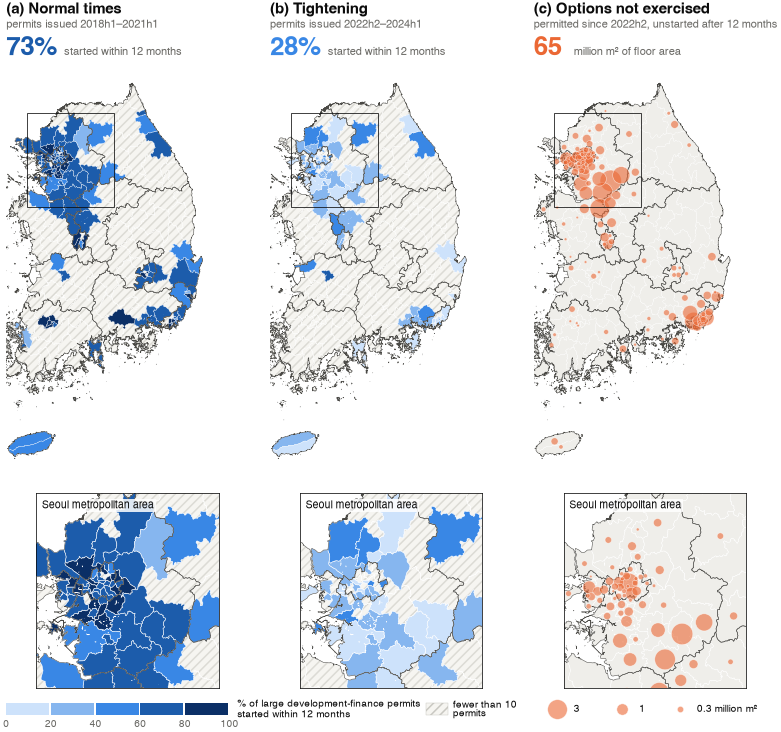

districts with >= 10 permits in both periods: 64; median start share 75.0% -> 24.4%; below 40% in the tightening: 54; SMA share of unstarted area 53%


,unit,name,unstarted_Mm2,n_late
119,41500,이천시,3.57,83.0
120,41550,안성시,3.32,55.0
140,44130,천안시 동남구,3.00,46.0
1,11140,중구,2.62,29.0
63,26440,강서구,2.50,22.0


In [40]:
import geopandas as gpd
METRO = ("11", "26", "27", "28", "29", "30", "31", "36")
def unit(c_): return c_ if c_[:2] in METRO else c_[:4] + "0"
gm = geo_table("geo_sigungu"); gm["unit"] = gm.sig_cd.map(unit)
gm = gm.dissolve(by="unit", as_index=False)[["unit", "geometry"]].to_crs(5179)
sido_g = geo_table("geo_sido").to_crs(5179)
gm = gm[gm.geometry.centroid.x < 1_250_000].copy()                                    # Ulleung and Dokdo are outside the frame
Lm = p[(p.large == 1) & (p.fin == "finance") & ok(p, 12)].copy(); Lm["unit"] = Lm.district.map(unit)
calm = Lm[(Lm.h >= "2018H1") & (Lm.h <= "2021H1")]; shock = Lm[(Lm.h >= "2022H2") & (Lm.h <= "2024H1")]; late = Lm[Lm.h >= "2022H2"]
def agg(x, tag): return x.groupby("unit").agg(**{f"n_{tag}": ("y12", "size"), f"p_{tag}": ("y12", "mean")})
um = gm[["unit"]].merge(agg(calm, "calm"), on="unit", how="left").merge(agg(shock, "shock"), on="unit", how="left")
un_ = late.assign(unst=lambda d: d.area * (d.y12 == 0)).groupby("unit").agg(unstarted_Mm2=("unst", lambda s: s.sum() / 1e6), n_late=("area", "size"))
um = um.merge(un_, on="unit", how="left"); um.to_csv(INT / "map_units.csv", index=False); gm = gm.merge(um, on="unit"); MIN_N = 10
bounds = [0, 20, 40, 60, 80, 100]; ramp = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0b2f66"]
cmap = ListedColormap(ramp); norm = BoundaryNorm(bounds, cmap.N); SMA_BOX = (905_000, 1_870_000, 1_045_000, 2_020_000)
def base_map(ax, gd, col, ncol, lw=.2):
    ok_ = gd[gd[ncol] >= MIN_N]; no = gd[~(gd[ncol] >= MIN_N)]
    no.plot(ax=ax, color="#f6f5f1", edgecolor="#dcdbd5", linewidth=0, hatch="////", zorder=1); no.boundary.plot(ax=ax, color="white", linewidth=lw, zorder=1.5)
    ok_.plot(ax=ax, column=col, cmap=cmap, norm=norm, edgecolor="white", linewidth=lw, zorder=2); sido_g.boundary.plot(ax=ax, color="#4a4945", linewidth=.35, zorder=3)
def frame(ax, box=None, border=False):
    ax.set_aspect("equal")
    if box: ax.set_xlim(box[0], box[2]); ax.set_ylim(box[1], box[3])
    else: ax.set_xlim(872_000, 1_262_000); ax.set_ylim(1_462_000, 2_075_000)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for sp in ax.spines.values(): sp.set_visible(border); sp.set_linewidth(.5); sp.set_edgecolor(INK)
fig = plt.figure(figsize=(7.0, 6.7)); W_ = .315; XP = [0.0, .3425, .685]; K = 55.0
top = [fig.add_axes([x, .335, W_, .575]) for x in XP]; bot = [fig.add_axes([x, .055, W_, .265]) for x in XP]
un_tot = late.assign(v=late.area * (late.y12 == 0)).v.sum() / 1e6
HEAD = [("(a) Normal times", "permits issued 2018h1–2021h1", f"{calm.y12.mean():.0f}%", "started within 12 months", "#1c5cab"),
        ("(b) Tightening", "permits issued 2022h2–2024h1", f"{shock.y12.mean():.0f}%", "started within 12 months", "#3987e5"),
        ("(c) Options not exercised", "permitted since 2022h2, unstarted after 12 months", f"{un_tot:.0f}", "million m² of floor area", ORANGE)]
rp = gm.geometry.representative_point(); cen = pd.DataFrame({"px": rp.x.values, "py": rp.y.values, "unstarted_Mm2": gm.unstarted_Mm2.values})
cen = cen[cen.unstarted_Mm2 > 0.05].sort_values("unstarted_Mm2", ascending=False)
for k, (axT, axB_) in enumerate(zip(top, bot)):
    for ax, box in [(axT, None), (axB_, SMA_BOX)]:
        if k < 2: base_map(ax, gm, ["p_calm", "p_shock"][k], ["n_calm", "n_shock"][k], lw=.2 if box is None else .35)
        else:
            gm.plot(ax=ax, color="#efeeea", edgecolor="white", linewidth=.2 if box is None else .35, zorder=1); sido_g.boundary.plot(ax=ax, color="#4a4945", linewidth=.35, zorder=2)
            ax.scatter(cen.px, cen.py, s=K * cen.unstarted_Mm2, color=ORANGE, alpha=.6, edgecolor="white", linewidth=.4, zorder=4)
        frame(ax, box, border=box is not None)
    axT.add_patch(Rectangle((SMA_BOX[0], SMA_BOX[1]), SMA_BOX[2] - SMA_BOX[0], SMA_BOX[3] - SMA_BOX[1], fill=False, ec=INK, lw=.5, zorder=5))
    t_, sub, big, cap, col = HEAD[k]
    fig.text(XP[k], .985, t_, fontsize=9.5, fontweight="bold", va="top"); fig.text(XP[k], .962, sub, fontsize=7.2, color=MUTED, va="top")
    fig.text(XP[k], .940, big, fontsize=17, fontweight="bold", color=col, va="top"); fig.text(XP[k] + (.075 if k < 2 else .052), .925, cap, fontsize=7.2, color=MUTED, va="top")
    axB_.text(.03, .96, "Seoul metropolitan area", transform=axB_.transAxes, fontsize=6.8, va="top", color=INK, bbox=dict(fc="white", ec="none", pad=1.2, alpha=.85), zorder=9)
lax = fig.add_axes([0.0, .0, 1, .04]); lax.set_axis_off(); lax.set_xlim(0, 1); lax.set_ylim(0, 1)
for i_, c_ in enumerate(ramp): lax.add_patch(Rectangle((i_ * .058, .45), .056, .42, fc=c_, ec="none"))
for i_, b_ in enumerate(bounds): lax.text(i_ * .058, .30, f"{b_}", fontsize=6.5, ha="center", va="top", color=MUTED)
lax.text(.30, .66, "% of large development-finance permits\nstarted within 12 months", fontsize=6.5, va="center", linespacing=1.05)
lax.add_patch(Rectangle((.545, .45), .028, .42, fc="#f6f5f1", ec="#c9c8c2", hatch="////", lw=.3)); lax.text(.58, .66, f"fewer than {MIN_N}\npermits", fontsize=6.5, va="center", linespacing=1.05)
for v_, xx in [(3.0, .715), (1.0, .80), (.3, .875)]:
    lax.scatter([xx], [.66], s=K * v_, color=ORANGE, alpha=.6, edgecolor="white", linewidth=.4, clip_on=False); lax.text(xx + .022, .66, f"{v_:g}", fontsize=6.5, va="center")
lax.text(.92, .66, "million m²", fontsize=6.5, va="center")
savefig(fig, "fig09_map")
both = um[(um.n_calm >= MIN_N) & (um.n_shock >= MIN_N)]; names = geo_table("geo_sigungu")
nm_col = [c_ for c_ in names.columns if "nm" in c_.lower() and "eng" in c_.lower()] or [c_ for c_ in names.columns if "nm" in c_.lower()]
names["unit"] = names.sig_cd.map(unit); names = names.drop_duplicates("unit").set_index("unit")[nm_col[0]]
top_un = um.sort_values("unstarted_Mm2", ascending=False).head(5).assign(name=lambda d: d.unit.map(names))
sma_units = um.unit.str[:2].isin(["11", "28", "41"])
print(f"districts with >= {MIN_N} permits in both periods: {len(both)}; median start share {both.p_calm.median():.1f}% -> {both.p_shock.median():.1f}%; "
      f"below 40% in the tightening: {int((both.p_shock < 40).sum())}; SMA share of unstarted area {100 * um.loc[sma_units, 'unstarted_Mm2'].sum() / um.unstarted_Mm2.sum():.0f}%")
display(top_un[["unit", "name", "unstarted_Mm2", "n_late"]].round(2))

**Table S21.** Completion within 36 months of the start, large projects, by year of construction start.

In [41]:
s = p[(p.large == 1) & p.start.notna() & (p.start.dt.year >= 2015) & (p.start <= END - pd.DateOffset(months=36))].copy()
s["done36"] = s.approval.notna() & ((s.approval - s.start).dt.days <= 36 * MO); s["build_m"] = (s.approval - s.start).dt.days / MO
f8b = s.groupby(["fin", s.start.dt.year.rename("start_year")]).agg(n=("done36", "size"), done36=("done36", "mean"), median_build_m=("build_m", "median"))
a, b = f8b.loc["finance"], f8b.loc["owner"]
rows = [(str(y), [f"{int(a.n[y]):,}", f"{100 * a.done36[y]:.1f}", f"{a.median_build_m[y]:.1f}", f"{int(b.n[y]):,}", f"{100 * b.done36[y]:.1f}", f"{b.median_build_m[y]:.1f}"]) for y in a.index]
write_table("tableS21_completion_year", "lrrrrrr", [r" & \multicolumn{3}{c}{Development-finance uses} & \multicolumn{3}{c}{Owner-user uses} \\", r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}",
            r"Year of & & Completed & Median months & & Completed & Median months \\", r"construction start & $N$ & within 36m (\%) & to completion & $N$ & within 36m (\%) & to completion \\"], rows)

,(1),(2),(3),(4),(5),(6)
,Development-finance uses,Owner-user uses,,,,
Year of,,Completed,Median months,,Completed,Median months
construction start,N,within 36m (%),to completion,N,within 36m (%),to completion
2015,"1,277",89.9,15.8,918,90.0,8.3
2016,"1,403",87.8,16.9,853,91.9,8.9
2017,"1,230",85.5,18.4,813,92.7,9.6
2018,"1,099",82.9,18.4,718,90.9,10.1
2019,887,82.8,19.2,695,92.8,10.4
2020,973,82.0,20.2,723,89.5,10.6
2021,"1,151",79.1,22.1,786,88.9,12.4


## 11. Large versus small warehouses (Tables S11–S13)

**Table S11.** Large (at least 3,300 m²) versus small (below 1,000 m²) warehouse permits, starts within 12 months, adding fixed effects and controls from left to right.

In [42]:
def prep_ws(q, n=12):
    d = did_data(q, ycol=f"y{n}", n=n)
    for k, cond in [("pre", d.h < "2021H1"), ("hike", d.h.isin(["2021H2", "2022H1"])), ("post", d.h >= "2022H2")]: d["P_" + k] = cond.astype(int)
    return d
SPEC_WS = [("pre + hike + post + L + P_pre + P_hike + P_post", "", "1"), ("pre + hike + post", "L + pm_s", "pm_s"), ("pre + hike + post", "L + pm_s + district", "pm_s + district"),
           ("pre + hike + post", "L + pm_s + district + zone", "pm_s + district + zone"), ("pre + hike + post + ln_site + site_miss", "L + pm_s + district + zone", "pm_s + district + zone"),
           ("pre + hike + post", "L + sgg_h", "sgg_h"), ("pre + hike + post + ln_site + site_miss", "L + sgg_h + zone", "sgg_h + zone")]
d = prep_ws(W); ms, info = [], []
for j, (rhs, fe, fe_es) in enumerate(SPEC_WS):
    m = pf.feols(f"y ~ {rhs}" + (f" | {fe}" if fe else ""), d, vcov={"CRV1": "cl"}); ms.append(m)
    pt, _, _ = pretrend(d, ("L + " + fe_es) if fe_es != "1" else "1", treat="L", extra=" + ln_site + site_miss" if "ln_site" in rhs else "")
    info.append(dict(ci=ci(m, "post"), wild=wild_p(m, "post", 20260919) if j < 5 else "n.a.", pt=f"{pt:.3f}"))
base_ = (d.h >= "2018H1") & (d.h <= "2021H1")
rows = [r"\multicolumn{8}{l}{\emph{Dependent variable is construction started within 12 months of permit ($\times$100)}} \\", "gap"]
rows += coef_rows(ms, [("pre", r"Large $\times$ cohorts 2018h1--2020h2"), ("hike", r"Large $\times$ cohorts 2021h2--2022h1"), ("post", r"Large $\times$ cohorts 2022h2 onward"), None,
                       ("L", r"Large ($\geq$3,300 m$^2$)"), ("P_pre", "Cohorts 2018h1--2020h2"), ("P_hike", "Cohorts 2021h2--2022h1"), ("P_post", "Cohorts 2022h2 onward"), None,
                       ("ln_site", "Log site area"), ("site_miss", "Site area missing"), None])
rows += [(r"95\% CI, Large $\times$ 2022h2 onward", [i["ci"] for i in info]), (r"Wild cluster bootstrap $p$, same coefficient", [i["wild"] for i in info]),
         (r"Pre-period joint test ($p$-value)", [i["pt"] for i in info]), (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Adjusted $R^2$", [f"{m._adj_r2:.3f}" for m in ms]),
         (r"Within $R^2$", [f"{m._r2_within:.3f}" if np.isfinite(m._r2_within) else "" for m in ms]), ("Observations", [n_(m._N) for m in ms]),
         ("Mean of dep. var., large, cohorts to 2021h1", [f"{d.loc[base_ & (d.L == 1), 'y'].mean():.2f}"] * 7), ("Mean of dep. var., small, cohorts to 2021h1", [f"{d.loc[base_ & (d.L == 0), 'y'].mean():.2f}"] * 7),
         ("Large / small permits", [f"{n_((d.L == 1).sum())} / {n_((d.L == 0).sum())}"] * 7), ("Large permits, cohorts 2022h2 onward", [n_(d.post.sum())] * 7), ("Clusters (districts)", [n_(d.cl.nunique())] * 7),
         "mid", r"\multicolumn{8}{l}{\emph{Fixed effects and controls}} \\", (r"\quad Size group", yn([0, 1, 1, 1, 1, 1, 1])), (r"\quad Permit month", yn([0, 1, 1, 1, 1, 0, 0])),
         (r"\quad District", yn([0, 0, 1, 1, 1, 0, 0])), (r"\quad Zoning category", yn([0, 0, 0, 1, 1, 0, 1])), (r"\quad District $\times$ half-year", yn([0, 0, 0, 0, 0, 1, 1])),
         (r"\quad Site-area controls", yn([0, 0, 0, 0, 1, 0, 1]))]
write_table("tableS11_main_did", "lccccccc", [r" & \multicolumn{7}{c}{OLS, warehouse permits, large ($\geq$3,300 m$^2$) versus small ($<$1,000 m$^2$), permit cohorts from 2018h1, omitted cohort 2021h1} \\",
            r"\cmidrule(lr){2-8}", r" & \multicolumn{5}{c}{Adding fixed effects and controls} & \multicolumn{2}{c}{Local shocks absorbed} \\", r"\cmidrule(lr){2-6}\cmidrule(lr){7-8}", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) \\"], rows)

,(1),(2),(3),(4),(5),(6),(7)
,"OLS, warehouse permits, large (≥3,300 m²) versus small (<1,000 m²), permit cohorts from 2018h1, omitted cohort 2021h1",,,,,,
,Adding fixed effects and controls,Local shocks absorbed,,,,,
,(1),(2),(3),(4),(5),(6),(7)
Dependent variable is construction started within 12 months of permit (×100),,,,,,,
Large × cohorts 2018h1–2020h2,4.84,4.64,2.67,2.87,2.75,4.15,4.05
,(6.20),(6.25),(6.39),(6.40),(6.31),(5.71),(5.70)
Large × cohorts 2021h2–2022h1,-14.92**,-14.81**,-16.97***,-16.73***,-15.50**,-15.04***,-13.76**
,(6.35),(6.38),(6.24),(6.25),(6.08),(5.62),(5.59)
Large × cohorts 2022h2 onward,-37.79***,-37.52***,-41.68***,-41.37***,-40.27***,-37.27***,-35.73***
,(7.51),(7.44),(6.72),(6.75),(6.75),(6.44),(6.47)


**Table S12.** Heterogeneity by region and size, other property uses as placebo or comparison, and the triple difference of warehouses versus factories.

In [43]:
def did_any(q, lo=1000, hi=3300, hi2=None):
    d = did_data(q, lo=lo, hi=hi)
    if hi2: d = d[(d.area < lo) | (d.area < hi2)]
    return d
cols = [did_any(W[W.sma]), did_any(W[~W.sma]), did_any(W, hi2=10000), did_any(W, hi=10000), did_any(Fa), did_any(p[p.g == "Office"]), did_any(p[p.g == "Apartments"])]
ms, info = [], []
for d in cols:
    m = pf.feols("y ~ pre + hike + post | L + pm_s + district", d, vcov={"CRV1": "cl"}); ms.append(m); b0_ = d.h <= "2021H1"
    info.append(dict(ci=ci(m, "post"), wild=wild_p(m, "post", 20260919), pt=f"{pretrend(d, 'L + pm_s + district', treat='L')[0]:.3f}", mt=f"{d.loc[b0_ & (d.L == 1), 'y'].mean():.2f}",
                     mc=f"{d.loc[b0_ & (d.L == 0), 'y'].mean():.2f}", nl=n_((d.L == 1).sum()), ns=n_((d.L == 0).sum()), np_=n_(d.post.sum()), G=n_(d.cl.nunique())))
t3 = did_data(pd.concat([W, Fa])); t3["wh"] = (t3.g == "Warehouse").astype(int)
for k in ["pre", "hike", "post"]: t3[k] = t3[k] * t3.wh
t3["sec_pm"] = t3.g + t3.pm_s; t3["L_pm"] = t3.L.astype(str) + t3.pm_s; t3["sec_L"] = t3.g + t3.L.astype(str); t3["sec_sgg"] = t3.g + t3.district
m = pf.feols("y ~ pre + hike + post | sec_L + sec_pm + L_pm + sec_sgg", t3, vcov={"CRV1": "cl"}); ms.append(m); tw = t3[t3.wh == 1]
info.append(dict(ci=ci(m, "post"), wild="n.a.", pt="", mt=f"{tw.loc[(tw.h <= '2021H1') & (tw.L == 1), 'y'].mean():.2f}", mc=f"{tw.loc[(tw.h <= '2021H1') & (tw.L == 0), 'y'].mean():.2f}",
                 nl=n_((t3.L == 1).sum()), ns=n_((t3.L == 0).sum()), np_=n_(t3.post.sum()), G=n_(t3.cl.nunique())))
rows = coef_rows(ms, [("pre", r"Treated $\times$ cohorts 2018h1--2020h2"), ("hike", r"Treated $\times$ cohorts 2021h2--2022h1"), ("post", r"Treated $\times$ cohorts 2022h2 onward")])
rows += ["gap", (r"95\% CI, Treated $\times$ 2022h2 onward", [i["ci"] for i in info]), (r"Wild cluster bootstrap $p$, same coefficient", [i["wild"] for i in info]),
         (r"Pre-period joint test ($p$-value)", [i["pt"] for i in info]), "mid", ("Treated group", ["Large"] * 7 + [r"Wareh.$\times$Large"]), r"\multicolumn{9}{l}{\emph{Fixed effects}} \\",
         (r"\quad Size group, permit month, district", yn([1] * 7 + [0])), (r"\quad All two-way sector, size, month, sector $\times$ district", yn([0] * 7 + [1])), "gap",
         ("Mean of dep. var., large, cohorts to 2021h1", [i["mt"] for i in info]), ("Mean of dep. var., small, cohorts to 2021h1", [i["mc"] for i in info]),
         (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Adjusted $R^2$", [f"{m._adj_r2:.3f}" for m in ms]), (r"Within $R^2$", [f"{m._r2_within:.3f}" for m in ms]), ("Observations", [n_(m._N) for m in ms]),
         ("Large permits", [i["nl"] for i in info]), ("Small permits", [i["ns"] for i in info]), ("Treated permits, cohorts 2022h2 onward", [i["np_"] for i in info]), ("Clusters (districts)", [i["G"] for i in info])]
write_table("tableS12_main_het", "lcccccccc", [r" & \multicolumn{8}{c}{Dependent variable is construction started within 12 months of permit ($\times$100), OLS} \\", r"\cmidrule(lr){2-9}",
            r" & \multicolumn{2}{c}{Warehouses, region} & \multicolumn{2}{c}{Warehouses, size} & \multicolumn{3}{c}{Other property uses} & Wareh.\ vs. \\", r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-8}",
            r" & Seoul metro & Other regions & 3,300--10,000 m$^2$ & $\geq$10,000 m$^2$ & Factories & Offices & Apartments & factories \\", r" & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\"], rows)

,(1),(2),(3),(4),(5),(6),(7),(8)
,"Dependent variable is construction started within 12 months of permit (×100), OLS",,,,,,,
,"Warehouses, region","Warehouses, size",Other property uses,Wareh. vs.,,,,
,Seoul metro,Other regions,"3,300–10,000 m²","≥10,000 m²",Factories,Offices,Apartments,factories
,(1),(2),(3),(4),(5),(6),(7),(8)
Treated × cohorts 2018h1–2020h2,4.57,3.45,-16.26***,12.62,-2.31,-0.74,5.52,4.68
,(7.29),(10.98),(6.22),(7.97),(3.21),(6.32),(4.27),(7.34)
Treated × cohorts 2021h2–2022h1,-16.04**,-17.17,-24.85***,-11.41,-3.71,-8.36,-14.87***,-14.27**
,(6.28),(12.03),(7.62),(8.10),(3.61),(7.56),(5.23),(6.87)
Treated × cohorts 2022h2 onward,-48.54***,-24.51**,-26.17***,-45.86***,2.53,-23.36***,-20.90***,-43.11***
,(7.81),(11.27),(5.64),(8.27),(4.03),(7.95),(4.40),(8.11)


**Table S13.** Effects by project size: size bins (omitted: below 1,000 m²) and log floor area, each interacted with the cohort periods, with district × half-year effects.

In [44]:
def size_models(q):
    d = q[(q.permit >= "2018-01-01") & ok(q, 12)].copy(); d["y"] = d.y12
    d["s4"] = pd.cut(d.area, [0, 1000, 3300, 10000, np.inf], labels=["a", "b", "c", "d"], right=False).astype(str)
    for k, cond in [("pre", d.h < "2021H1"), ("hike", d.h.isin(["2021H2", "2022H1"])), ("post", d.h >= "2022H2")]:
        for z in "bcd": d[f"{k}_{z}"] = ((d.s4 == z) & cond).astype(int)
        d["ln_" + k] = d.lnarea * cond
    ks = [f"{k}_{z}" for z in "bcd" for k in ("pre", "hike", "post")]
    return (pf.feols("y ~ " + "+".join(ks) + " | s4 + sgg_h", d, vcov={"CRV1": "cl"}), pf.feols("y ~ lnarea + ln_pre + ln_hike + ln_post | sgg_h", d, vcov={"CRV1": "cl"}), d.cl.nunique())
wb, wl, Gw = size_models(W); fb, fl, Gf = size_models(Fa); ms = [wb, fb, wl, fl]
PL = [("pre", "cohorts 2018h1--2020h2"), ("hike", "cohorts 2021h2--2022h1"), ("post", "cohorts 2022h2 onward")]
terms = []
for z, lab in [("b", "1,000--3,300 m$^2$"), ("c", "3,300--10,000 m$^2$"), ("d", r"$\geq$10,000 m$^2$")]:
    terms += [(f"{k}_{z}", rf"{lab} $\times$ {pl}") for k, pl in PL] + [None]
terms += [("lnarea", "Log floor area")] + [("ln_" + k, rf"Log floor area $\times$ {pl}") for k, pl in PL]
rows = coef_rows(ms, terms) + ["mid", r"\multicolumn{5}{l}{\emph{Fixed effects}} \\", (r"\quad Size bin", yn([1, 1, 0, 0])), (r"\quad District $\times$ half-year", yn([1, 1, 1, 1])), "gap",
                               (r"$R^2$", [f"{m._r2:.3f}" for m in ms]), (r"Within $R^2$", [f"{m._r2_within:.3f}" for m in ms]), ("Observations", [n_(m._N) for m in ms]), ("Clusters (districts)", [n_(G) for G in (Gw, Gf, Gw, Gf)])]
write_table("tableS13_size", "lcccc", [r" & \multicolumn{4}{c}{Dependent variable is started within 12 months of permit ($\times$100), OLS} \\", r"\cmidrule(lr){2-5}",
            r" & \multicolumn{2}{c}{Size bins (omitted, $<$1,000 m$^2$)} & \multicolumn{2}{c}{Continuous size} \\", r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}", r" & Warehouses & Factories & Warehouses & Factories \\", r" & (1) & (2) & (3) & (4) \\"], rows)

,(1),(2),(3),(4)
,"Dependent variable is started within 12 months of permit (×100), OLS",,,
,"Size bins (omitted, <1,000 m²)",Continuous size,,
,Warehouses,Factories,Warehouses,Factories
,(1),(2),(3),(4)
"1,000–3,300 m² × cohorts 2018h1–2020h2",1.28,-1.03,,
,(3.27),(3.49),,
"1,000–3,300 m² × cohorts 2021h2–2022h1",-5.35,-3.17,,
,(4.54),(3.72),,
"1,000–3,300 m² × cohorts 2022h2 onward",-1.39,4.28,,
,(4.20),(3.27),,


## Files written

In [45]:
print("\n".join(sorted(str(f.relative_to(ROOT)) for f in OUT.rglob("*") if f.is_file() and f.suffix in (".tex", ".pdf"))))

output/figures/fig01_schematic.pdf
output/figures/fig02_timeline.pdf
output/figures/fig03_model.pdf
output/figures/fig04_hazard_groups.pdf
output/figures/fig05_reforms_halfyear.pdf
output/figures/fig06_freeze_quarterly.pdf
output/figures/fig07_event_study_factory.pdf
output/figures/fig08_outcomes.pdf
output/figures/fig09_map.pdf
output/figures/figC1_price_indices.pdf
output/figures/figS01_freeze_monthly.pdf
output/figures/figS02_uses_cohorts.pdf
output/tables/table01_summary.tex
output/tables/table02_reforms.tex
output/tables/table03_completion36.tex
output/tables/table04_levels.tex
output/tables/table05_freeze.tex
output/tables/table06_main_factory.tex
output/tables/table07_uses_change.tex
output/tables/table08_pooled.tex
output/tables/table09_supply_gap.tex
output/tables/table10_extension.tex
output/tables/tableC1_hedonic.tex
output/tables/tableS01_timing_repermit.tex
output/tables/tableS02_uses.tex
output/tables/tableS03_completion48.tex
output/tables/tableS04_bunch_completed.tex
ou